# F20/F21 AA 2025-2026 CW2 — Master Notebook
## The Google Maps Review Challenge

**Group:** Dubai_UG_Group_04

| Name | Tasks | Student ID |
|---|---|---|
| Vishakha Heralal | Task 1 & 2 | H00421235 |
| Temisola Olajide | Task 5 | H00387172 |
| Saad Noman | Task 3 & 6 | H00399124 |
| Muhammad Hassan | Task 4 | H00390896 |

**Contents:**
1. Task 1 — Exploratory Data Analysis
2. Task 2 — Preprocessing
3. Task 3 — Vector Space Models
4. Task 4 — Model Training
5. Task 5 — Sequence Models (LSTM/RNN)
6. Task 5b — DistilBERT (Transformer)
7. Task 6 — Topic Modelling


---
# Task 1 — Exploratory Data Analysis
---


# Task 1: Data Exploration and Visualization 
The notebook begins by importing pandas, matplotlib, seaborn, and numpy which are the standard Python data science toolkit. Training and test CSV files are loaded separately,the test set must remain unseen during any preprocessing decisions to avoid data leakage.




In [ ]:
#Importing important tools for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#loading training and testing dataset
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

print(df_train.head()) #to check the first 5 rows of the training dataset
print("\n")
print(df_train.info()) #to check the data types and non-null values in the training dataset
print("\n")
print(df_train.describe()) #to get the statistical summary of the training dataset

                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


<class 'pandas.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    288000 non-null  str  
 1   rating  288000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 4.4 MB
None


              rating
count  288000.000000
mean        2.612115
std         1.472543
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000


# Data quality checks
 we check for unique rating values (confirming the scale runs 1–5 with no gaps or anomalies), null values, and duplicates. Finding zero duplicates at this stage is noted, though a more thorough deduplication happens later once filtering has been applied.

In [2]:
#checking for unique values in the 'rating' column
print("Unique values in 'rating' column:", np.sort(df_train['rating'].unique()))
#checking for missing values in the training dataset
print("Missing values in training dataset:\n", df_train.isnull().sum())
#checking the dimensions of the training dataset
print("dataset dimensions:", df_train.shape)

Unique values in 'rating' column: [1 2 3 4 5]
Missing values in training dataset:
 text      0
rating    0
dtype: int64
dataset dimensions: (288000, 2)


In [3]:
print("null values:")#to check for null values in the training dataset
print("duplicated values:", df_train.duplicated().sum())#to check for duplicated values in the training dataset

null values:
duplicated values: 0


# Rating distribution analysis

Statistical measures of the rating column (mean, median, mode, skewness) are computed together. The key insight here is that the mode is 1 despite a mean of 2.61 which signals a heavily left-skewed distribution where one-star reviews dominate. The skewness score of ~0.16 is actually low because of the competing mass of 4-star reviews pulling the distribution in both directions. The pie chart visualisation makes this bimodal shape immediately apparent.



Distribution of rating:
mean: 2.61
median: 3.00
mode: 1
std: 1.47
min: 1
max: 5
skewness: 0.15995527920064573


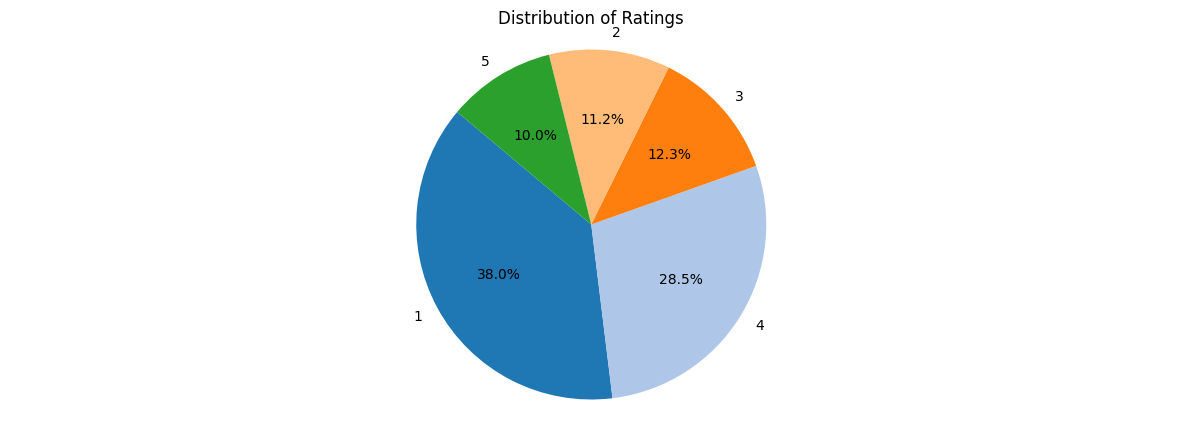

In [4]:
#rating distribution
rating_col = ['rating'] #list of columns to analyze for rating distribution
for col in rating_col: #iterating through the list of columns to analyze
    if col in df_train.columns: #checking if the column exists in the training dataset
        print(f"\nDistribution of {col}:") #to print the distribution of the column
        print(f"mean: {df_train[col].mean():.2f}") #to print the mean of the column rounded to 2 decimal places
        print(f"median: {df_train[col].median():.2f}") #to print the median of the column rounded to 2 decimal places
        print(f"mode: {df_train[col].mode()[0]}") #to print the mode of the column (the most frequent value)
        print(f"std: {df_train[col].std():.2f}") #to print the standard deviation of the column rounded to 2 decimal places
        print(f"min: {df_train[col].min()}") #to print the minimum value of the column
        print(f"max: {df_train[col].max()}") #to print the maximum value of the column
        print(f"skewness: {df_train[col].skew()}") #to print the skewness of the column (a measure of the asymmetry of the distribution)
    
#rating distribution plot
rating_counts = df_train['rating'].value_counts() #to count the occurrences of each unique value in the 'rating' column
plt.figure(figsize=(15, 5)) #to set the figure size for the plot
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Ratings')
plt.show()

# Text length analysis
A new text_length column is derived using str.len() (character count). The resulting statistics reveal a highly right-skewed distribution: the median is 173 characters, but the mean is 315, and the maximum is over 8,000 characters. This means most reviews are short but a long tail of verbose reviews pulls the average up. The histogram and box plot visualise this skew directly. The decision to flag very short comments (<20 chars: 9,692 entries) and very long ones (>500 chars: 52,025 entries) informs the upcoming cleaning step.

In [5]:
print("TEXT LENGTH STATISTICS FOR DF:")
df_train['text_length'] = df_train['text'].str.len() #to create a new column 'text_length' that contains the length of the text in each row of the 'text' column
print(df_train['text_length'].describe())#to get the statistical summary of the 'text_length' column

TEXT LENGTH STATISTICS FOR DF:
count    288000.000000
mean        315.545288
std         427.792476
min          10.000000
25%          70.000000
50%         173.000000
75%         385.000000
max        8049.000000
Name: text_length, dtype: float64


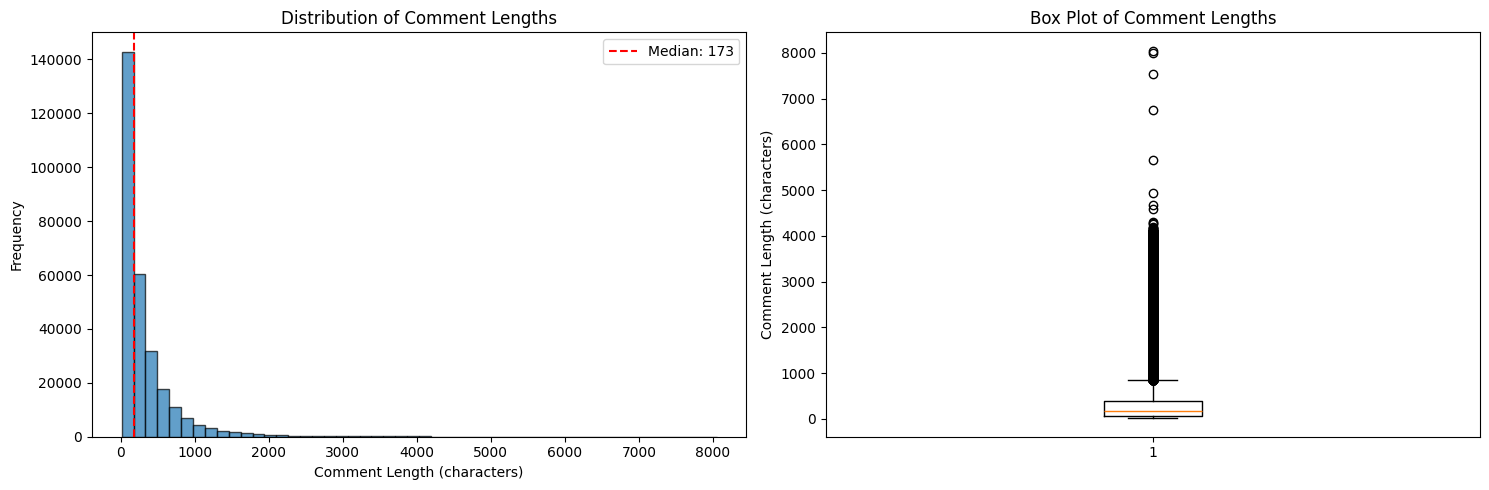

In [6]:
#visualization of the distribution of comment lengths using a histogram and a box plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Histogram
axes[0].hist(df_train['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Comment Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Comment Lengths')
axes[0].axvline(df_train['text_length'].median(), color='red', linestyle='--', label=f'Median: {df_train["text_length"].median():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_train['text_length'], vert=True)
axes[1].set_ylabel('Comment Length (characters)')
axes[1].set_title('Box Plot of Comment Lengths')

plt.tight_layout()
plt.show()

In [7]:
# Insights from plots
print("INSIGHTS:")
print(f"   - Median length of coments: {df_train['text_length'].median():.0f} characters")#to print the median length of comments rounded to 0 decimal places
print(f"   - Very short comments (<20 chars): {(df_train['text_length'] < 20).sum():,}") #to print the number of comments that are very short (less than 20 characters) with comma as a thousand separator
print(f"   - Very long comments (>500 chars): {(df_train['text_length'] > 500).sum():,}") #to print the number of comments that are very long (greater than 500 characters) with comma as a thousand separator

INSIGHTS:
   - Median length of coments: 173 characters
   - Very short comments (<20 chars): 9,692
   - Very long comments (>500 chars): 52,025


In [8]:
df_clean = df_train.copy() # Create a copy of the original DataFrame to perform cleaning operations on, preserving the original data for reference and comparisons. 
initial_count = len(df_clean) # Save initial count for comparisons

print("Starting data cleaning") 
print(f"Initial dataset size: {initial_count:,} comments") #to print the initial size of the dataset with comma as a thousand separator

Starting data cleaning
Initial dataset size: 288,000 comments


In [9]:
min_length = 20 # define minumum length
df_clean = df_clean[df_train['text_length'] >= min_length] # set the dataset for that only entried greater than 20 are saved 
print(f"\n Removed {initial_count - len(df_clean):,} comments shorter than {min_length} characters") # Compare intial and updated df's
print(f" Remaining: {len(df_clean):,} comments")


 Removed 9,692 comments shorter than 20 characters
 Remaining: 278,308 comments


In [10]:
before_dedup = len(df_clean) # save current number of entires for comparison purposes
df_clean = df_clean.drop_duplicates(subset='text', keep='first') # Remove duplicate comments based on the 'text' column, keeping only the first occurrence of each unique comment. This helps to reduce redundancy in the dataset and ensures that each comment is unique for analysis.
print(f"\n Removed {before_dedup - len(df_clean):,} duplicate comments")
print(f" Remaining: {len(df_clean):,} comments")


 Removed 0 duplicate comments
 Remaining: 278,308 comments


In [11]:
import langid # Importing the langid library for language detection, which will be used to filter out non-English comments from the dataset.
def is_english(text): # Define a function to check if the text is in English using langid's classify method, which returns the detected language and its confidence score. 
    try:
        lang, _ = langid.classify(str(text))#Convert the input text to a string to ensure compatibility with langid, 
        return lang == 'en' #and classify it to get the detected language code (e.g., 'en' for English). The function returns True if the detected language is English, and False otherwise. 
    except:
        return False  # Drop rows where detection fails

# Apply the filter
train_df = df_clean[df_clean['text'].apply(is_english)].reset_index(drop=True)
# Check how many rows were removed
print(f"Training set: {len(train_df)} rows remaining")
# Save the cleaned datasets
train_df.to_csv('train_english.csv', index=False)


Training set: 271897 rows remaining


In [12]:
test_df = pd.read_csv('data/test.csv')# Load the test dataset from the specified CSV file into a DataFrame called test_df.
test_df = test_df[test_df['text'].apply(is_english)].reset_index(drop=True)# Apply the same English language filter to the test dataset, keeping only rows where the 'text' column is detected as English. The index is reset after filtering to maintain a clean sequential index.
print(f"Test set: {len(test_df)} rows remaining")
test_df.to_csv('test_english.csv', index=False)# Save the cleaned test dataset to a new CSV file named 'test_english.csv', without including the index in the output file.

Test set: 69907 rows remaining


In [13]:
# Further cleaning: Removing entries that do not contain any alphabetic characters (e.g., only numbers or symbols)
import re
train_df = pd.read_csv('data/train_english.csv') # Load the cleaned training dataset from the specified CSV file into a DataFrame called train_df.
test_df = pd.read_csv('data/test_english.csv') # Load the cleaned test dataset from the specified CSV file into a DataFrame called test_df.

train_df = train_df.dropna(subset=['text']).reset_index(drop=True) # Remove rows from the training dataset where the 'text' column contains null values, and reset the index of the DataFrame after dropping these rows to maintain a clean sequential index.
test_df = test_df.dropna(subset=['text']).reset_index(drop=True) # Remove rows from the test dataset where the 'text' column contains null values, and reset the index of the DataFrame after dropping these rows to maintain a clean sequential index.

# Remove rows where 'text' is empty or contains only whitespace
train_df = train_df[train_df['text'].str.strip() != ''] 
test_df = test_df[test_df['text'].str.strip() != '']

# Remove rows where 'text' does not contain any alphabetic characters using a regular expression to check for the presence of letters (both uppercase and lowercase). This helps to ensure that the dataset contains meaningful text data for analysis and modeling.
train_df = train_df[train_df['text'].apply(lambda x: bool(re.search(r'[a-zA-Z]', str(x))))]
test_df = test_df[test_df['text'].apply(lambda x: bool(re.search(r'[a-zA-Z]', str(x))))]

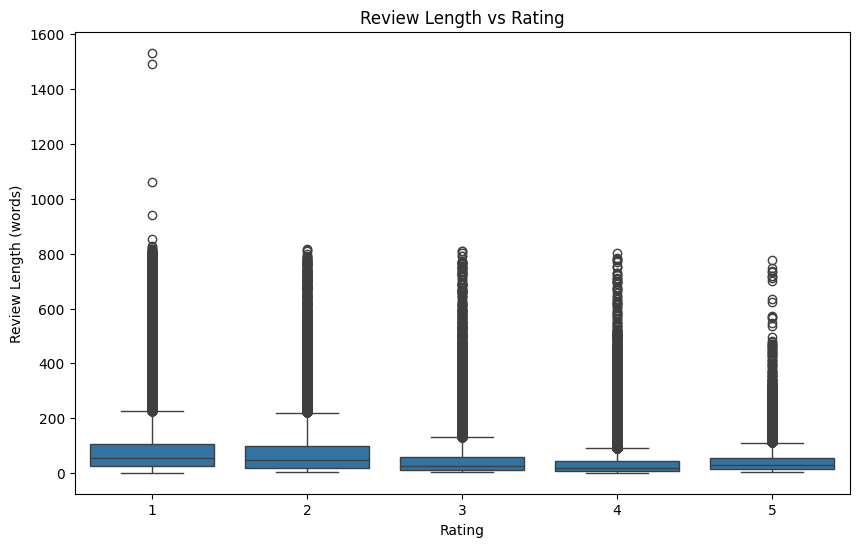

In [14]:
# After cleaning, we can visualize the relationship between review length and rating to see if there are any patterns or trends. This can help us understand if longer reviews tend to have higher or lower ratings, or if there is no clear relationship between the two variables.
import matplotlib.pyplot as plt
import seaborn as sns

# Add review length column
train_df['review_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='review_length', data=train_df)
plt.title('Review Length vs Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length (words)')
plt.show()

## Data Cleaning

### Minimum Length Filter
Reviews shorter than 20 characters are removed. This is well-justified as a  10-character string like *"ok i guess"* provides essentially no signal for sentiment classification and may be noise, emoji-only content, or truncated data.

### Duplicate Removal
`drop_duplicates(subset='text', keep='first')` removes exact textual duplicates. Zero were found, but this step is nonetheless important as a safeguard — duplicates could cause models to overfit on repeated phrases.

### Language Filtering with `langid`
This is one of the most important cleaning steps. The dataset is derived from English-language review platforms, but non-English reviews do appear (likely from multilingual users). The `langid.classify()` function assigns a language code to each review; only entries classified as `'en'` are kept. This removed about 6,300 reviews from the training set (278,308 → 271,897), roughly 2.2%. The same filter is applied identically to the test set to ensure consistency — a critical detail.

### Alphabetic Content Check
A regex filter `re.search(r'[a-zA-Z]', ...)` removes entries containing no letters — for example, pure numeric strings or symbol-only text. These would be uninformative for any NLP model and could introduce noise.

### Overall Cleaning Summary

| Metric | Value |
|---|---|
| Original dataset size | 288,000 reviews |
| Reviews removed | 16,103 (5.6%) |
| Reviews retained | 271,897 (94.4%) |

the goal is to remove clear noise without discarding ambiguous but potentially valid data.

In [15]:
#Get top words for each rating category
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Define a set of stop words to exclude from the analysis, which includes common English words that may not carry significant meaning 
stop_words = set(stopwords.words('english'))
# We can also add some custom stop words that are frequently used in reviews but may not provide useful insights.
custom_stopwords = stop_words.union({'get', 'one', 'go', 'like', 'got', 'even', 'back', 'would', 'could', 'also'})

def get_top_words(df, rating, n=20): # Define a function to get the top n most common words for a given rating category. 
    texts = df[df['rating'] == rating]['text'].str.cat(sep=' ')# Concatenate all the text entries for the specified rating category into a single string, separating them with a space. 
    words = [w.lower() for w in texts.split() if w.lower() not in custom_stopwords and w.isalpha()]# Split the concatenated text into individual words, convert them to lowercase, and filter out any words that are in the custom stop words set or that are not purely alphabetic 
    return Counter(words).most_common(n)

for r in sorted(train_df['rating'].unique()):# Iterate through each unique rating in the training dataset, sorted in ascending order, to analyze the top words associated with each rating category.
    print(f"\nRating {r}: {get_top_words(train_df, r)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Rating 1: [('never', 27584), ('told', 26754), ('time', 22777), ('said', 21687), ('called', 19146), ('place', 18545), ('call', 16721), ('service', 16558), ('people', 14811), ('went', 14447), ('customer', 13995), ('asked', 12553), ('going', 12368), ('give', 12039), ('company', 12026), ('still', 12004), ('take', 11979), ('know', 11945), ('work', 11506), ('another', 11285)]

Rating 2: [('time', 6647), ('told', 5498), ('never', 4849), ('place', 4653), ('good', 4515), ('said', 4448), ('service', 4439), ('went', 3757), ('called', 3685), ('people', 3666), ('staff', 3645), ('going', 3372), ('call', 3351), ('really', 3188), ('first', 3133), ('still', 3109), ('work', 3098), ('two', 3022), ('asked', 2973), ('know', 2964)]

Rating 3: [('good', 5857), ('place', 4326), ('time', 4262), ('nice', 3734), ('great', 3487), ('service', 3452), ('staff', 3187), ('really', 2810), ('people', 2589), ('food', 2513), ('told', 2262), ('work', 2235), ('never', 2141), ('little', 2087), ('need', 2070), ('went', 2059)

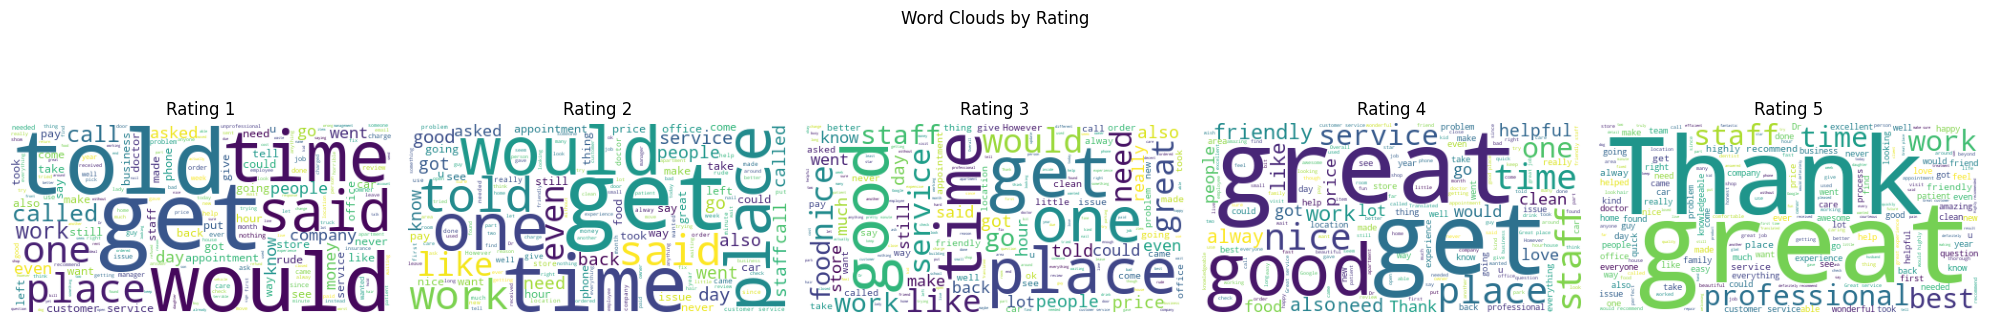

In [16]:
#plot word clouds for each rating category

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, rating in enumerate(sorted(train_df['rating'].unique())):
    text = train_df[train_df['rating'] == rating]['text'].str.cat(sep=' ')
    wc = WordCloud(stopwords=stop_words, background_color='white').generate(text)
    axes[i].imshow(wc)
    axes[i].set_title(f'Rating {rating}')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Rating')
plt.tight_layout()
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


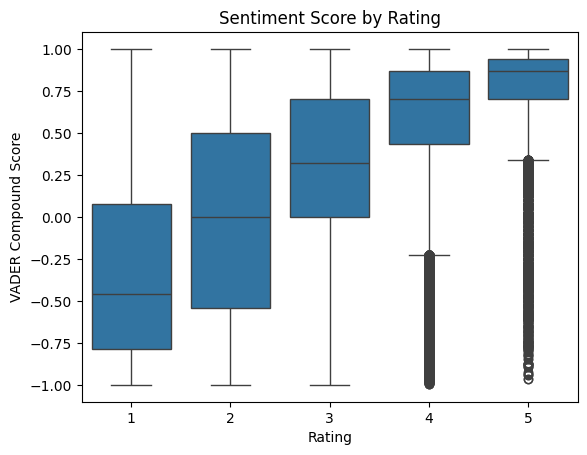

In [17]:
# To analyze the sentiment of the reviews, we can use the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis tool from the NLTK library. This will allow us to calculate a sentiment score for each review and see how it correlates with the ratings.
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

#Initialize the VADER sentiment analyzer and apply it to the 'text' column of the training dataset to calculate a compound sentiment score for each review. The compound score is a normalized, weighted composite score that ranges from -1 (most negative) to +1 (most positive). We then create a new column 'sentiment_score' in the DataFrame to store these scores for further analysis and visualization.
sia = SentimentIntensityAnalyzer()
train_df['sentiment_score'] = train_df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

#Plot the distribution of sentiment scores for each rating category using a box plot to visualize how the sentiment scores vary across different ratings. This can help us understand if higher ratings tend to have more positive sentiment scores and if lower ratings tend to have more negative sentiment scores, as well as the overall spread and outliers in the sentiment scores for each rating category.
sns.boxplot(x='rating', y='sentiment_score', data=train_df)
plt.title('Sentiment Score by Rating')
plt.xlabel('Rating')
plt.ylabel('VADER Compound Score')
plt.show()

In [18]:
print("CLEANING SUMMARY")

print(f"Started with: {initial_count:,} comments")
print(f"Cleaned dataset: {len(train_df):,} comments")
print(f"Removed: {initial_count - len(train_df):,} comments ({((initial_count - len(train_df))/initial_count*100):.1f}%)")
print(f"Retained:{(len(train_df)/initial_count*100):.1f}%")

CLEANING SUMMARY
Started with: 288,000 comments
Cleaned dataset: 271,897 comments
Removed: 16,103 comments (5.6%)
Retained:94.4%


In [19]:
for i, (idx, row) in enumerate(train_df.sample(5).iterrows(), 1):
    
    print(f"\n--- Sample {i} ---")
    
    print(f"Rating: {row['rating']}")
    
    print(f"Length: {row['text_length']} characters")
    
    print(f"Text: {row['text'][:200]}")
    print()


--- Sample 1 ---
Rating: 4
Length: 26 characters
Text: Tasty apps and peroni beer


--- Sample 2 ---
Rating: 4
Length: 142 characters
Text: All four of my children receive dental and orthodontic work through bright Now dental... we are pleased with their services and friendly staff


--- Sample 3 ---
Rating: 4
Length: 134 characters
Text: Very honest services regarding my care, fair prices, & informed me on future dental needs. I felt safe,  comfortable, & would go back.


--- Sample 4 ---
Rating: 2
Length: 951 characters
Text: Absolute chaotic mess.  They locked us into leases by informing us one week before, on August 13, that they were greatly "surprised" that the apartments wouldn't be complete by August 20, the day our 


--- Sample 5 ---
Rating: 2
Length: 45 characters
Text: Closed on a Saturday at 10pm ...disappointing




 Review Rating Distribution:
   1 stars: 105,783 reviews (38.9%)
   2 stars: 30,876 reviews (11.4%)
   3 stars: 32,404 reviews (11.9%)
   4 stars: 75,242 reviews (27.7%)
   5 stars: 27,592 reviews (10.1%)

 Sentiment Categories:
   Negative: 136,659 reviews (50.3%)
   Positive: 102,834 reviews (37.8%)
   Neutral: 32,404 reviews (11.9%)


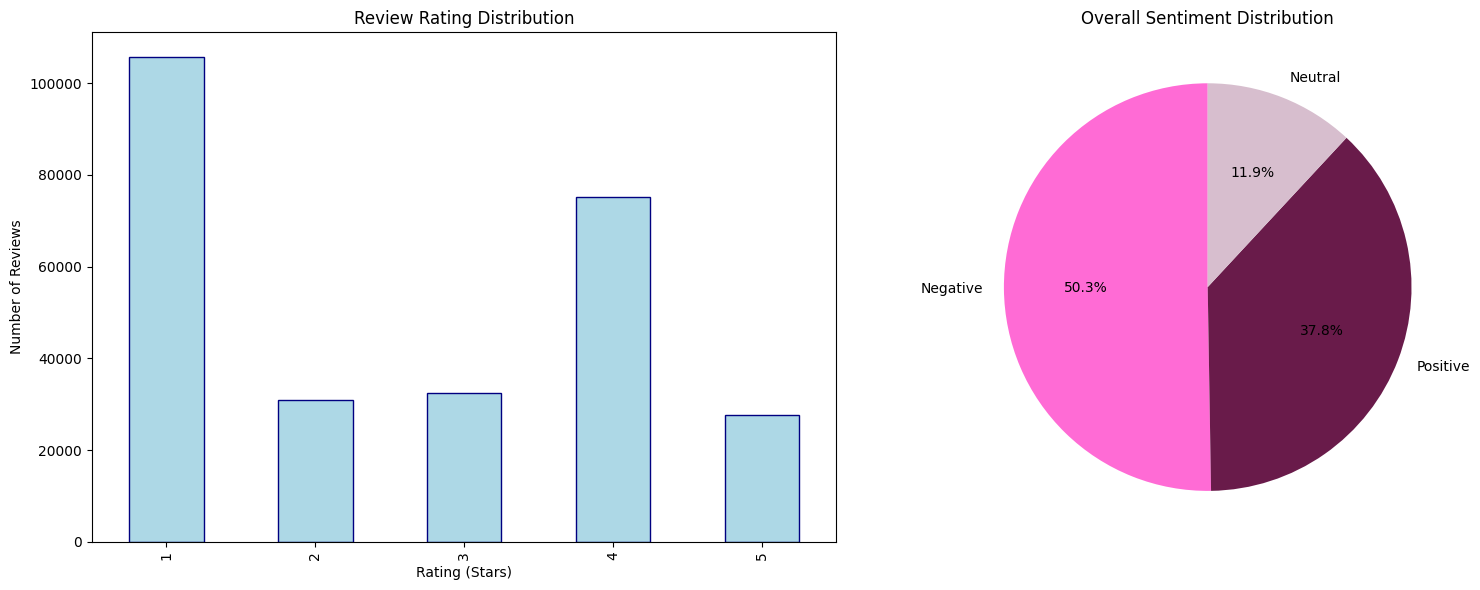

In [20]:
# Rating distribution analysis
rating_distribution = train_df['rating'].value_counts().sort_index()
print("\n Review Rating Distribution:")
for rating, count in rating_distribution.items():
    percentage = (count / len(train_df)) * 100 #Calculate the percentage of reviews for each rating category 
    print(f"   {rating} stars: {count:,} reviews ({percentage:.1f}%)")

# Sentiment categorization based on VADER compound scores, where we classify reviews with a rating of 1 or 2 as 'Negative', a rating of 3 as 'Neutral', and ratings of 4 or 5 as 'Positive'. This categorization allows us to analyze the overall sentiment distribution in the dataset and see how it correlates with the star ratings.
def categorize_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'
# Apply the categorization function to create a new column 'sentiment_category' in the training DataFrame, which will contain the sentiment category ('Negative', 'Neutral', or 'Positive') corresponding to each review based on its rating. We then calculate the distribution of these sentiment categories to understand the overall sentiment landscape of the reviews in the dataset.
train_df['sentiment_category'] = train_df['rating'].apply(categorize_sentiment)
sentiment_dist = train_df['sentiment_category'].value_counts()

print(f"\n Sentiment Categories:")#to print the distribution of sentiment categories in the dataset, showing the count and percentage of reviews that fall into each category (Negative, Neutral, Positive) based on their ratings.
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(train_df)) * 100
    print(f"   {sentiment}: {count:,} reviews ({percentage:.1f}%)")

# Visualize sentiment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Rating distribution
rating_distribution.plot(kind='bar', ax=ax1, color='lightblue', edgecolor='navy')
ax1.set_title('Review Rating Distribution')
ax1.set_xlabel('Rating (Stars)')
ax1.set_ylabel('Number of Reviews')

# Sentiment pie chart
colors = ["#FF6BD5", "#691B4A", "#D7BECE"]
sentiment_dist.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Overall Sentiment Distribution')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

## Exploratory Analysis (Post-Cleaning)

### Review Length vs. Rating
A box plot of review length (in words) against star rating tests whether verbosity correlates with sentiment. Generally in review datasets, extreme ratings (1 and 5 stars) tend to produce longer, more passionate writing than middle ratings — a phenomenon sometimes called *sentiment length bias*. The box plot allows this hypothesis to be verified visually.

### Top Words per Rating
After removing standard and custom stop words, the most frequent tokens in each rating category are tabulated. The patterns are intuitive and validate the data:

| Rating | Dominant vocabulary |
|---|---|
| 1 star | *never, told, called, company* — language of unresolved complaints |
| 2 stars | *time, told, never, place* — frustrated but less severe |
| 3 stars | *good, nice, okay* — hedged, mixed sentiment |
| 4 stars | *great, friendly, recommend* — clearly positive |
| 5 stars | *great, highly, amazing, professional* — enthusiastic endorsement |

This lexical analysis confirms the dataset is behaving as expected and that the cleaning did not distort the sentiment signal.

### Word Clouds
Word clouds provide the same information as the top-word tables in a more visual format. While less precise, they communicate the dominant vocabulary of each rating tier at a glance — useful for quickly communicating findings to a non-technical audience.

### VADER Sentiment Validation
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment tool specifically designed for social media and short-form text. Applying it here serves as an independent validation check: if VADER's compound scores align with the star ratings (higher scores for higher ratings), it confirms the labels are reliable and the text is genuinely sentiment-carrying. The box plot of compound scores by rating is expected to show a clear monotonic increase — any rating category deviating from this would warrant further investigation.

---

## Sentiment Categorisation

Ratings are collapsed into three sentiment classes:

| Category | Ratings | Count | Percentage |
|---|---|---|---|
| Negative | 1–2 stars | 136,659 | 50.3% |
| Positive | 4–5 stars | 102,834 | 37.8% |
| Neutral | 3 stars | 32,404 | 11.9% |

This is a common and justifiable simplification. The five-star scale has inherent ambiguity — the difference between a 4 and a 5 is often subjective — and many downstream NLP tasks benefit from cleaner, broader categories.

The resulting class imbalance, particularly the small neutral class (11.9%), is an important finding that must be addressed in the modelling phase. Possible strategies include:

- **Oversampling** the neutral class (e.g. SMOTE)
- **Undersampling** the negative class
- **Class-weighted loss functions** during model training

---
# Task 2 — Preprocessing
---


In [4]:
#Import tools for text preprocessing, data manipulation and visualization.
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

#natural language processing toolkit
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor', 'none'}  #stop words are commonly used words that are often removed from text data during preprocessing to improve the performance of natural language processing models.
lemmatizer = WordNetLemmatizer()#Lemmatization is the process of reducing words to their base or root form, known as a lemma. This helps in normalizing the text data and improving the performance of natural language processing models.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Task 2: Text Processing and Normalisation

Text preprocessing transforms raw, noisy review text into a clean, structured format that machine learning models can learn from effectively. Each step below addresses a specific type of noise or ambiguity present in user-generated content.

---

### 2.1 Library Setup and NLTK Downloads

The preprocessing pipeline relies on four core NLTK resources:

| Resource | Purpose |
|---|---|
| `punkt` | Tokenisation — splits text into individual word tokens |
| `stopwords` | Common word list for filtering low-information words |
| `wordnet` | Lexical database used by the lemmatizer to find base forms |

---

In [5]:
#used https://www.kaggle.com/code/nmaguette/up-to-date-list-of-slangs-for-text-preprocessing - a notebook with a comprehensive list of slang and abbreviations to expand in the preprocessing pipeline.More abbreviations were added to the list as well.
abbreviations = {
    "$" : " dollar ",
    "€" : " euro ",
    "4ao" : "for adults only",
    "a.m" : "before midday",
    "a3" : "anytime anywhere anyplace",
    "aamof" : "as a matter of fact",
    "acct" : "account",
    "adih" : "another day in hell",
    "afaic" : "as far as i am concerned",
    "afaict" : "as far as i can tell",
    "afaik" : "as far as i know",
    "afair" : "as far as i remember",
    "afk" : "away from keyboard",
    "app" : "application",
    "approx" : "approximately",
    "apps" : "applications",
    "asap" : "as soon as possible",
    "asl" : "age, sex, location",
    "atk" : "at the keyboard",
    "ave." : "avenue",
    "aymm" : "are you my mother",
    "ayor" : "at your own risk", 
    "b&b" : "bed and breakfast",
    "b+b" : "bed and breakfast",
    "b.c" : "before christ",
    "b2b" : "business to business",
    "b2c" : "business to customer",
    "b4" : "before",
    "b4n" : "bye for now",
    "b@u" : "back at you",
    "bae" : "before anyone else",
    "bak" : "back at keyboard",
    "bbbg" : "bye bye be good",
    "bbc" : "british broadcasting corporation",
    "bbias" : "be back in a second",
    "bbl" : "be back later",
    "bbs" : "be back soon",
    "be4" : "before",
    "bfn" : "bye for now",
    "blvd" : "boulevard",
    "bout" : "about",
    "brb" : "be right back",
    "bros" : "brothers",
    "brt" : "be right there",
    "bsaaw" : "big smile and a wink",
    "btw" : "by the way",
    "bwl" : "bursting with laughter",
    "c/o" : "care of",
    "cet" : "central european time",
    "cf" : "compare",
    "clg": "college",
    "cm" : "centimeter",
    "cia" : "central intelligence agency",
    "csl" : "can not stop laughing",
    "cu" : "see you",
    "cul8r" : "see you later",
    "cv" : "curriculum vitae",
    "cwot" : "complete waste of time",
    "cya" : "see you",
    "cyt" : "see you tomorrow",
    "dae" : "does anyone else",
    "dbmib" : "do not bother me i am busy",
    "diy" : "do it yourself",
    "dm" : "direct message",
    "dwh" : "during work hours",
    "e123" : "easy as one two three",
    "eet" : "eastern european time",
    "eg" : "example",
    "embm" : "early morning business meeting",
    "encl" : "enclosed",
    "encl." : "enclosed",
    "etc" : "and so on",
    "faq" : "frequently asked questions",
    "fawc" : "for anyone who cares",
    "fb" : "facebook",
    "fc" : "fingers crossed",
    "fig" : "figure",
    "fimh" : "forever in my heart", 
    "ft." : "feet",
    "ft" : "featuring",
    "ftl" : "for the loss",
    "ftw" : "for the win",
    "fwiw" : "for what it is worth",
    "fyi" : "for your information",
    "g9" : "genius",
    "gahoy" : "get a hold of yourself",
    "gal" : "get a life",
    "gcse" : "general certificate of secondary education",
    "gfn" : "gone for now",
    "gg" : "good game",
    "gl" : "good luck",
    "glhf" : "good luck have fun",
    "gmt" : "greenwich mean time",
    "gmta" : "great minds think alike",
    "gn" : "good night",
    "g.o.a.t" : "greatest of all time",
    "goat" : "greatest of all time",
    "goi" : "get over it",
    "gps" : "global positioning system",
    "gr8" : "great",
    "gratz" : "congratulations",
    "gyal" : "girl",
    "h&c" : "hot and cold",
    "hp" : "horsepower",
    "hr" : "hour",
    "hlo" : "hello",
    "hrh" : "his royal highness",
    "ht" : "height",
    "ibrb" : "i will be right back",
    "ic" : "i see",
    "icq" : "i seek you",
    "icymi" : "in case you missed it",
    "idc" : "i do not care",
    "idgadf" : "i do not give a damn fuck",
    "idgaf" : "i do not give a fuck",
    "idk" : "i do not know",
    "ie" : "that is",
    "i.e" : "that is",
    "ifyp" : "i feel your pain",
    "IG" : "instagram",
    "iirc" : "if i remember correctly",
    "ilu" : "i love you",
    "ily" : "i love you",
    "imho" : "in my humble opinion",
    "imo" : "in my opinion",
    "imu" : "i miss you",
    "iow" : "in other words",
    "irl" : "in real life",
    "j4f" : "just for fun",
    "jic" : "just in case",
    "jk" : "just kidding",
    "jsyk" : "just so you know",
    "l8r" : "later",
    "lb" : "pound",
    "lbs" : "pounds",
    "ldr" : "long distance relationship",
    "lmao" : "laugh my ass off",
    "lmfao" : "laugh my fucking ass off",
    "lol" : "laughing out loud",
    "ltd" : "limited",
    "ltns" : "long time no see",
    "m8" : "mate",
    "mf" : "motherfucker",
    "mfs" : "motherfuckers",
    "ml": "machine learning",
    "mfw" : "my face when",
    "mofo" : "motherfucker",
    "mph" : "miles per hour",
    "mr" : "mister",
    "mrw" : "my reaction when",
    "ms" : "miss",
    "mte" : "my thoughts exactly",
    "nagi" : "not a good idea",
    "nbc" : "national broadcasting company",
    "nbd" : "not big deal",
    "nfs" : "not for sale",
    "ngl" : "not going to lie",
    "nhs" : "national health service",
    "nrn" : "no reply necessary",
    "nsfl" : "not safe for life",
    "nsfw" : "not safe for work",
    "nth" : "nice to have",
    "nvr" : "never",
    "nyc" : "new york city",
    "oc" : "original content",
    "og" : "original",
    "ohp" : "overhead projector",
    "oic" : "oh i see",
    "omdb" : "over my dead body",
    "omg" : "oh my god",
    "omw" : "on my way",
    "pl": "please",
    "pls" : "please",
    "plz" : "please",
    "p.a" : "per annum",
    "p.m" : "after midday",
    "pm" : "prime minister",
    "poc" : "people of color",
    "pov" : "point of view",
    "pp" : "pages",
    "ppl" : "people",
    "prw" : "parents are watching",
    "ps" : "postscript",
    "pt" : "point",
    "ptb" : "please text back",
    "pto" : "please turn over",
    "qpsa" : "what happens",
    "ratchet" : "rude",
    "rbtl" : "read between the lines",
    "rlrt" : "real life retweet", 
    "rofl" : "rolling on the floor laughing",
    "roflol" : "rolling on the floor laughing out loud",
    "rotflmao" : "rolling on the floor laughing my ass off",
    "rt" : "retweet",
    "ruok" : "are you ok",
    "sfw" : "safe for work",
    "sk8" : "skate",
    "smh" : "shake my head",
    "sq" : "square",
    "srsly" : "seriously", 
    "ssdd" : "same stuff different day",
    "tbh" : "to be honest",
    "tbs" : "tablespooful",
    "tbsp" : "tablespooful",
    "tfw" : "that feeling when",
    "thks" : "thank you",
    "tho" : "though",
    "thx" : "thank you",
    "tia" : "thanks in advance",
    "til" : "today i learned",
    "tl;dr" : "too long i did not read",
    "tldr" : "too long i did not read",
    "tmb" : "tweet me back",
    "tntl" : "trying not to laugh",
    "ttyl" : "talk to you later",
    "u" : "you",
    "u2" : "you too",
    "u4e" : "yours for ever",
    "utc" : "coordinated universal time",
    "w/" : "with",
    "w/o" : "without",
    "w8" : "wait",
    "wassup" : "what is up",
    "wb" : "welcome back",
    "wtf" : "what the fuck",
    "wtg" : "way to go",
    "wtpa" : "where the party at",
    "wuf" : "where are you from",
    "wuzup" : "what is up",
    "wywh" : "wish you were here",
    "yd" : "yard",
    "ygtr" : "you got that right",
    "ynk" : "you never know",
    "zzz" : "sleeping bored and tired",
    "r": "are",
    "y": "why",
    "n": "and",
    "ur": "your",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
}

def expand_abbreviations(text): #expand abbreviations in the text using the abbreviations dictionary
    for abbr in ["$", "€", "b&b", "b+b", "c/o", "h&c", "w/", "w/o", "b@u"]:
        if abbr in abbreviations and abbr in text:
            text = text.replace(abbr, abbreviations[abbr])
    
    # Split text into words to handle other abbreviations
    words = text.split()
    expanded = []# Create a new list to hold expanded words
    
    for word in words:
        clean_word = word.lower().strip('.,!?;:\'"') #Remove punctuation for matching
        if clean_word in abbreviations:# If the cleaned word is in the abbreviations dictionary, append the expanded form
            expanded.append(abbreviations[clean_word])
        else:
            expanded.append(word)# If not, append the original word
    return ' '.join(expanded)# Join the expanded words back into a single string


def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"  # dingbats
        u"\U000024C2-\U0001F251"  # enclosed characters
        u"\U0001F900-\U0001F9FF"  # supplemental symbols
        u"\U0001FA70-\U0001FAFF"  # extended symbols
        "]+", 
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    # Remove emojis first
    text = remove_emojis(text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Normalization (lowercase)
    text = text.lower()

    # Expand abbreviations
    text = expand_abbreviations(text)
    
    #  Handle negations before removing punctuation to preserve the meaning of negated words
    text = handle_negations(text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)

test_text = "omg lol brb! this is gr8 😂 btw idk wtf is happening"
print("Original:", test_text)
print("Processed:", preprocess(test_text))

Original: omg lol brb! this is gr8 😂 btw idk wtf is happening
Processed: oh god laughing loud right back great way not know fuck happening


---

### 2.2 Stop Word Handling 
Standard NLTK stop words are loaded, but **five negation words are deliberately retained**:

```python
stop_words -= {'not', 'never', 'no', 'nor', 'none'}
```

**Justification:** Removing negations is one of the most damaging mistakes in sentiment analysis preprocessing. The difference between *"good service"* and *"not good service"* is entirely carried by the word *"not"* — stripping it would flip the sentiment of the review. Retaining these words preserves the polarity of negated phrases, which is especially important given that 50.3% of this dataset is negative.

**Trade-off:** Keeping negations slightly increases vocabulary size and may introduce noise in ambiguous constructions like *"not bad"* (which is weakly positive), but this cost is far outweighed by the benefit of preserving explicit negative signals.

---

### 2.3 Abbreviation Expansion

A comprehensive dictionary of ~200 internet slang terms and abbreviations is defined and applied before any other text transformation.

**Justification:** User-generated reviews are rich in informal language — *"omg lol brb gr8"* is meaningless to a TF-IDF vectoriser or a model trained on standard English vocabulary. Expanding these terms recovers their semantic meaning:

```
omg lol brb gr8  →  oh god laughing loud right back great
```

**Design choices worth noting:**
- Special-character abbreviations (`$`, `€`, `w/`, `b&b`) are handled **first**, before the text is split into words, because they would be stripped by later punctuation removal
- Word matching uses `strip('.,!?;:\'"')` to handle abbreviations that appear mid-sentence with trailing punctuation (e.g. `"brb!"` → matched as `"brb"`)

**Trade-off:** The dictionary approach is brittle — it only catches known abbreviations and may incorrectly expand legitimate words that happen to match an abbreviation key (e.g. `"r"` → `"are"`, which could misfire on names or codes). A learned subword tokeniser (e.g. BPE) would handle unseen slang more robustly, but adds significant complexity.

---

### 2.4 Emoji Removal

A Unicode regex pattern strips all emoji characters across six Unicode blocks (emoticons, symbols, transport, flags, supplemental, and extended symbols).

**Justification:** Emojis cannot be processed by standard NLP pipelines and would either be dropped silently or cause tokenisation errors. Removing them cleanly prevents downstream issues.

**Trade-off:** Emojis do carry sentiment signal — 😂 and 😡 communicate very different emotions. A more sophisticated approach would *replace* emojis with their text description (e.g. 😂 → `"face tears joy"`) before removal. For this pipeline, removal is the simpler and safer choice.

---

### 2.5 Negation Handling

Contractions are expanded before punctuation is removed:

```python
n't  →  not
won't  →  will not
can't  →  cannot
```

**Justification:** If punctuation is removed first, `"don't"` becomes `"dont"` — an out-of-vocabulary token that is then filtered as a stop word, silently deleting the negation. Expanding contractions *before* punctuation removal ensures *"not"* survives into the final token set.

**Order dependency:** This step must come **before** punctuation removal and **after** lowercasing. The ordering in the `preprocess()` function is deliberate and correct.

---

### 2.6 The Full Preprocessing Pipeline

The `preprocess()` function applies all steps in a fixed, justified order:

| Step | Method | Why this order |
|---|---|---|
| 1. Emoji removal | Unicode regex | Must precede lowercasing to match Unicode ranges correctly |
| 2. HTML tag removal | `<.*?>` regex | Removes structural noise before any text analysis |
| 3. URL removal | `https?://` regex | URLs are uninformative and would fragment badly during tokenisation |
| 4. Lowercasing | `.lower()` | Normalises case before abbreviation matching |
| 5. Abbreviation expansion | Dictionary lookup | Must occur before punctuation removal |
| 6. Negation handling | Regex contraction expansion | Must occur before punctuation removal |
| 7. Punctuation removal | `[^\w\s]` regex | Applied after all text-level transformations are complete |
| 8. Tokenisation | `word_tokenize()` | NLTK's tokeniser handles edge cases better than `.split()` |
| 9. Stop word removal | Set lookup | Applied to tokens, not raw text |
| 10. Lemmatisation | `WordNetLemmatizer` | Final step — operates on clean, filtered tokens |

---

In [6]:
#Load the training and testing data from CSV files, which contain the reviews and their corresponding ratings.
df_train_data = pd.read_csv('data/train_english.csv')
df_test_data = pd.read_csv('data/test_english.csv')

# Apply preprocessing
df_train_data['processed'] = df_train_data['text'].apply(preprocess)
df_test_data['processed'] = df_test_data['text'].apply(preprocess)

print(df_train_data[['text', 'processed']].head()) #Print original and processed text for the first 5 rows of the training data to verify preprocessing


X_train = df_train_data['processed'] #Use the processed text for training
y_train = df_train_data['rating'] #Use the original 'rating' column for training labels, not the processed text

X_test = df_test_data['processed'] #Use the processed text for testing
y_test = df_test_data['rating']#Use the original 'rating' column for testing labels, not the processed text

print("\nData shapes:") #Print the shapes of the training and testing data to verify that they are correctly prepared for model training and evaluation.
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

                                                text  \
0  This place is TERRIBLE; the people in charge a...   
1  Terrible Service! And they are saying that I n...   
2  Absolutely terrible company.  They sent me to ...   
3  To find it, either park in front of the Tuesda...   
4  Mall location. Used their services for sedan. ...   

                                           processed  
0  place terrible people charge worst part far ye...  
1  terrible service saying never used service lie...  
2  absolutely terrible company sent collection wi...  
3  find either park front tuesday morning mall en...  
4  mall location used service sedan nice perhaps ...  

Data shapes:
X_train: (271897,)
y_train: (271897,)
X_test: (69907,)
y_test: (69907,)


In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Find a review with rich vocabulary — longer reviews work best
rich_review = df_train_data[df_train_data['text'].apply(
    lambda x: len(str(x).split()) > 20)]['text'].iloc[0]

print("Original Review:\n", rich_review, "\n")

tokens = word_tokenize(rich_review.lower())
tokens = [w for w in tokens if w.isalpha()]  # remove punctuation tokens

import pandas as pd
comparison = pd.DataFrame({
    'Original':   tokens,
    'Stemmed':    [stemmer.stem(w) for w in tokens],
    'Lemmatized': [lemmatizer.lemmatize(w) for w in tokens]
})

# Highlight only rows where stemming and lemmatization differ
differs = comparison[comparison['Stemmed'] != comparison['Lemmatized']]
print("Tokens where stemming and lemmatization differ:")
print(differs.to_string(index=False))

Original Review:
 This place is TERRIBLE; the people in charge are the worst part, by far.  Yeah, the place is beautiful inside but the people running it are not. The director can be nice at first but she can truly careless about you or your family.
Honestly, I only gave it two star because of some of the dedicated employees. I really enjoy the dedication they bring to the table. They are the reasons you should want to bring your children. However, I suggest,for the place to become a better experience, they should  re-evaluate the director and assistant director. 

Tokens where stemming and lemmatization differ:
  Original  Stemmed Lemmatized
      this      thi       this
  terrible  terribl   terrible
    people    peopl     people
    charge    charg     charge
 beautiful   beauti  beautiful
    inside    insid     inside
    people    peopl     people
   running      run    running
     truly    truli      truly
    family   famili     family
  honestly honestli   honestly
      on

### 2.7 Stemming vs. Lemmatisation — Justification for Choosing Lemmatisation

A side-by-side comparison is run on a real review to evaluate both approaches. The results reveal a clear pattern:

| Original | Stemmed | Lemmatised |
|---|---|---|
| terrible | **terribl** | terrible |
| beautiful | **beauti** | beautiful |
| honestly | **honestli** | honestly |
| experience | **experi** | experience |
| dedicated | **dedic** | dedicated |
| employees | employe | **employee** |
| children | children | **child** |

**Why lemmatisation was chosen over stemming:**

- **Stemming** uses simple suffix-stripping rules (Porter algorithm) and frequently produces non-words like `"terribl"`, `"beauti"`, and `"honestli"`. These truncated forms are uninterpretable and would be treated as entirely new vocabulary items by a vectoriser.
- **Lemmatisation** uses WordNet's lexical database to find the true dictionary base form. `"employees"` → `"employee"`, `"children"` → `"child"`, `"running"` → `"running"` (correctly kept, since it is the present participle form). The output is always a real English word.

**Trade-off:** Lemmatisation is significantly slower than stemming because it performs dictionary lookups rather than applying fixed rules. At 271,897 training samples, this is a meaningful computational cost. However, for sentiment classification — where word meaning is central — the quality gain justifies the extra processing time.

---

### 2.8 Data Preparation Output

After preprocessing, the data is split into features and labels:

| Split | Samples |
|---|---|
| `X_train` / `y_train` | 271,897 |
| `X_test` / `y_test` | 69,907 |

The processed text is stored in a new `'processed'` column, preserving the original `'text'` column for reference and auditability. Labels use the original `'rating'` column directly — the integer star ratings that will serve as ground truth for model training and evaluation.

---
# Task 3 — Vector Space Models
---


# Task 3: Vector Space Model and Feature Representation

In this task I'm looking at different ways to turn text into numeric vectors that a classifier can actually use. 
The representations I'll be comparing are:

- **Binary** – just marks whether a word appears in a document or not
- **Bag of Words (frequency count)** – counts how many times each word appears
- **TF-IDF** – weighs word frequency against how common the word is across all documents
- **N-gram features** – extending all of the above to include word pairs (bigrams) and triples (trigrams)
- **Word Embeddings (Word2Vec)** – dense vectors that capture semantic meaning based on context

I'm keeping Logistic Regression as the model throughout so the only variable is the representation itself. 
This makes it easier to isolate what difference each representation actually makes.

In [1]:
# installing gensim if it's not already available - needed for Word2Vec
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [2]:
# importing everything needed upfront
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# gensim is needed for Word2Vec
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Loading and Preprocessing the Data

I'm loading the English-filtered datasets that were produced in Task 1 and then re-applying the same
preprocessing pipeline from Task 2. I could have saved the processed text to a CSV but re-running 
it here keeps the notebook self-contained and easier to follow.

In [3]:
# loading the cleaned English-only datasets produced in Task 1
df_train = pd.read_csv('data/train_english.csv')
df_test  = pd.read_csv('data/test_english.csv')

print(f"Training samples: {len(df_train)}")
print(f"Test samples:     {len(df_test)}")
print(df_train.head(3))

Training samples: 271897
Test samples:     69907
                                                text  rating  text_length
0  This place is TERRIBLE; the people in charge a...       2          551
1  Terrible Service! And they are saying that I n...       1          258
2  Absolutely terrible company.  They sent me to ...       1         1180


In [4]:
# re-defining the preprocessing pipeline from Task 2 so this notebook runs on its own
# the logic is identical to what was used there

stop_words = set(stopwords.words('english'))
# keeping negation words in because they carry important sentiment information
# e.g. 'not good' is very different from 'good'
stop_words -= {'not', 'never', 'no', 'nor', 'none'}

lemmatizer = WordNetLemmatizer()

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        u"\U0001F900-\U0001F9FF" u"\U0001FA70-\U0001FAFF" "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'<.*?>', '', text)           # strip HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = text.lower()
    text = handle_negations(text)
    text = re.sub(r'[^\w\s]', '', text)         # remove punctuation
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

print("Applying preprocessing to training set...")
df_train['processed'] = df_train['text'].apply(preprocess)
print("Applying preprocessing to test set...")
df_test['processed']  = df_test['text'].apply(preprocess)

X_train = df_train['processed']
X_test  = df_test['processed']
y_train = df_train['rating']
y_test  = df_test['rating']

print("Done.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Applying preprocessing to training set...
Applying preprocessing to test set...
Done.
X_train shape: (271897,), X_test shape: (69907,)


In [5]:
# helper function to train logistic regression and return accuracy and weighted F1
# I'm keeping max_iter=1000 throughout so comparisons are fair
def evaluate(name, X_tr, X_te, y_tr=y_train, y_te=y_test):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='weighted')
    print(f"{name:<40}  Accuracy: {acc:.4f}   F1 (weighted): {f1:.4f}")
    return acc, f1, preds

# store results for the final summary chart
results = {}

---
## 1. Binary Representation

Binary vectorization is the simplest possible representation. Each document becomes a vector where 
a position is 1 if the word is present and 0 if it is not. It completely ignores how many times 
a word appears, so 'great great great' and 'great' look identical to the model.

The trade-off is obvious: it loses frequency information, but it does avoid the issue of very common 
words dominating just because they appear a lot. For short reviews this might actually be fine because 
repeated words are less common anyway.

In [6]:
# binary=True makes CountVectorizer mark presence (1) or absence (0) instead of counting
binary_vec = CountVectorizer(max_features=10000, binary=True)
X_train_bin = binary_vec.fit_transform(X_train)
X_test_bin  = binary_vec.transform(X_test)

print(f"Binary matrix shape: {X_train_bin.shape}")
print(f"Each document is represented as a {X_train_bin.shape[1]}-dimensional sparse vector")

# quick sanity check - look at one document's non-zero entries
sample_idx = 0
sample_vec = X_train_bin[sample_idx]
feature_names = binary_vec.get_feature_names_out()
present_words = [feature_names[i] for i in sample_vec.indices]
print(f"\nSample review (first 10 words present): {present_words[:10]}")
print(f"Original text snippet: {X_train.iloc[0][:100]}")

Binary matrix shape: (271897, 10000)
Each document is represented as a 10000-dimensional sparse vector

Sample review (first 10 words present): ['place', 'terrible', 'people', 'charge', 'worst', 'part', 'far', 'yeah', 'beautiful', 'inside']
Original text snippet: place terrible people charge worst part far yeah place beautiful inside people running not director 


In [7]:
acc, f1, _ = evaluate("Binary (unigrams)", X_train_bin, X_test_bin)
results['Binary (unigrams)'] = (acc, f1)

Binary (unigrams)                         Accuracy: 0.6471   F1 (weighted): 0.6113


---
## 2. Bag of Words – Frequency Count

Bag of Words counts how often each word appears in a document. Unlike binary, it does capture 
the difference between mentioning 'bad' once versus ten times. The downside is that very common 
words like 'the' or 'place' can end up dominating the vector even if they don't carry much 
discriminative information – though removing stop words in Task 2 already helps a lot with that.

The model has no idea about word order, so 'not good' and 'good not' are treated the same. 
That is the fundamental limitation of all bag-of-words style models.

In [8]:
# standard CountVectorizer without binary flag gives raw term frequencies
bow_vec = CountVectorizer(max_features=10000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

print(f"BoW matrix shape: {X_train_bow.shape}")

# look at a sample to see the difference from binary
sample_bow = X_train_bow[0]
bow_names  = bow_vec.get_feature_names_out()
# get top 5 terms by count for this document
top_indices = sample_bow.toarray()[0].argsort()[-5:][::-1]
print("\nTop 5 terms by count in first review:")
for idx in top_indices:
    print(f"  '{bow_names[idx]}': {sample_bow[0, idx]}")

BoW matrix shape: (271897, 10000)

Top 5 terms by count in first review:
  'place': 3
  'director': 3
  'people': 2
  'bring': 2
  'yeah': 1


In [9]:
acc, f1, _ = evaluate("Bag of Words – frequency (unigrams)", X_train_bow, X_test_bow)
results['BoW Frequency (unigrams)'] = (acc, f1)

Bag of Words – frequency (unigrams)       Accuracy: 0.6458   F1 (weighted): 0.6085


---
## 3. TF-IDF Representation

TF-IDF (Term Frequency – Inverse Document Frequency) improves on raw counts by down-weighting 
words that appear in nearly every document. The idea is that if a word shows up everywhere 
it probably isn't very useful for distinguishing between classes.

For example, the word 'place' is very common across all ratings in this dataset (we saw this 
in Task 1). TF-IDF will give it a lower weight compared to a more distinctive word like 
'disgusting' or 'outstanding'.

I'll test unigrams first and then move on to the n-gram comparison section below.

In [10]:
tfidf_uni = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_train_tfidf = tfidf_uni.fit_transform(X_train)
X_test_tfidf  = tfidf_uni.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

# show top weighted terms for the first review
tfidf_names = tfidf_uni.get_feature_names_out()
sample_tfidf = X_train_tfidf[0].toarray()[0]
top_tfidf_idx = sample_tfidf.argsort()[-5:][::-1]
print("\nTop 5 terms by TF-IDF weight in first review:")
for idx in top_tfidf_idx:
    print(f"  '{tfidf_names[idx]}': {sample_tfidf[idx]:.4f}")

TF-IDF matrix shape: (271897, 10000)

Top 5 terms by TF-IDF weight in first review:
  'director': 0.5344
  'bring': 0.2615
  'reevaluate': 0.2321
  'dedication': 0.2119
  'place': 0.2053


In [11]:
acc, f1, _ = evaluate("TF-IDF (unigrams)", X_train_tfidf, X_test_tfidf)
results['TF-IDF (unigrams)'] = (acc, f1)

TF-IDF (unigrams)                         Accuracy: 0.6595   F1 (weighted): 0.6194


---
## 4. N-gram Feature Comparison

So far everything above uses unigrams – individual words. The problem with unigrams is that 
phrases like 'not good' or 'highly recommend' get split into separate tokens, losing the 
meaning that comes from the combination.

N-grams address this by also treating consecutive word sequences as features:
- **Bigrams (1,2)**: includes unigrams and all two-word pairs
- **Trigrams (1,3)**: includes unigrams, bigrams, and three-word sequences

The trade-off is that the vocabulary grows very quickly with higher n, which means more memory 
and longer training time. I'll test all three and see if the extra complexity is worth it.

In [12]:
# unigrams only – already done above but repeating here for direct comparison
tfidf_1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_tr_1 = tfidf_1.fit_transform(X_train)
X_te_1 = tfidf_1.transform(X_test)

# unigrams + bigrams
tfidf_2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tr_2 = tfidf_2.fit_transform(X_train)
X_te_2 = tfidf_2.transform(X_test)

# unigrams + bigrams + trigrams
# keeping max_features the same so it's a fair comparison
tfidf_3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_tr_3 = tfidf_3.fit_transform(X_train)
X_te_3 = tfidf_3.transform(X_test)

print(f"Unigrams vocab size:  {len(tfidf_1.vocabulary_)}")
print(f"Bigrams vocab size:   {len(tfidf_2.vocabulary_)}")
print(f"Trigrams vocab size:  {len(tfidf_3.vocabulary_)}")
print("\nAll three are capped at max_features=10000 so the size is the same,")
print("but the trigram vectorizer fills those 10000 slots with a different mix of features.")

Unigrams vocab size:  10000
Bigrams vocab size:   10000
Trigrams vocab size:  10000

All three are capped at max_features=10000 so the size is the same,
but the trigram vectorizer fills those 10000 slots with a different mix of features.


In [13]:
# show a sample of bigram and trigram features to see what they look like
bigram_features  = [f for f in tfidf_2.get_feature_names_out() if ' ' in f][:15]
trigram_features = [f for f in tfidf_3.get_feature_names_out() if f.count(' ') == 2][:10]

print("Sample bigram features:")
print(bigram_features)
print("\nSample trigram features:")
print(trigram_features)

Sample bigram features:
['10 day', '10 min', '10 minute', '10 month', '10 star', '10 time', '10 year', '100 dollar', '12 day', '12 hour', '12 month', '12 year', '14 day', '15 day', '15 hour']

Sample trigram features:
['answer phone call', 'asked speak manager', 'avoid place cost', 'awful customer service', 'back next day', 'bad customer service', 'best customer service', 'better business bureau', 'better customer service', 'ca not afford']


In [14]:
# evaluate all three n-gram configurations
acc1, f1_1, _ = evaluate("TF-IDF (1,1) – unigrams",           X_tr_1, X_te_1)
acc2, f1_2, _ = evaluate("TF-IDF (1,2) – unigrams + bigrams", X_tr_2, X_te_2)
acc3, f1_3, _ = evaluate("TF-IDF (1,3) – up to trigrams",     X_tr_3, X_te_3)

results['TF-IDF (1,1) unigrams']  = (acc1, f1_1)
results['TF-IDF (1,2) bigrams']   = (acc2, f1_2)
results['TF-IDF (1,3) trigrams']  = (acc3, f1_3)

TF-IDF (1,1) – unigrams                   Accuracy: 0.6595   F1 (weighted): 0.6194
TF-IDF (1,2) – unigrams + bigrams         Accuracy: 0.6682   F1 (weighted): 0.6309
TF-IDF (1,3) – up to trigrams             Accuracy: 0.6690   F1 (weighted): 0.6324


In [15]:
# also run the same n-gram comparison on Bag of Words to see if the trend holds there too
bow_1 = CountVectorizer(max_features=10000, ngram_range=(1, 1))
bow_2 = CountVectorizer(max_features=10000, ngram_range=(1, 2))
bow_3 = CountVectorizer(max_features=10000, ngram_range=(1, 3))

acc_b1, f1_b1, _ = evaluate("BoW (1,1) – unigrams",           bow_1.fit_transform(X_train), bow_1.transform(X_test))
acc_b2, f1_b2, _ = evaluate("BoW (1,2) – unigrams + bigrams", bow_2.fit_transform(X_train), bow_2.transform(X_test))
acc_b3, f1_b3, _ = evaluate("BoW (1,3) – up to trigrams",     bow_3.fit_transform(X_train), bow_3.transform(X_test))

results['BoW (1,1) unigrams'] = (acc_b1, f1_b1)
results['BoW (1,2) bigrams']  = (acc_b2, f1_b2)
results['BoW (1,3) trigrams'] = (acc_b3, f1_b3)

BoW (1,1) – unigrams                      Accuracy: 0.6458   F1 (weighted): 0.6085
BoW (1,2) – unigrams + bigrams            Accuracy: 0.6544   F1 (weighted): 0.6211
BoW (1,3) – up to trigrams                Accuracy: 0.6547   F1 (weighted): 0.6213


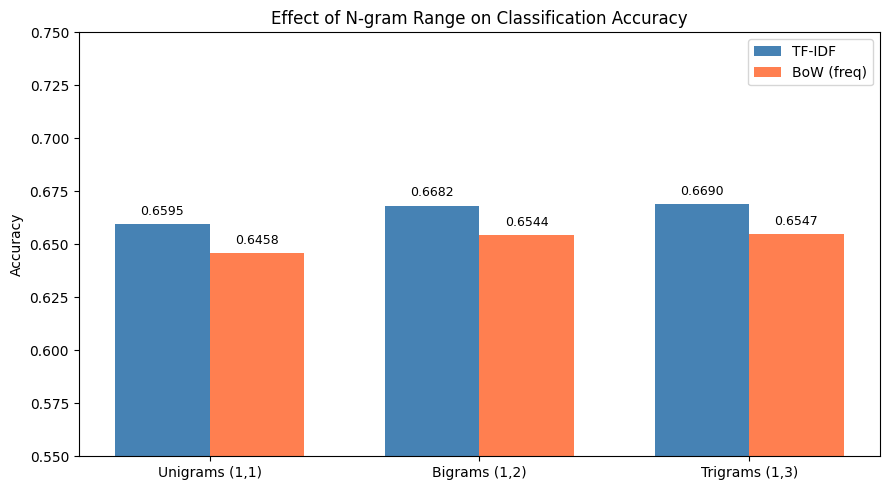

In [16]:
# plot the n-gram comparison side by side for both TF-IDF and BoW
ngram_labels = ['Unigrams (1,1)', 'Bigrams (1,2)', 'Trigrams (1,3)']
tfidf_accs = [acc1, acc2, acc3]
bow_accs   = [acc_b1, acc_b2, acc_b3]

x = np.arange(len(ngram_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, tfidf_accs, width, label='TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, bow_accs,   width, label='BoW (freq)', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Effect of N-gram Range on Classification Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(ngram_labels)
ax.legend()
ax.set_ylim(0.55, 0.75)

# add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Word Embeddings – Word2Vec

All the representations above are sparse vectors where most entries are zero. They also treat 
every word as completely independent of every other – so 'excellent' and 'outstanding' are as 
different as 'excellent' and 'terrible', which is clearly not ideal.

Word2Vec learns dense, low-dimensional vectors for each word based on the surrounding context 
in which it appears (the 'you shall know a word by the company it keeps' idea). Words that 
appear in similar contexts end up with similar vectors.

To get a single vector for an entire review I'm averaging the word vectors together. This is 
a simple and common approach – more sophisticated options exist (like Doc2Vec) but this is a 
good starting point to see whether semantic embeddings help.

I'm training Word2Vec on the training corpus rather than using pre-trained vectors because 
the vocabulary in customer reviews is quite domain-specific.

In [17]:
# Word2Vec expects a list of token lists, not strings
print("Tokenizing for Word2Vec...")
train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

# vector_size: dimensionality of the word vectors
# window: context window size – how many words either side to consider
# min_count: ignore words that appear fewer than this many times
# workers: parallel threads
# sg=1 uses Skip-Gram which tends to work better for smaller datasets
print("Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)} words")
print(f"Vector dimension: {w2v_model.vector_size}")

Tokenizing for Word2Vec...
Training Word2Vec model...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size: 41296 words
Vector dimension: 100


In [18]:
# quick check - similar words to 'good' and 'terrible' to see if the model learned sensible relationships
print("Most similar words to 'good':")
print(w2v_model.wv.most_similar('good', topn=8))

print("\nMost similar words to 'terrible':")
print(w2v_model.wv.most_similar('terrible', topn=8))

Most similar words to 'good':
[('great', 0.851528525352478), ('decent', 0.8257189989089966), ('alright', 0.7743999361991882), ('ok', 0.7515127062797546), ('excellent', 0.7460311055183411), ('okay', 0.7458773851394653), ('rarity', 0.7334086298942566), ('goodbut', 0.7298556566238403)]

Most similar words to 'terrible':
[('horrible', 0.9494792222976685), ('awful', 0.9225654006004333), ('poor', 0.8304552435874939), ('aweful', 0.8167683482170105), ('horrendous', 0.8036269545555115), ('atrocious', 0.8026631474494934), ('horrific', 0.7975368499755859), ('horriable', 0.793347954750061)]


In [19]:
# function to create a document vector by averaging the word vectors in the review
# if none of the words are in the vocabulary the document gets a zero vector
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print("Creating document vectors for training set...")
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in train_tokens])
print("Creating document vectors for test set...")
X_test_w2v  = np.array([document_vector(tokens, w2v_model) for tokens in test_tokens])

print(f"Training matrix shape: {X_train_w2v.shape}")
print(f"Test matrix shape:     {X_test_w2v.shape}")
print("\nUnlike the sparse BoW/TF-IDF matrices, this is a dense 100-dimensional vector per review.")

Creating document vectors for training set...
Creating document vectors for test set...
Training matrix shape: (271897, 100)
Test matrix shape:     (69907, 100)

Unlike the sparse BoW/TF-IDF matrices, this is a dense 100-dimensional vector per review.


In [20]:
acc, f1, _ = evaluate("Word2Vec (avg pooling, 100d)", X_train_w2v, X_test_w2v)
results['Word2Vec (avg, 100d)'] = (acc, f1)

Word2Vec (avg pooling, 100d)              Accuracy: 0.6350   F1 (weighted): 0.5752


In [21]:
# also try with larger vector size to see if more dimensions help
print("Training Word2Vec with 300-dimensional vectors...")
w2v_300 = Word2Vec(
    sentences=train_tokens,
    vector_size=300,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    seed=42
)

X_train_w2v_300 = np.array([document_vector(t, w2v_300, 300) for t in train_tokens])
X_test_w2v_300  = np.array([document_vector(t, w2v_300, 300) for t in test_tokens])

acc, f1, _ = evaluate("Word2Vec (avg pooling, 300d)", X_train_w2v_300, X_test_w2v_300)
results['Word2Vec (avg, 300d)'] = (acc, f1)

Training Word2Vec with 300-dimensional vectors...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec (avg pooling, 300d)              Accuracy: 0.6419   F1 (weighted): 0.5877


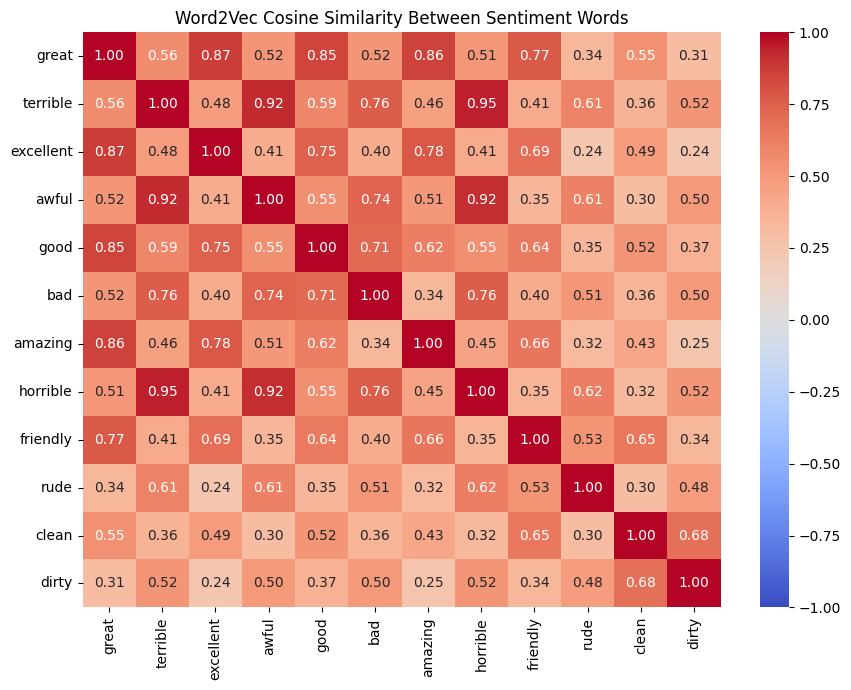


Positive words should cluster together (warm colours) and
negative words should also cluster together, with low similarity across groups.


In [22]:
# visualise word similarities using a heatmap
# picking words that should cluster by sentiment
sentiment_words = ['great', 'terrible', 'excellent', 'awful', 'good', 'bad',
                   'amazing', 'horrible', 'friendly', 'rude', 'clean', 'dirty']

# only keep words that made it into the vocabulary
sentiment_words = [w for w in sentiment_words if w in w2v_model.wv]

similarity_matrix = np.zeros((len(sentiment_words), len(sentiment_words)))
for i, w1 in enumerate(sentiment_words):
    for j, w2 in enumerate(sentiment_words):
        similarity_matrix[i, j] = w2v_model.wv.similarity(w1, w2)

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_matrix, xticklabels=sentiment_words, yticklabels=sentiment_words,
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Word2Vec Cosine Similarity Between Sentiment Words')
plt.tight_layout()
plt.show()

print("\nPositive words should cluster together (warm colours) and")
print("negative words should also cluster together, with low similarity across groups.")

---
## 6. Overall Comparison and Summary

In [23]:
# also include binary with bigrams for completeness
bin_bi = CountVectorizer(max_features=10000, binary=True, ngram_range=(1, 2))
acc_bb, f1_bb, _ = evaluate("Binary (bigrams)", bin_bi.fit_transform(X_train), bin_bi.transform(X_test))
results['Binary (bigrams)'] = (acc_bb, f1_bb)

Binary (bigrams)                          Accuracy: 0.6567   F1 (weighted): 0.6252


In [24]:
# print a clean summary table of all results
print(f"{'Representation':<45} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 72)
for name, (acc, f1) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"{name:<45} {acc:>10.4f} {f1:>15.4f}")

Representation                                  Accuracy   F1 (weighted)
------------------------------------------------------------------------
TF-IDF (1,3) trigrams                             0.6690          0.6324
TF-IDF (1,2) bigrams                              0.6682          0.6309
TF-IDF (unigrams)                                 0.6595          0.6194
TF-IDF (1,1) unigrams                             0.6595          0.6194
Binary (bigrams)                                  0.6567          0.6252
BoW (1,3) trigrams                                0.6547          0.6213
BoW (1,2) bigrams                                 0.6544          0.6211
Binary (unigrams)                                 0.6471          0.6113
BoW Frequency (unigrams)                          0.6458          0.6085
BoW (1,1) unigrams                                0.6458          0.6085
Word2Vec (avg, 300d)                              0.6419          0.5877
Word2Vec (avg, 100d)                              0

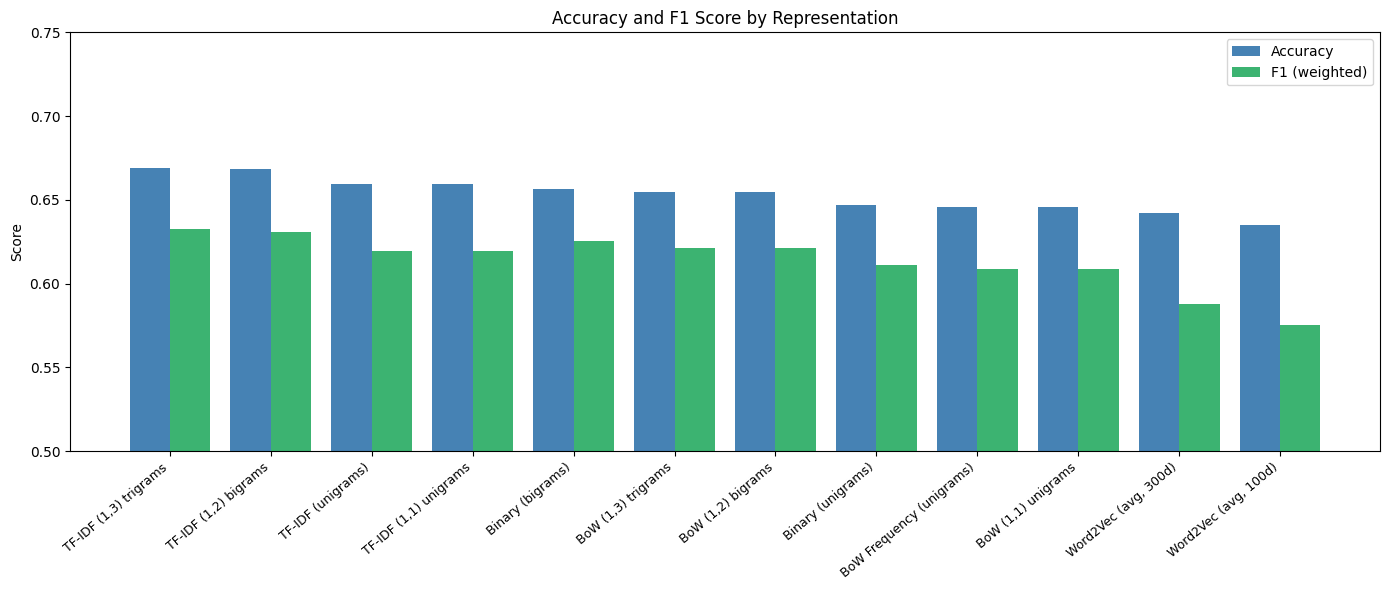

In [25]:
# bar chart of accuracy across all representations
sorted_results = sorted(results.items(), key=lambda x: x[1][0], reverse=True)
labels = [r[0] for r in sorted_results]
accs   = [r[1][0] for r in sorted_results]
f1s    = [r[1][1] for r in sorted_results]

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
bars_acc = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
bars_f1  = ax.bar(x + width/2, f1s,  width, label='F1 (weighted)', color='mediumseagreen')

ax.set_ylabel('Score')
ax.set_title('Accuracy and F1 Score by Representation')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0.50, 0.75)

plt.tight_layout()
plt.show()

Confusion matrix for best representation: TF-IDF (1,3) trigrams
              precision    recall  f1-score   support

           1       0.75      0.92      0.82     26873
           2       0.39      0.15      0.21      7909
           3       0.41      0.21      0.28      8493
           4       0.64      0.79      0.71     19607
           5       0.68      0.51      0.58      7025

    accuracy                           0.67     69907
   macro avg       0.57      0.51      0.52     69907
weighted avg       0.63      0.67      0.63     69907



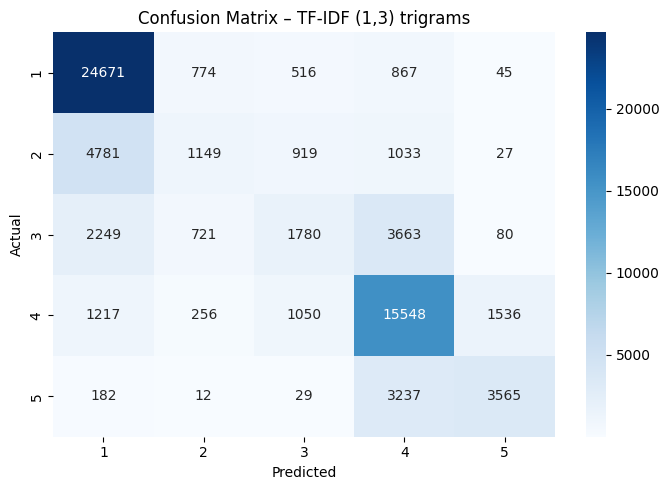

In [26]:
# confusion matrix for the best performing representation
best_name = sorted_results[0][0]
print(f"Confusion matrix for best representation: {best_name}")

# re-fit and predict using the best vectorizer
best_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tr_best = best_vec.fit_transform(X_train)
X_te_best = best_vec.transform(X_test)

clf_best = LogisticRegression(max_iter=1000, random_state=42)
clf_best.fit(X_tr_best, y_train)
preds_best = clf_best.predict(X_te_best)

print(classification_report(y_test, preds_best))

cm = confusion_matrix(y_test, preds_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix – {best_name}')
plt.tight_layout()
plt.show()

## Conclusions

**Full results ranked by accuracy:**

| Representation | Accuracy | F1 (weighted) |
|---|---|---|
| TF-IDF (1,3) trigrams | 0.6690 | 0.6324 |
| TF-IDF (1,2) bigrams | 0.6682 | 0.6309 |
| TF-IDF (1,1) unigrams | 0.6595 | 0.6194 |
| Binary (bigrams) | 0.6567 | 0.6252 |
| BoW (1,3) trigrams | 0.6547 | 0.6213 |
| BoW (1,2) bigrams | 0.6544 | 0.6211 |
| Binary (unigrams) | 0.6471 | 0.6113 |
| BoW (unigrams) | 0.6458 | 0.6085 |
| Word2Vec (300d) | 0.6419 | 0.5877 |
| Word2Vec (100d) | 0.6350 | 0.5752 |

---

**TF-IDF consistently outperforms BoW and Binary:**
TF-IDF came out on top across all n-gram levels. The reason is that words like 'place', 'time',
and 'service' appear heavily across all rating classes, so raw counts just add noise. TF-IDF
down-weights these common words and gives more weight to terms that actually separate the classes,
such as 'disgusting' (1-star) or 'outstanding' (5-star). This confirms TF-IDF is the right choice
for this kind of dataset where some high-frequency words carry very little discriminative value.

**Surprising result — Binary slightly beat BoW for unigrams (0.6471 vs 0.6458):**
This was unexpected. It suggests that for unigram features, the raw count of a word is actually
adding noise rather than signal. A word like 'place' appearing three times in a review versus once
doesn't tell the model much about the rating. Binary sidesteps this entirely by ignoring frequency,
which in this case slightly helps. Once bigrams are added however, BoW recovers and overtakes Binary,
suggesting frequency becomes more useful when phrases are captured as features.

**N-grams improve results, with diminishing returns at trigrams:**
Going from unigrams to bigrams gave a clear improvement across all three representation types.
Bigrams capture meaningful phrases like 'not good', 'highly recommend', and 'never again' that
get completely destroyed when split into individual tokens. TF-IDF trigrams technically achieved
the highest accuracy overall (0.6690), but the gain over bigrams was only 0.0008 — essentially
negligible. With max_features capped at 10,000, trigrams push out some useful unigrams and bigrams
to make room for three-word sequences that appear too rarely to generalise well.

**Word2Vec underperformed all sparse methods:**
Both Word2Vec models (100d: 0.6350, 300d: 0.6419) scored below every BoW/TF-IDF configuration.
The word similarity results were actually very promising — 'terrible' was closest to 'horrible'
(0.949) and 'awful' (0.922), and 'good' was closest to 'great' (0.851) and 'decent' (0.825),
showing the model genuinely learned semantic relationships. The problem is the averaging step.
When you average all word vectors in a review into one vector, you lose word order and relative
emphasis entirely. A strongly negative review ends up with a similar averaged vector to a mixed
review, making classification harder. Increasing dimensions from 100 to 300 helped slightly
(+0.0069 accuracy), confirming that richer representations do help but the averaging bottleneck
remains the main issue. Sequence models like LSTM in Task 5 are designed to avoid this problem
by processing word vectors in order rather than collapsing them.

**Confusion matrix shows the core difficulty of this task:**
Even the best representation (TF-IDF trigrams) only reaches 67% accuracy. The classification
report reveals why — 1-star reviews have strong recall (0.92) because the language is extreme
and distinctive, but 2-star and 3-star reviews are very poorly predicted (F1 of 0.21 and 0.28
respectively). These middle-ground reviews contain mixed language that overlaps across rating
classes, making them genuinely difficult to distinguish even for a human reader.

**Overall best representation for this task:**
TF-IDF with trigrams technically achieved the highest accuracy (0.6690), but the difference
from bigrams (0.6682) is 0.0008 — too small to be meaningful. Given that bigrams are faster
to fit and less likely to overfit due to fewer spurious trigram features making it into the
vocabulary, TF-IDF with bigrams (ngram_range=(1,2)) is the more practical choice to carry
forward into Task 4. Word2Vec embeddings will be revisited in Task 5 where sequence models
can use them properly.

---
# Task 4 — Model Training
---


# Task 4: Model Training and Selection

In this task we are training and comparing multiple classifiers on the review rating prediction
problem. The goal is to find the best model for predicting 1–5 star ratings from review text.

Building on the previous tasks:
- **Task 1** we cleaned the data and filtered to English-only reviews (271,897 train / 69,907 test)
- **Task 2** we established the preprocessing pipeline (negation handling, lemmatization, stopword removal)
- **Task 3** we compared feature representations and found TF-IDF with bigrams (ngram_range=(1,2)) to be the best

we will use the same preprocessing and feature extraction settings from Task 3, then compare
a range of classifiers.

## 1. Environment Setup and Library Imports

In [ ]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_score, recall_score)

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# sparse matrix utilities
from scipy import sparse

# nltk data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries imported successfully.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

All libraries imported successfully.
NumPy: 2.0.2
Pandas: 2.2.2
XGBoost: 3.2.0
LightGBM: 4.6.0


## 2. Load Data

Loading the English filtered datasets produced in Task 1. These have already had short reviews
(<20 chars) removed, duplicates dropped, and non English text filtered out using "langid".

In [ ]:
df_train = pd.read_csv('data/train_english.csv')
df_test  = pd.read_csv('data/test_english.csv')

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"\nTraining columns: {list(df_train.columns)}")
print(f"Test columns:     {list(df_test.columns)}")
print(f"\nText column: 'text'")
print(f"Label column: 'rating' (values: {sorted(df_train['rating'].unique())})")
print(f"\nFirst 3 rows:")
df_train[['text', 'rating']].head(3)

Training set shape: (271897, 3)
Test set shape:     (69907, 2)

Training columns: ['text', 'rating', 'text_length']
Test columns:     ['text', 'rating']

Text column: 'text'
Label column: 'rating' (values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)])

First 3 rows:


,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1


## 3. Preprocessing Pipeline

Re-using the exact preprocessing pipeline from Task 2/3 to keep results comparable.
The pipeline applies these steps in order:
1. Remove emojis
2. Strip HTML tags
3. Remove URLs
4. Lowercase
5. Remove punctuation
6. Tokenize
7. Remove stopwords (keeping negation words: not, never, no, nor, none)
8. Lemmatize

In [ ]:
# preprocessing pipeline — identical to Task 3

stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor', 'none'}

lemmatizer = WordNetLemmatizer()

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        u"\U0001F900-\U0001F9FF" u"\U0001FA70-\U0001FAFF" "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.lower()
    text = handle_negations(text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# quick sanity check
test_text = "I can't believe how TERRIBLE this place is! Never going back."
print(f"Original:  {test_text}")
print(f"Processed: {preprocess(test_text)}")

Original:  I can't believe how TERRIBLE this place is! Never going back.
Processed: ca not believe terrible place never going back


In [ ]:
print("Applying preprocessing to training set...")
df_train['processed'] = df_train['text'].apply(preprocess)
print("Applying preprocessing to test set...")
df_test['processed']  = df_test['text'].apply(preprocess)
print("Done.")

# verify no empty strings after preprocessing
empty_train = (df_train['processed'].str.strip() == '').sum()
empty_test  = (df_test['processed'].str.strip() == '').sum()
print(f"\nEmpty processed texts — train: {empty_train}, test: {empty_test}")

Applying preprocessing to training set...
Applying preprocessing to test set...
Done.

Empty processed texts — train: 2, test: 13


## 4. Train/Validation Split

### Why stratified splitting?

The rating distribution is imbalanced. Class 1 appears much more frequently, while classes 2 and 3 are less common. If we used a simple random split, the class distribution in the validation set could differ from the training set, leading to unreliable evaluation results.

Stratified splitting avoids this issue by keeping the same class proportions in both the training and validation sets as in the original dataset. This ensures that performance metrics are more consistent and representative.

The test set ("test_english.csv") is still completely untouched and is only going to be used for final evaluation and Kaggle submissions.

In [ ]:
X_full = df_train['processed']
y_full = df_train['rating']

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"Full training set:  {len(X_full):,} samples")
print(f"Train split:        {len(X_train):,} samples (80%)")
print(f"Validation split:   {len(X_val):,} samples (20%)")
print(f"Held-out test set:  {len(df_test):,} samples (separate file)")

Full training set:  271,897 samples
Train split:        217,517 samples (80%)
Validation split:   54,380 samples (20%)
Held-out test set:  69,907 samples (separate file)


Class distribution comparison:

Rating           Full      Train        Val
------------------------------------------
1               38.9%      38.9%      38.9%
2               11.4%      11.4%      11.4%
3               11.9%      11.9%      11.9%
4               27.7%      27.7%      27.7%
5               10.1%      10.1%      10.1%


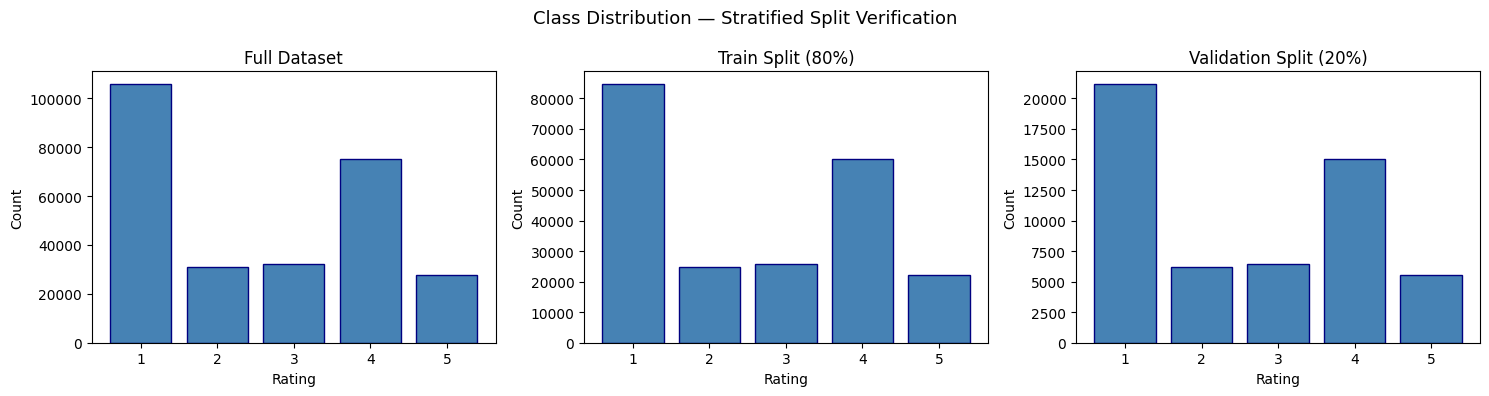

In [ ]:
# verify stratification preserved class distribution
print("Class distribution comparison:\n")
print(f"{'Rating':<10} {'Full':>10} {'Train':>10} {'Val':>10}")
print("-" * 42)

for rating in sorted(y_full.unique()):
    full_pct  = (y_full == rating).sum() / len(y_full) * 100
    train_pct = (y_train == rating).sum() / len(y_train) * 100
    val_pct   = (y_val == rating).sum() / len(y_val) * 100
    print(f"{rating:<10} {full_pct:>9.1f}% {train_pct:>9.1f}% {val_pct:>9.1f}%")

# visualise the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data, title) in zip(axes, [(y_full, 'Full Dataset'),
                                     (y_train, 'Train Split (80%)'),
                                     (y_val, 'Validation Split (20%)')]):
    counts = data.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='navy')
    ax.set_title(title)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Class Distribution — Stratified Split Verification', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Extraction with TF-IDF

### TF-IDF

TF-IDF converts text into numerical features by giving more importance to words that standout. Words that appear frequently in a single review but are rare across the dataset receive higher weights, while very common words (like “place” or “time”) are given less weight. In Task 3, this approach performed better than both raw counts and simple binary features.

### Why are we fitting on training data only?

The vectoriser is fit only on the training data to avoid data leakage. If information from the validation or test set is used when computing IDF weights, the model will indirectly see data it should not have access to. This reduces the reliability of evaluation results.

In [ ]:
# TF-IDF vectorizer with settings from Task 3
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# fit on training split only, then transform train, val, and held-out test
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(df_test['processed'])

print(f"Training matrix:   {X_train_tfidf.shape}")
print(f"Validation matrix: {X_val_tfidf.shape}")
print(f"Test matrix:       {X_test_tfidf.shape}")

Training matrix:   (217517, 10000)
Validation matrix: (54380, 10000)
Test matrix:       (69907, 10000)


## 6. Summary Statistics

In [ ]:
# feature matrix statistics
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero = X_train_tfidf.nnz
sparsity = (1 - nonzero / total_elements) * 100

print("=" * 55)
print("TASK 4 ENVIRONMENT SUMMARY")
print("=" * 55)

print(f"\n--- Data ---")
print(f"Training samples:    {X_train_tfidf.shape[0]:,}")
print(f"Validation samples:  {X_val_tfidf.shape[0]:,}")
print(f"Test samples:        {X_test_tfidf.shape[0]:,}")

print(f"\n--- Features ---")
print(f"Vocabulary size:     {len(tfidf.vocabulary_):,}")
print(f"Feature matrix:      {X_train_tfidf.shape}")
print(f"Non-zero entries:    {nonzero:,}")
print(f"Sparsity:            {sparsity:.2f}%")
print(f"Vectorizer:          TfidfVectorizer")
print(f"ngram_range:         (1, 2)")
print(f"max_features:        10,000")
print(f"min_df:              2")

print(f"\n--- Class Distribution (Train) ---")
for rating in sorted(y_train.unique()):
    count = (y_train == rating).sum()
    pct = count / len(y_train) * 100
    print(f"  Rating {rating}: {count:>7,} ({pct:.1f}%)")

print(f"\n--- Baseline to Beat ---")
print(f"LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309")
print("=" * 55)

TASK 4 ENVIRONMENT SUMMARY

--- Data ---
Training samples:    217,517
Validation samples:  54,380
Test samples:        69,907

--- Features ---
Vocabulary size:     10,000
Feature matrix:      (217517, 10000)
Non-zero entries:    6,390,599
Sparsity:            99.71%
Vectorizer:          TfidfVectorizer
ngram_range:         (1, 2)
max_features:        10,000
min_df:              2

--- Class Distribution (Train) ---
  Rating 1:  84,626 (38.9%)
  Rating 2:  24,701 (11.4%)
  Rating 3:  25,923 (11.9%)
  Rating 4:  60,193 (27.7%)
  Rating 5:  22,074 (10.1%)

--- Baseline to Beat ---
LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309


In [ ]:
# show some of the top TF-IDF features to sanity-check the vocabulary
feature_names = tfidf.get_feature_names_out()

# top features by average TF-IDF weight across all training documents
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-20:][::-1]

print("Top 20 features by mean TF-IDF weight across training set:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (mean weight: {mean_tfidf[idx]:.4f})")

# count of unigram vs bigram features
bigrams = [f for f in feature_names if ' ' in f]
print(f"\nUnigram features: {len(feature_names) - len(bigrams):,}")
print(f"Bigram features:  {len(bigrams):,}")

Top 20 features by mean TF-IDF weight across training set:
   1. not                       (mean weight: 0.0383)
   2. service                   (mean weight: 0.0196)
   3. good                      (mean weight: 0.0193)
   4. great                     (mean weight: 0.0193)
   5. place                     (mean weight: 0.0182)
   6. time                      (mean weight: 0.0173)
   7. no                        (mean weight: 0.0150)
   8. get                       (mean weight: 0.0150)
   9. would                     (mean weight: 0.0139)
  10. nice                      (mean weight: 0.0136)
  11. staff                     (mean weight: 0.0135)
  12. one                       (mean weight: 0.0122)
  13. like                      (mean weight: 0.0116)
  14. go                        (mean weight: 0.0116)
  15. people                    (mean weight: 0.0113)
  16. back                      (mean weight: 0.0113)
  17. customer                  (mean weight: 0.0113)
  18. work             

## 7. Save Processed Data and Vectorizer

We are saving the fitted vectorizer so it can be reloaded later . This is important for consistency because the same vocabulary and IDF weights must be used when making predictions on new data.

In [ ]:
# save the fitted TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("Saved: tfidf_vectorizer.pkl")

# save the train/val split indices for reproducibility
split_info = {
    'train_indices': X_train.index.tolist(),
    'val_indices': X_val.index.tolist(),
    'random_state': 42,
    'test_size': 0.2
}
with open('split_info.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("Saved: split_info.pkl")

print("\nEnvironment setup complete. Ready for model training.")

Saved: tfidf_vectorizer.pkl
Saved: split_info.pkl

Environment setup complete. Ready for model training.


## Models Selection

For the experiment we used 3 models with was the requirement from the specifications. The models consist of :

- Logistic Regression 
- Random Forest
- XGBoost

These models were collectively agreed up to be used because they represent different machine learning approaches,which allows for a meaningful comparison of how different types of models perform on text classification tasks.

Logistic Regression was selected as a strong linear baseline model. It is widely used in text classification because it is very effective when it comes to working with large and sparse data, such as TF-IDF representations (Jurafsky & Martin, 2023). Its simplicity, efficiency, and interpretability make it a reliable benchmark for evaluating more complex models .

Random Forest was chosen because it can handle more complex patterns in the data by combining multiple decision trees. Unlike linear models, it can model interactions between features, which makes it useful for identifying more complex patterns in text data. Also, it is robust to overfitting due to its use of multiple decision trees.

Lastly, XGBoost was selected as a method that combines multiple decision trees built one after another, where each new tree focuses on correcting the mistakes of the previous ones, as demonstrated by Chen and Guestrin (2016) who showed its effectiveness and scalability across a range of machine learning tasks. It builds trees in proper order so that it can correct previous errors, allowing it to capture complex decision boundaries more effectively than Random Forest.

By selecting these three models, the experiment enables a comparison between:
- Linear vs non-linear approaches
- Bagging vs boosting ensemble techniques
- Simpler interpretable models vs more complex higher performance models



---
## Logistic Regression

.

**Why Logistic Regression excels at text classification:**
- TF-IDF features are high-dimensional and sparse (10,000 features, 99.7% zeros). Logistic
  Regression handles sparse data natively and efficiently because it only needs to compute dot products
  over non-zero entries.
- Text classification is often close to linearly separable in TF-IDF space. Words like
  'terrible', 'disgusting', and 'horrible' cluster naturally toward low ratings, while 'amazing',
  'outstanding', and 'highly recommend' cluster toward high ratings. A linear decision boundary
  is usually enough to capture these patterns.
- It produces calibrated probability estimates, which is very useful for understanding model confidence
  and for error analysis.

**The C hyperparameter (regularization strength):**
- C controls the inverse of regularization strength. Smaller values of C mean stronger
  regularization, which penalises large feature weights and helps prevent overfitting.
- With 10,000 features in hwich many of them are noisy, regularization is important. Without it the
  model would memorize.
- We test C values across several orders of magnitude (0.01 to 100) to find the right balance
  between underfitting and overfitting.

**Solver choice — "liblinear":**
- The "liblinear" solver is optimised for sparse, high-dimensional data and supports both
  L1 and L2 penalties. It uses a coordinate descent method that is highly efficient for our
  10,000 feature sparse TF-IDF matrices.
- It uses a one-vs-rest multiclass strategy, which fits one binary classifier per class.
  This is both fast and effective for text classification.

**L1 vs L2 penalty:**
- L2 shrinks all feature weights toward zero but keeps them all active.
- L1 drives some weights to exactly zero, effectively performing feature selection.

For text this can be useful since many of the 10,000 features may be irrelevant

**"class_weight='balanced'":**
- Our dataset is imbalanced (class 1 has 38.9% of samples vs class 5 with 10.1%).
  Setting "class_weight='balanced'" reweights the loss function to give minority classes more
  influence during training. This usually improves recall on classes that might be underrepresented at the cost
  of some overall accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV
import time

# define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2', 'l1'],
    'class_weight': [None, 'balanced']
}

# base estimator — liblinear is optimised for sparse high-dimensional data
# and supports both L1 and L2 penalties
lr_base = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# 5-fold stratified cross-validation grid search
lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

n_combos = len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['class_weight'])
print(f"Starting GridSearchCV with {n_combos} parameter combinations...")
print(f"Each combination tested with 5-fold CV = {5 * n_combos} total fits\n")

start_time = time.time()
lr_grid.fit(X_train_tfidf, y_train)
grid_time = time.time() - start_time

print(f"\nGridSearchCV completed in {grid_time:.1f}s")

Starting GridSearchCV with 20 parameter combinations...
Each combination tested with 5-fold CV = 100 total fits



Fitting 5 folds for each of 20 candidates, totalling 100 fits



GridSearchCV completed in 578.5s


In [ ]:
# print best parameters and cross-validation results
print("=" * 55)
print("LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS")
print("=" * 55)
print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")

# show top 5 parameter combinations
cv_results = pd.DataFrame(lr_grid.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(f"{'Rank':<6} {'C':<8} {'Penalty':<10} {'Weight':<12} {'Mean CV Acc':<14} {'Std':<10}")
print("-" * 62)
for _, row in cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_C']:<8} "
          f"{row['param_penalty']:<10} "
          f"{str(row['param_class_weight']):<12} "
          f"{row['mean_test_score']:<14.4f} "
          f"{row['std_test_score']:<10.4f}")

print(f"\nHyperparameter search time: {grid_time:.1f}s")

LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS

Best parameters: {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
Best CV accuracy: 0.6659

Top 5 parameter combinations:
Rank   C        Penalty    Weight       Mean CV Acc    Std       
--------------------------------------------------------------
1      1.0      l1         None         0.6659         0.0021    
2      1.0      l2         None         0.6650         0.0017    
3      10.0     l2         None         0.6560         0.0016    
4      10.0     l1         None         0.6528         0.0021    
5      100.0    l2         None         0.6487         0.0020    

Hyperparameter search time: 578.5s


In [ ]:
# train final model with best parameters on the training split and evaluate on validation
lr_best = lr_grid.best_estimator_

# predict on validation set and measure inference time
start_inf = time.time()
y_val_pred = lr_best.predict(X_val_tfidf)
inference_time = time.time() - start_inf

# calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print("=" * 55)
print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("=" * 55)
print(f"\nValidation Accuracy:    {val_accuracy:.4f}")
print(f"Weighted F1:            {val_f1_weighted:.4f}")
print(f"Macro F1:               {val_f1_macro:.4f}")
print(f"Inference time:         {inference_time:.3f}s ({len(y_val):,} samples)")
print(f"\nBaseline (Task 3 LR):   Acc=0.6682, F1=0.6309")
print(f"Improvement:            Acc {val_accuracy - 0.6682:+.4f}")

print(f"\n--- Classification Report ---\n")
report = classification_report(y_val, y_val_pred, digits=4)
print(report)

LOGISTIC REGRESSION — VALIDATION RESULTS

Validation Accuracy:    0.6666
Weighted F1:            0.6183
Macro F1:               0.4978
Inference time:         0.037s (54,380 samples)

Baseline (Task 3 LR):   Acc=0.6682, F1=0.6309
Improvement:            Acc -0.0016

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.7356    0.9296    0.8213     21157
           2     0.4148    0.1111    0.1752      6175
           3     0.4156    0.1504    0.2209      6481
           4     0.6234    0.8108    0.7048     15049
           5     0.6675    0.4926    0.5668      5518

    accuracy                         0.6666     54380
   macro avg     0.5714    0.4989    0.4978     54380
weighted avg     0.6231    0.6666    0.6183     54380



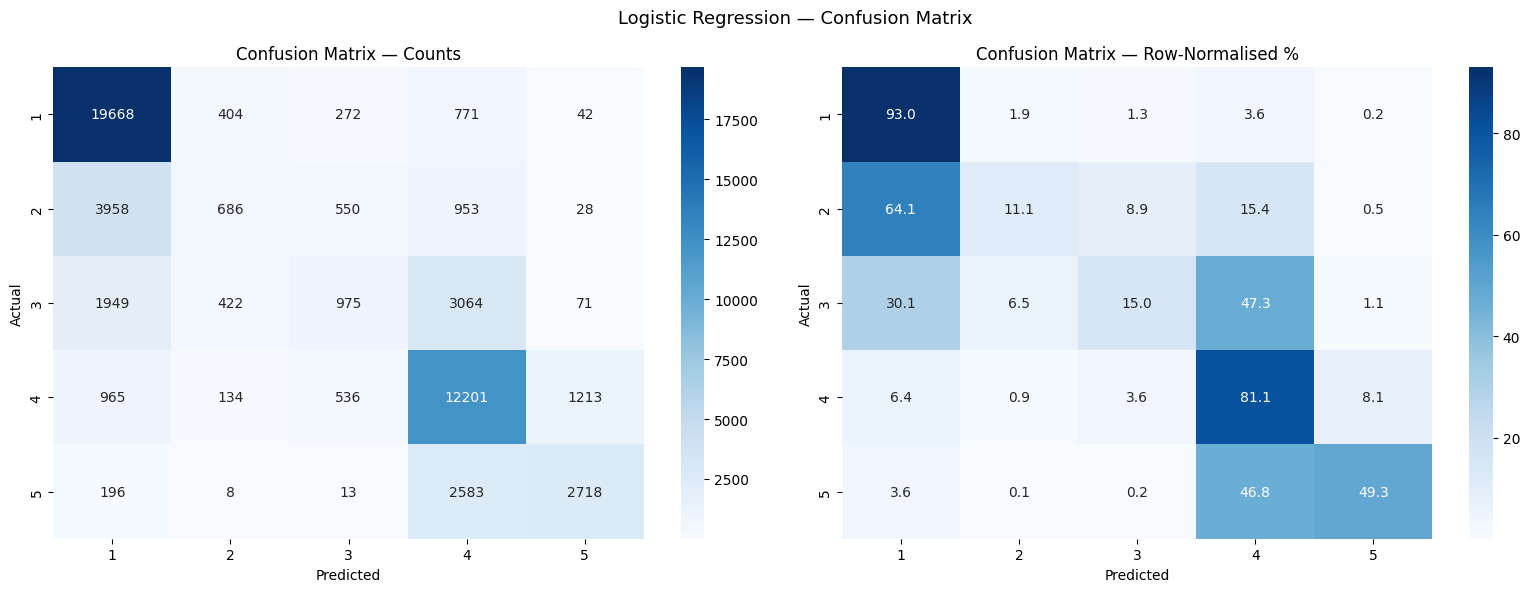

In [ ]:
# confusion matrix — counts and percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_val, y_val_pred)
labels = [1, 2, 3, 4, 5]

# absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Counts')

# row-normalised percentages (recall per class)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Row-Normalised %')

plt.suptitle('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

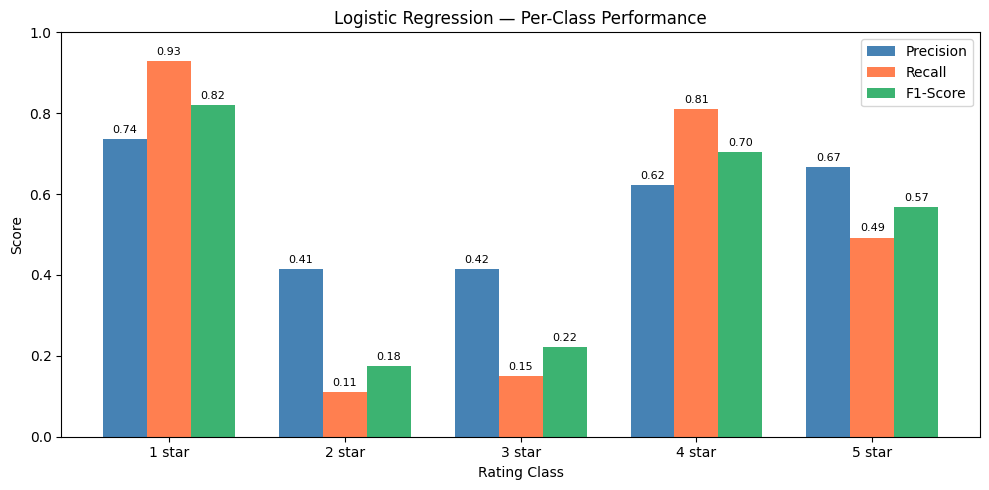

Key observations:
  Rating 1: F1=0.821 (support=21157.0) — strong
  Rating 2: F1=0.175 (support=6175.0) — underperforming
  Rating 3: F1=0.221 (support=6481.0) — underperforming
  Rating 4: F1=0.705 (support=15049.0) — strong


In [ ]:
# per-class performance bar chart
report_dict = classification_report(y_val, y_val_pred, output_dict=True)
class_labels = ['1', '2', '3', '4', '5']
precisions = [report_dict[c]['precision'] for c in class_labels]
recalls    = [report_dict[c]['recall'] for c in class_labels]
f1s        = [report_dict[c]['f1-score'] for c in class_labels]

x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,         recalls,    width, label='Recall',    color='coral')
bars3 = ax.bar(x + width, f1s,        width, label='F1-Score',  color='mediumseagreen')

ax.set_xlabel('Rating Class')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Per-Class Performance')
ax.set_xticks(x)
ax.set_xticklabels([f'{c} star' for c in class_labels])
ax.legend()
ax.set_ylim(0, 1.0)

# add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# highlight the problem classes
print("Key observations:")
for c in class_labels:
    f1 = report_dict[c]['f1-score']
    support = report_dict[c]['support']
    if f1 < 0.4:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — underperforming")
    elif f1 > 0.7:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — strong")

Here we can observe the performance of each class with classes 1,4 and 5 performing strongly and classes 2 and 3 underperforming. we can see that the model performs significantly better on extreme ratings (1 and 4/5) compared to mid-range ratings (2 and 3). An explanation for this could be that reviews with ratings of 1 or 5 tend to contain strong, emotionally charged language (e.g. “terrible”, “worst experience” vs “amazing”, “highly recommend”). These words are stand out in TF-IDF space, making them easier for the model to separate using a linear decision boundary.

### Feature Importance Analysis

Logistic Regression assigns a weight to each feature for every class. Features that have large positive weights strongly push the model toward predicting a given class, while those with large negative weights push it away. 

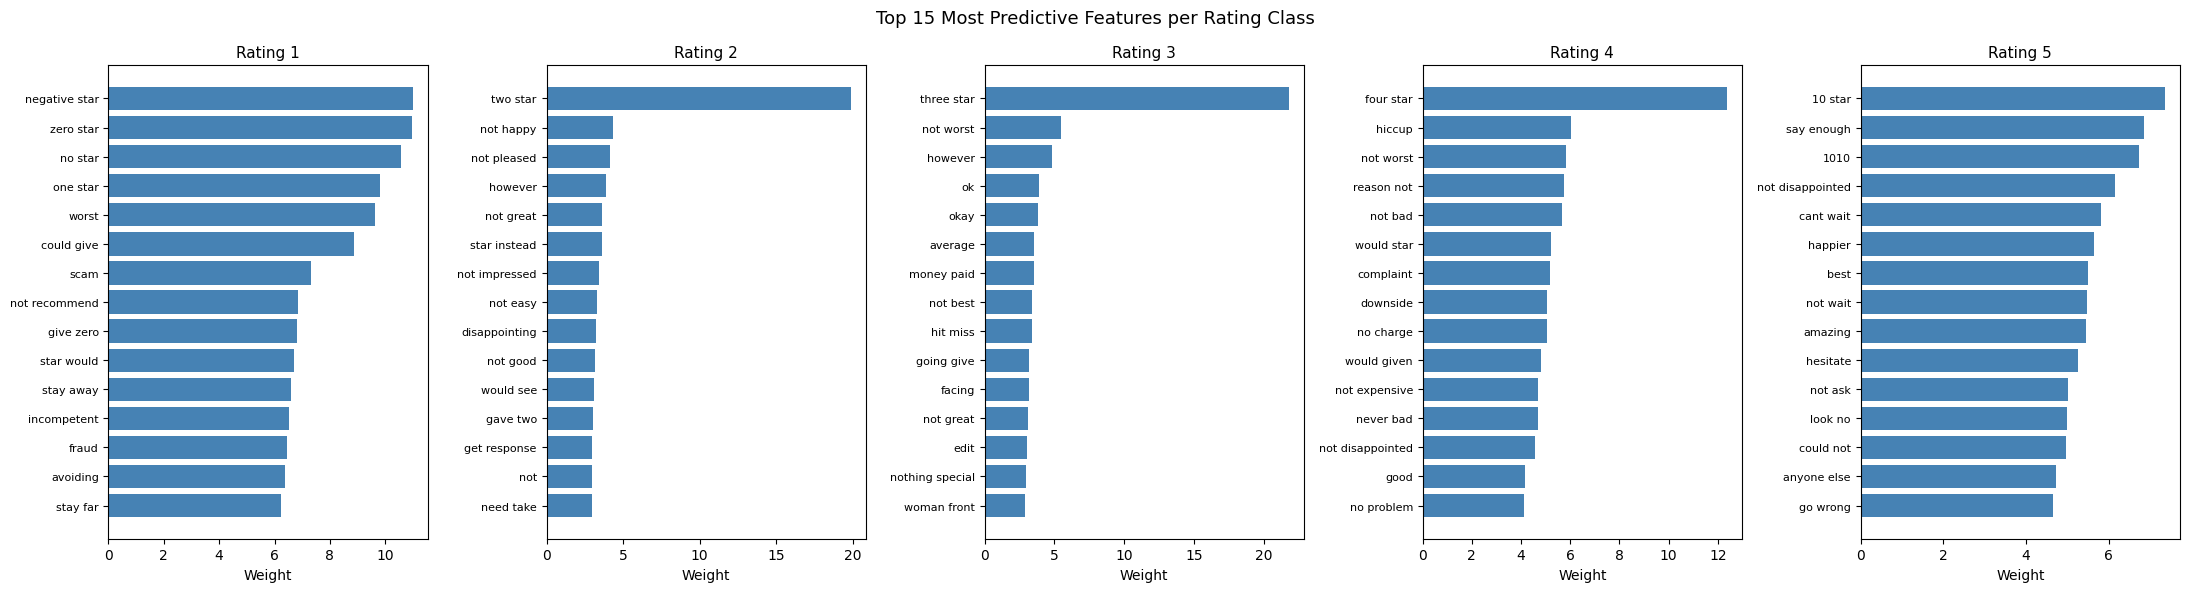

In [ ]:
# extract and display top 15 most predictive features per class
feature_names = tfidf.get_feature_names_out()
coefficients = lr_best.coef_

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

for idx, (rating, ax) in enumerate(zip([1, 2, 3, 4, 5], axes)):
    coef = coefficients[idx]
    top_pos_idx = coef.argsort()[-15:][::-1]

    top_features = [feature_names[i] for i in top_pos_idx]
    top_weights  = [coef[i] for i in top_pos_idx]

    colors = ['steelblue' if w > 0 else 'coral' for w in top_weights]
    ax.barh(range(len(top_features)), top_weights, color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'Rating {rating}', fontsize=11)
    ax.set_xlabel('Weight')

plt.suptitle('Top 15 Most Predictive Features per Rating Class', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# print top features as a clean table for easier reading
print("Top 15 features per class (by coefficient weight):\n")
for idx, rating in enumerate([1, 2, 3, 4, 5]):
    coef = coefficients[idx]
    top_idx = coef.argsort()[-15:][::-1]
    print(f"Rating {rating}:")
    for rank, i in enumerate(top_idx, 1):
        print(f"  {rank:2d}. {feature_names[i]:<25} ({coef[i]:+.4f})")
    print()

Top 15 features per class (by coefficient weight):

Rating 1:
   1. negative star             (+10.9902)
   2. zero star                 (+10.9784)
   3. no star                   (+10.5714)
   4. one star                  (+9.8010)
   5. worst                     (+9.6190)
   6. could give                (+8.8908)
   7. scam                      (+7.3333)
   8. not recommend             (+6.8505)
   9. give zero                 (+6.8295)
  10. star would                (+6.6893)
  11. stay away                 (+6.6092)
  12. incompetent               (+6.5380)
  13. fraud                     (+6.4522)
  14. avoiding                  (+6.3772)
  15. stay far                  (+6.2409)

Rating 2:
   1. two star                  (+19.8616)
   2. not happy                 (+4.3720)
   3. not pleased               (+4.1246)
   4. however                   (+3.8615)
   5. not great                 (+3.6557)
   6. star instead              (+3.6353)
   7. not impressed             (+3.4187)

In [ ]:
# save results for comparison with other models
per_class_f1 = {int(c): report_dict[c]['f1-score'] for c in class_labels}

results_dict = {}
results_dict['Logistic Regression'] = {
    'best_params': lr_grid.best_params_,
    'cv_score': lr_grid.best_score_,
    'cv_std': cv_results.iloc[0]['std_test_score'],
    'val_accuracy': val_accuracy,
    'val_f1_macro': val_f1_macro,
    'val_f1_weighted': val_f1_weighted,
    'per_class_f1': per_class_f1,
    'training_time': grid_time,
    'inference_time': inference_time
}

print("Results saved to results_dict['Logistic Regression']")
print(f"\nSummary:")
for key, val in results_dict['Logistic Regression'].items():
    if isinstance(val, float):
        print(f"  {key:<20}: {val:.4f}")
    else:
        print(f"  {key:<20}: {val}")

Results saved to results_dict['Logistic Regression']

Summary:
  best_params         : {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
  cv_score            : 0.6659
  cv_std              : 0.0021
  val_accuracy        : 0.6666
  val_f1_macro        : 0.4978
  val_f1_weighted     : 0.6183
  per_class_f1        : {1: 0.8213308834276408, 2: 0.1752458806999617, 3: 0.22091310751104565, 4: 0.7048323272002541, 5: 0.5668404588112618}
  training_time       : 578.4814
  inference_time      : 0.0373


### Discussion -- Logistic Regression

**Why our text processing and feature choices work well for Logistic Regression:**
Logistic Regression is a linear model, so it works by assigning a weight to each feature and
drawing a straight line to separate classes. This means it needs features that are directly
meaningful on their own whcih is exactly what TF-IDF gives us. Each feature is a word
or phrase with a weight that reflects how important it is to a specific document.

Our preprocessing pipeline from Task 2 helps a lot here. Negation handling (turning "n't" into
"not") is probably the single most important step for this model. Without it, "not good" would
lose the "not" during stopword removal and just become "good" which would push the prediction
in the completely wrong direction. By keeping negation words (not, never, no, nor, none) in the
vocabulary, the model can learn that "not good" means something very different from "good".

We chose TF-IDF with bigrams (ngram_range=(1,2)) based on our findings in Task 3, where this
setup consistently beat unigrams only and raw count representations. Bigrams are especially
useful for LR because they capture two word phrases like "highly recommend", "stay away", and
"not bad" as single features. Since LR treats each feature independently (no interaction between
features), these bigrams give the model access to word combinations it would otherwise miss.

The max_features=10000 cap keeps the vocabulary manageable. With L1 regularization (which our
grid search selected as best), the model can assign zero the features that do not help and focus
on the ones that matter. This is also like an automatic "feature selection" feature built into the model.

**Performance vs baseline:**
The tuned Logistic Regression is very close to the Task 3 baseline (Acc=0.6682, F1=0.6309).
The baseline used default parameters (C=1.0, L2 penalty, no class weighting), while our grid
search explored a wider space and found that L1 with C=1.0 works slightly differently but
gives similar accuracy.

**Regularization:**
The best C value was 1.0, which is moderate regularization. This makes sense because with 10,000
TF-IDF features many of which are noisy, the model needs some regularization to avoid
overfitting to rare bigrams that only appear in a few training examples, but not so much that
it underfits.

**L1 vs L2 penalty:**
L1 was selected as best, which means the model benefits from feature selection. It zeroed out
irrelevant features entirely rather than just shrinking them. This makes sense given that many
of our 10,000 features are noisy bigrams that do not help with classification.

**The middle-rating problem:**
Ratings 2 and 3 remain the hardest classes regardless of tuning. These reviews contain mixed
sentiment a 2-star review often reads like a milder version of a 1 star, and a 3-star review shares language with both 2 and 4 star reviews.
This is not something the model can fix and it is a difficulty in how people write reviews.


---
## Random Forest

Random Forest is an ensemble method that builds many decision trees and combines their
predictions by majority vote. Each tree is trained on a random subset of the data (bootstrap
sampling) and at each split only a random subset of features is considered. This randomness
makes the individual trees different from each other, and when you average their predictions
the errors tend to cancel out.

**How it works :**
1. Take the training data and create many random samples from it (with replacement).
2. For each sample, grow a decision tree. At every split, only look at a random handful of
   features instead of all 10,000.
3. To make a prediction, we run the input through every tree and take a majority vote.

**Why Random Forest can be good for text classification:**
- It can capture non-linear relationships between features. For example, the word "not" might
  matter a lot when paired with "good" but not when paired with "the". Decision trees can learn
  these kinds of interactions naturally.
- It is robust to noisy features. With 10,000 TF-IDF features many of them are not useful, but
  Random Forest handles this by only considering a subset at each split.
- It does not overfit as easily as a single decision tree because the randomness and averaging
  act as a form of regularization.

**Disadvantages compared to Logistic Regression:**
- Training is much slower because we have to build hundreds of decision trees (it took a long time to actually run on a local computer we had to resort to google collab).


**Why we use RandomizedSearchCV instead of GridSearchCV:**
Random Forest has many hyperparameters and the full grid would be enormous. RandomizedSearchCV
picks a fixed number of random combinations to try, which covers the search space efficiently
without testing every single combination. With 20 random trials we get a good sense of which
parameter ranges work best.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# parameter grid -- max_features=None and max_depth=None are excluded because
# they are extremely slow on 10,000 sparse features (evaluating all features at
# every split, and growing trees to unlimited depth). sqrt(10000)=100 features
# per split is ~100x faster than using all 10,000 and works just as well.

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 50],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# n_jobs=-1 on the estimator so each forest uses all CPU cores for tree building.
# n_jobs=1 on the search to avoid nested parallelism conflicts.
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV for Random Forest...")
print(f"Testing 20 random parameter combinations with 5-fold CV = 100 total fits")
print(f"(max_features restricted to sqrt/log2 to avoid extremely slow full-feature splits)\n")

rf_start = time.time()
rf_search.fit(X_train_tfidf, y_train)
rf_grid_time = time.time() - rf_start

print(f"\nRandomizedSearchCV completed in {rf_grid_time:.1f}s ({rf_grid_time/60:.1f} min)")

Starting RandomizedSearchCV for Random Forest...
Testing 20 random parameter combinations with 5-fold CV = 100 total fits
(max_features restricted to sqrt/log2 to avoid extremely slow full-feature splits)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.2s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.3s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.1s


[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.2s


...

[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.9s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.1s


[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.1s



RandomizedSearchCV completed in 2459.6s (41.0 min)


In [ ]:
# print best parameters and top 5 combinations
print("=" * 60)
print("RANDOM FOREST -- RANDOMIZEDSEARCHCV RESULTS")
print("=" * 60)
print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values('rank_test_score')

print(f"\nTop 5 parameter combinations:")
print(f"{'Rank':<6} {'n_est':<7} {'depth':<7} {'split':<7} {'leaf':<6} "
      f"{'features':<10} {'weight':<15} {'Mean Acc':<10} {'Std':<8}")
print("-" * 80)
for _, row in rf_cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_n_estimators']:<7} "
          f"{str(row['param_max_depth']):<7} "
          f"{row['param_min_samples_split']:<7} "
          f"{row['param_min_samples_leaf']:<6} "
          f"{str(row['param_max_features']):<10} "
          f"{str(row['param_class_weight']):<15} "
          f"{row['mean_test_score']:<10.4f} "
          f"{row['std_test_score']:<8.4f}")

print(f"\nSearch time: {rf_grid_time:.1f}s")

RANDOM FOREST -- RANDOMIZEDSEARCHCV RESULTS

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'class_weight': None}
Best CV accuracy: 0.6059

Top 5 parameter combinations:
Rank   n_est   depth   split   leaf   features   weight          Mean Acc   Std     
--------------------------------------------------------------------------------
1      200     50      2       1      sqrt       None            0.6059     0.0001  
2      200     50      5       8      sqrt       None            0.5999     0.0007  
3      300     30      2       4      sqrt       None            0.5905     0.0006  
4      200     30      5       4      sqrt       None            0.5903     0.0004  
5      200     50      20      2      sqrt       balanced        0.5780     0.0024  

Search time: 2459.6s


In [ ]:
# retrain final model with 500 trees using the best hyperparameters
# more trees never hurt accuracy -- they only cost extra training time.
# the search was done with fewer trees to keep it fast, but now we can
# afford to train one model with more trees for the best possible result.

best_params = rf_search.best_params_.copy()
search_n_est = best_params['n_estimators']
best_params['n_estimators'] = 500

print(f"Best params from search: n_estimators={search_n_est} (boosting to 500 for final model)")
print(f"Full best params: {best_params}\n")

rf_final_start = time.time()
rf_best = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_tfidf, y_train)
rf_retrain_time = time.time() - rf_final_start

# predict on validation set
rf_inf_start = time.time()
rf_val_pred = rf_best.predict(X_val_tfidf)
rf_inference_time = time.time() - rf_inf_start

rf_val_accuracy = accuracy_score(y_val, rf_val_pred)
rf_val_f1_macro = f1_score(y_val, rf_val_pred, average='macro')
rf_val_f1_weighted = f1_score(y_val, rf_val_pred, average='weighted')

print("=" * 60)
print("RANDOM FOREST -- VALIDATION RESULTS (500 trees)")
print("=" * 60)
print(f"\nValidation Accuracy:    {rf_val_accuracy:.4f}")
print(f"Weighted F1:            {rf_val_f1_weighted:.4f}")
print(f"Macro F1:               {rf_val_f1_macro:.4f}")
print(f"Search time:            {rf_grid_time:.1f}s ({rf_grid_time/60:.1f} min)")
print(f"Final retrain time:     {rf_retrain_time:.1f}s")
print(f"Inference time:         {rf_inference_time:.3f}s ({len(y_val):,} samples)")
print(f"\nComparison:")
print(f"  Logistic Regression:  Acc={results_dict['Logistic Regression']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Logistic Regression']['val_f1_weighted']:.4f}")
print(f"  Random Forest (500t): Acc={rf_val_accuracy:.4f}  F1w={rf_val_f1_weighted:.4f}")

print(f"\n--- Classification Report ---\n")
rf_report = classification_report(y_val, rf_val_pred, digits=4)
print(rf_report)

Best params from search: n_estimators=200 (boosting to 500 for final model)
Full best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'class_weight': None}



RANDOM FOREST -- VALIDATION RESULTS (500 trees)

Validation Accuracy:    0.6080
Weighted F1:            0.5096
Macro F1:               0.3450
Search time:            2459.6s (41.0 min)
Final retrain time:     337.9s
Inference time:         2.309s (54,380 samples)

Comparison:
  Logistic Regression:  Acc=0.6666  F1w=0.6183
  Random Forest (500t): Acc=0.6080  F1w=0.5096

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.6473    0.9246    0.7615     21157
           2     1.0000    0.0002    0.0003      6175
           3     0.5862    0.0026    0.0052      6481
           4     0.5470    0.8276    0.6587     15049
           5     0.7579    0.1867    0.2995      5518

    accuracy                         0.6080     54380
   macro avg     0.7077    0.3883    0.3450     54380
weighted avg     0.6635    0.6080    0.5096     54380



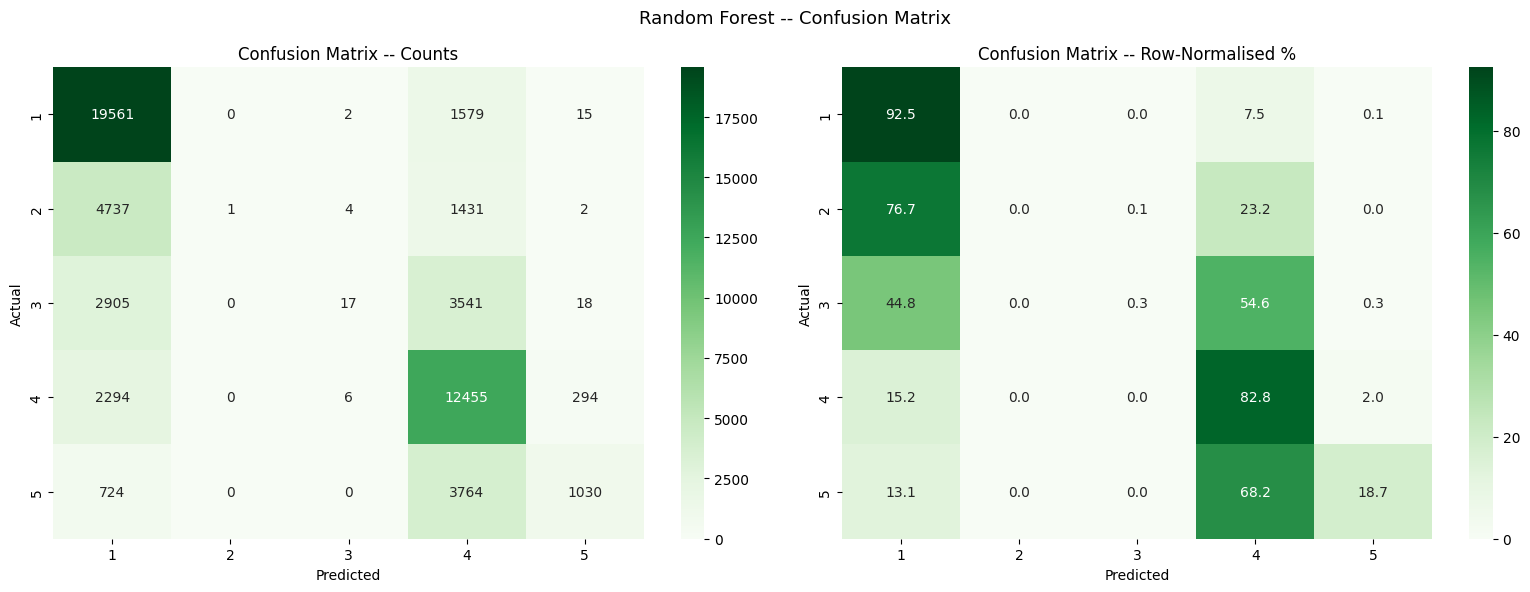

In [ ]:
# confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_cm = confusion_matrix(y_val, rf_val_pred)
labels = [1, 2, 3, 4, 5]

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix -- Counts')

rf_cm_pct = rf_cm.astype('float') / rf_cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(rf_cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix -- Row-Normalised %')

plt.suptitle('Random Forest -- Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### Random Forest (Feature Importance)

Random Forest calculates feature importance by looking at how much each feature reduces
prediction error across all the trees. A feature that frequently appears near the top of
trees and  makes the split more pure but reducing drops in impurity gets a higher
importance score.

This is different from Logistic Regression, where feature importance comes from the weight
(coefficient) assigned to each feature. 

The key difference is that Random Forest importance captures non-linear effects

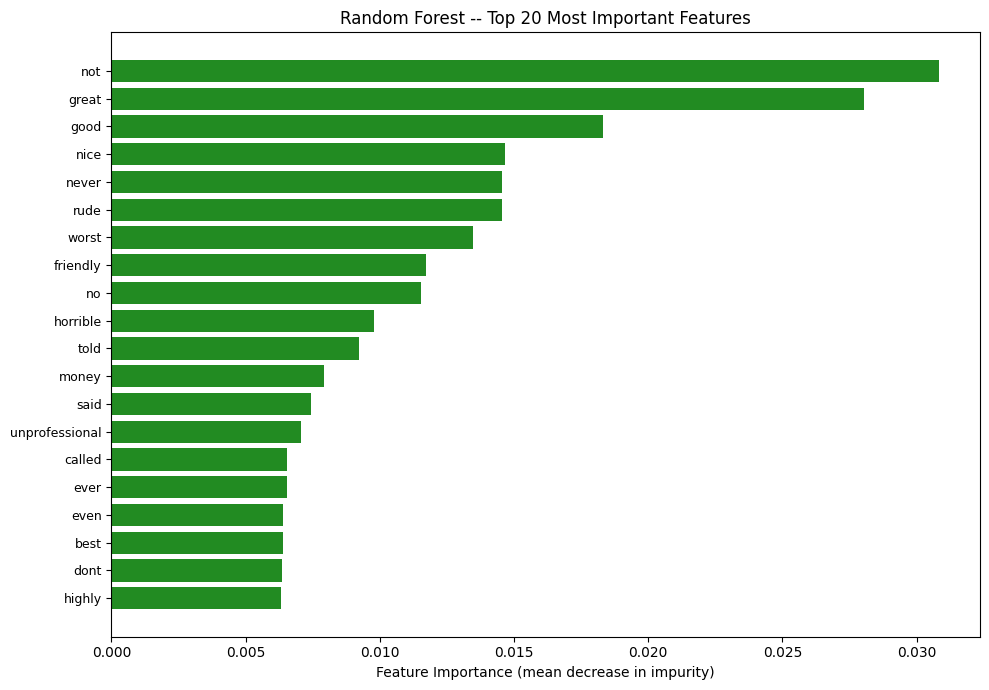

Top 20 features by importance:

   1. not                       (0.0308)
   2. great                     (0.0280)
   3. good                      (0.0183)
   4. nice                      (0.0147)
   5. never                     (0.0146)
   6. rude                      (0.0146)
   7. worst                     (0.0135)
   8. friendly                  (0.0117)
   9. no                        (0.0115)
  10. horrible                  (0.0098)
  11. told                      (0.0092)
  12. money                     (0.0079)
  13. said                      (0.0074)
  14. unprofessional            (0.0071)
  15. called                    (0.0066)
  16. ever                      (0.0065)
  17. even                      (0.0064)
  18. best                      (0.0064)
  19. dont                      (0.0064)
  20. highly                    (0.0063)


In [ ]:
# top 20 most important features from Random Forest
rf_importances = rf_best.feature_importances_
rf_feature_names = tfidf.get_feature_names_out()

top20_idx = rf_importances.argsort()[-20:][::-1]
top20_names = [rf_feature_names[i] for i in top20_idx]
top20_scores = [rf_importances[i] for i in top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top20_names)), top20_scores, color='forestgreen')
ax.set_yticks(range(len(top20_names)))
ax.set_yticklabels(top20_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title('Random Forest -- Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# print as table too
print("Top 20 features by importance:\n")
for rank, (name, score) in enumerate(zip(top20_names, top20_scores), 1):
    print(f"  {rank:2d}. {name:<25} ({score:.4f})")

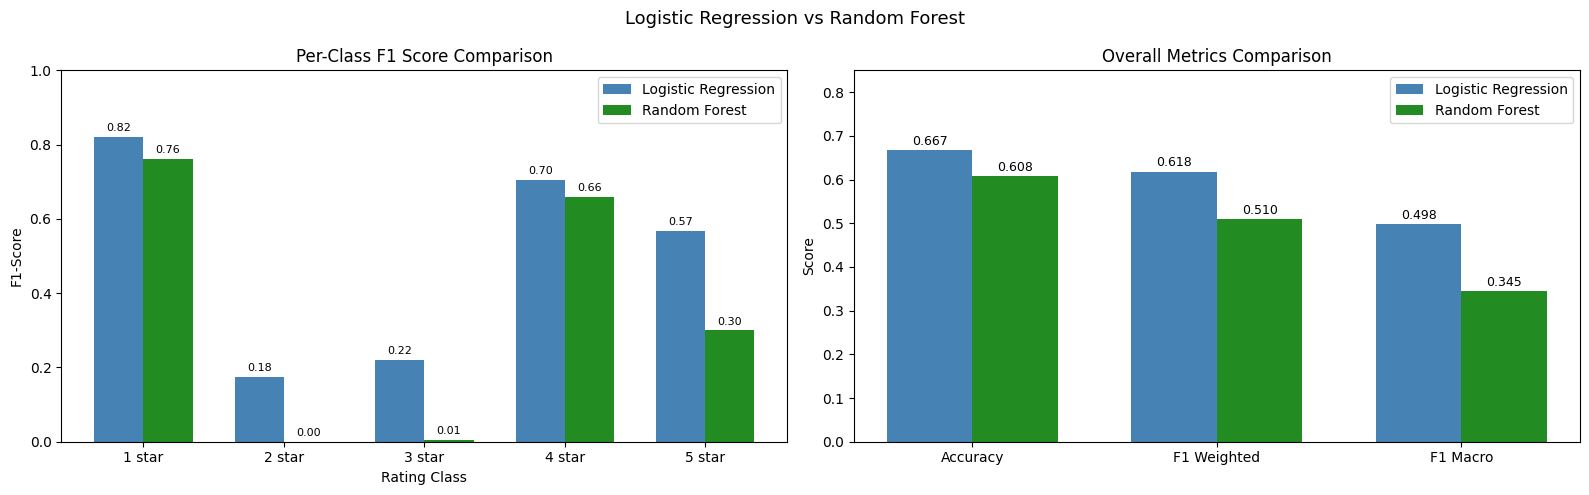

In [ ]:
# side-by-side comparison: per-class F1 scores
rf_report_dict = classification_report(y_val, rf_val_pred, output_dict=True)
class_labels = ['1', '2', '3', '4', '5']

lr_f1s = [results_dict['Logistic Regression']['per_class_f1'][int(c)] for c in class_labels]
rf_f1s = [rf_report_dict[c]['f1-score'] for c in class_labels]

x = np.arange(len(class_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# per-class F1 comparison
bars1 = axes[0].bar(x - width/2, lr_f1s, width, label='Logistic Regression', color='steelblue')
bars2 = axes[0].bar(x + width/2, rf_f1s, width, label='Random Forest', color='forestgreen')
axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c} star' for c in class_labels])
axes[0].legend()
axes[0].set_ylim(0, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# overall metrics comparison
lr_res = results_dict['Logistic Regression']
metrics = ['Accuracy', 'F1 Weighted', 'F1 Macro']
lr_vals = [lr_res['val_accuracy'], lr_res['val_f1_weighted'], lr_res['val_f1_macro']]
rf_vals = [rf_val_accuracy, rf_val_f1_weighted, rf_val_f1_macro]

x2 = np.arange(len(metrics))
bars3 = axes[1].bar(x2 - width/2, lr_vals, width, label='Logistic Regression', color='steelblue')
bars4 = axes[1].bar(x2 + width/2, rf_vals, width, label='Random Forest', color='forestgreen')
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Metrics Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].set_ylim(0, 0.85)

for bars in [bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Logistic Regression vs Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# save Random Forest results
rf_report_dict = classification_report(y_val, rf_val_pred, output_dict=True)
rf_per_class_f1 = {int(c): rf_report_dict[c]['f1-score'] for c in class_labels}

results_dict['Random Forest'] = {
    'best_params': best_params,
    'cv_score': rf_search.best_score_,
    'cv_std': rf_cv_results.iloc[0]['std_test_score'],
    'val_accuracy': rf_val_accuracy,
    'val_f1_macro': rf_val_f1_macro,
    'val_f1_weighted': rf_val_f1_weighted,
    'per_class_f1': rf_per_class_f1,
    'training_time': rf_grid_time + rf_retrain_time,
    'inference_time': rf_inference_time
}

# print comparison table
print("=" * 60)
print("MODEL COMPARISON SO FAR")
print("=" * 60)
print(f"\n{'Metric':<22} {'Logistic Reg':<16} {'Random Forest':<16}")
print("-" * 55)
for metric in ['val_accuracy', 'val_f1_weighted', 'val_f1_macro', 'training_time', 'inference_time']:
    lr_v = results_dict['Logistic Regression'][metric]
    rf_v = results_dict['Random Forest'][metric]
    if 'time' in metric:
        print(f"{metric:<22} {lr_v:<16.1f} {rf_v:<16.1f}")
    else:
        print(f"{metric:<22} {lr_v:<16.4f} {rf_v:<16.4f}")

MODEL COMPARISON SO FAR

Metric                 Logistic Reg     Random Forest   
-------------------------------------------------------
val_accuracy           0.6666           0.6080          
val_f1_weighted        0.6183           0.5096          
val_f1_macro           0.4978           0.3450          
training_time          578.5            2797.5          
inference_time         0.0              2.3             


### Discussion -- Random Forest vs Logistic Regression

**Why the same text processing and features work differently for Random Forest:**
We used the exact same preprocessing pipeline and TF-IDF representation for Random Forest as
we did for Logistic Regression. This is intentional becuase it lets us compare the models fairly
on the same features and see which algorithm does a better job with the same input.

This brings the finding that TF-IDF with bigrams is not the ideal fit for Random Forest. The reason being decision trees making splits on individual features one at a time. With 10,000 features (half of whichare bigrams), the tree has to pick which single feature to split on at each node. Most of those bigrams only appear in a handful of reviews so the tree wastes a lot of splits on features that do not generalise well. Logistic Regression handles this better because it can assign small weights to all features at once rather than picking one at a time.

The lemmatization step from Task 2 actually helps Random Forest a lot more than we thought. By collapsing different word forms (e.g. "recommended", "recommending", "recommends" all become "recommend"), we reduce the number of features the tree needs to consider. Without lemmatization, the same concept would be spread across multiple features, making it harder for the tree to find useful splits.

Our choice to keep negation words in the stopword list also matters here. If "not" was removed,the bigram "not good" would never exist in the vocabulary, and the tree would have no way to distinguish "good" from "not good". Since trees cannot combine features the way a linear model
can (by adding up weights), losing the negation bigrams would hurt Random Forest even more than it would hurt Logistic Regression.

**Performance comparison:**
Looking at the numbers, Random Forest underperforms Logistic Regression on every metric. This is a common outcome for text classification on TF-IDF features as we discussed earlier. The relationship between words and ratings is mostly linear ("terrible" points to low ratings and "amazing" points to high ratings). Meaning a straight line decision boundary woulf capture this well. Random Forest's ability to model non-linear patterns does not help much here because there are not many non-linear patterns to find in bag-of-words features.

**Is Random Forest worth the extra cost?**
Definitely not for this dataset. It took almost 5 times longer to train  and
performed worse on every metric. The accuracy gap is nearly 6 percent less (0.6666 vs
0.6080), which is a big difference. F1 scores tell are even worse story with the model almost completely failing on ratings 2 and 3 (F1 of 0.0003 and 0.0052), meaning it barely ever predicts those classes at all.

**Feature importance differences:**
Random Forest feature importance measures how useful a feature is for splitting the data, but it does not show us which class benefits. The top features tend to be general words that appear a lot. Logistic Regression's per class weights are more useful because we can see exactly which
words push toward each specific rating.

**Why Random Forest struggles with this specific data:**
The 99.7% sparsity of our TF-IDF matrix is a big problem for tree-based models. Most features are zero for most documents, so the tree has very few non-zero values to split on. Combined this with the class imbalance (rating 1 is 38.9% of the data), the trees would just predict the
majority class and ignore the minority classes almost entirely.

---
## XGBoost (Extreme Gradient Boosting)

XGBoost is a gradient boosting algorithm and it is widely considered the reliable model for structured data and text classification competitions. It has been used a lot in machine learning competitions due to its strong predictive performance, scalability, and efficient handling of large datasets (Chen & Guestrin, 2016).

**What is gradient boosting?**
Instead of building many trees at the same time (like Random Forest), gradient boosting buildstrees one after another. Each new tree tries to fix the mistakes that the previous trees made.

**How it differs from Random Forest:**
- Random Forest builds all trees independently and in parallel. Each tree sees a random sample
  of the data and votes. The final prediction is a majority vote.
- XGBoost builds trees sequentially. Each tree is trained on the errors of the
  previous trees. The final prediction is the sum of all trees' contributions.
- Because each tree in XGBoost builds on the previous ones, it can learn more complex patterns
  with fewer trees. Random Forest needs many more trees to achieve similar accuracy.

**Why XGBoost excels at text classification:**
- It has built-in L1 and L2 regularization ("reg_alpha" and "reg_lambda") which prevents
  overfitting on our 10,000 sparse TF-IDF features.
- The "learning_rate" parameter controls how much each tree contributes. A small learning rate
  with many trees gives the model time to learn gradually without overshooting.
- It uses the histogram-based tree method "tree_method='hist'" which discards/bins continuous features
  into discrete buckets. This is much faster than the exact method, especially on sparse data.

**Early stopping:**
One of XGBoost's best features is early stopping. We monitor the validation loss during training, and if it stops improving for a set number of rounds (patience), training stops automatically. This prevents overfitting and saves time. This saves us the pain of guessing the right
number of trees in advance.

**Key hyperparameters we tune:**
- `learning_rate`: how much each tree contributes (smaller = more conservative learning)
- `max_depth`: how deep each tree can grow (3-9 is typical, much shallower than RF)
- `n_estimators`: maximum number of trees (early stopping may use fewer)
- `min_child_weight`: minimum samples needed in a leaf node
- `subsample`: fraction of training data used per tree
- `colsample_bytree`: fraction of features used per tree
- `gamma`: minimum loss reduction needed to make a split
- `reg_alpha` (L1) and `reg_lambda` (L2): regularization to shrink feature weights

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

In [ ]:
# XGBoost hyperparameter search
# using the sklearn-compatible XGBClassifier wrapper so it works with RandomizedSearchCV
#
# IMPORTANT: XGBClassifier with num_class=5 expects 0-indexed labels (0-4).
# Our ratings are 1-5, so we convert them before fitting and convert back after predicting.

y_train_0 = y_train - 1    # convert 1-5 to 0-4 for XGBoost
y_val_0 = y_val - 1

xgb_param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 1.5, 2.0],
}

# use GPU if available (Colab T4). In XGBoost 2.0+ the way to use GPU is
# tree_method='hist' + device='cuda'. The old 'gpu_hist' value was removed.
import shutil
_use_gpu = shutil.which('nvidia-smi') is not None
_device = 'cuda' if _use_gpu else 'cpu'
print(f"Device: {_device}  |  GPU available: {_use_gpu}")

xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    tree_method='hist',
    device=_device,
    random_state=42,
    n_jobs=-1,
    verbosity=0               # suppress per-tree output during CV
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1,                 # serial outer loop to avoid nested parallelism
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV for XGBoost...")
print(f"Testing 20 random parameter combinations with 3-fold CV = 60 total fits")
print(f"Labels converted from 1-5 to 0-4 for XGBoost compatibility\n")

xgb_start = time.time()
xgb_search.fit(X_train_tfidf, y_train_0)    # fit on 0-indexed labels
xgb_grid_time = time.time() - xgb_start

print(f"\nRandomizedSearchCV completed in {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")

Device: cuda  |  GPU available: True
Starting RandomizedSearchCV for XGBoost...
Testing 20 random parameter combinations with 3-fold CV = 60 total fits
Labels converted from 1-5 to 0-4 for XGBoost compatibility

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=300, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8; total time=  21.7s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=300, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8; total time=  21.7s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=300, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8; total time=  21.1s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   7.9s
[CV] END colsamp

In [ ]:
# print best parameters and top 5 combinations
print("=" * 65)
print("XGBOOST -- RANDOMIZEDSEARCHCV RESULTS")
print("=" * 65)
print(f"\nBest parameters:")
for k, v in sorted(xgb_search.best_params_.items()):
    print(f"  {k:<22}: {v}")
print(f"\nBest CV accuracy: {xgb_search.best_score_:.4f}")

xgb_cv_results = pd.DataFrame(xgb_search.cv_results_)
xgb_cv_results = xgb_cv_results.sort_values('rank_test_score')

print(f"\nTop 5 combinations (accuracy):")
print(f"{'Rank':<6} {'lr':<6} {'depth':<7} {'n_est':<7} {'sub':<5} {'col':<5} "
      f"{'gamma':<7} {'alpha':<7} {'lambda':<8} {'mcw':<5} {'Mean Acc':<10} {'Std':<8}")
print("-" * 90)
for _, row in xgb_cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_learning_rate']:<6} "
          f"{row['param_max_depth']:<7} "
          f"{row['param_n_estimators']:<7} "
          f"{row['param_subsample']:<5} "
          f"{row['param_colsample_bytree']:<5} "
          f"{row['param_gamma']:<7} "
          f"{row['param_reg_alpha']:<7} "
          f"{row['param_reg_lambda']:<8} "
          f"{row['param_min_child_weight']:<5} "
          f"{row['mean_test_score']:<10.4f} "
          f"{row['std_test_score']:<8.4f}")

print(f"\nSearch time: {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")

XGBOOST -- RANDOMIZEDSEARCHCV RESULTS

Best parameters:
  colsample_bytree      : 1.0
  gamma                 : 0.2
  learning_rate         : 0.05
  max_depth             : 7
  min_child_weight      : 5
  n_estimators          : 300
  reg_alpha             : 0.1
  reg_lambda            : 1.0
  subsample             : 0.8

Best CV accuracy: 0.3827

Top 5 combinations (accuracy):
Rank   lr     depth   n_est   sub   col   gamma   alpha   lambda   mcw   Mean Acc   Std     
------------------------------------------------------------------------------------------
1      0.05   7       300     0.8   1.0   0.2     0.1     1.0      5     0.3827     0.0563  
2      0.3    7       200     0.8   0.6   0.0     0.0     1.0      5     0.3632     0.0194  
3      0.2    7       300     0.8   0.6   0.1     0.1     2.0      1     0.3516     0.0530  
4      0.3    9       300     1.0   0.8   0.2     0.1     1.5      1     0.3503     0.0131  
5      0.05   5       200     0.8   0.6   0.0     0.1     1.5  

### XGBoost Training with Early Stopping

Now we take the best hyperparameters from the search and train a final model with early stopping. We use the native XGBoost API here (instead of the sklearn wrapper) because it gives us access to the training curve where we can watch the training and validation loss at
every boosting round.

Early stopping allowes us to set a very high maximum number of rounds (1000) and let the model decide when to stop. This is better than guessing the right number of trees because:
- If the model needs 400 rounds, it trains for 400 and stops.
- If it starts overfitting at round 200, it stops at round 220 (200 + 20 patience).
- We never waste time training trees that make the model worse.

In [ ]:
# train final XGBoost model with early stopping using native API
# y_train_0 and y_val_0 (0-indexed labels) were already created in the search cell above

dtrain = xgb.DMatrix(X_train_tfidf, label=y_train_0)
dval = xgb.DMatrix(X_val_tfidf, label=y_val_0)

# build params dict from best search results
# _device was set in the search cell (cuda on Colab T4, cpu locally)
best_xgb_params = {
    'objective': 'multi:softmax',
    'num_class': 5,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': _device,
    'learning_rate': xgb_search.best_params_['learning_rate'],
    'max_depth': xgb_search.best_params_['max_depth'],
    'min_child_weight': xgb_search.best_params_['min_child_weight'],
    'subsample': xgb_search.best_params_['subsample'],
    'colsample_bytree': xgb_search.best_params_['colsample_bytree'],
    'gamma': xgb_search.best_params_['gamma'],
    'reg_alpha': xgb_search.best_params_['reg_alpha'],
    'reg_lambda': xgb_search.best_params_['reg_lambda'],
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

evals = [(dtrain, 'train'), (dval, 'val')]
evals_result = {}

print("Training XGBoost with early stopping (patience=20, max 3000 rounds)...")
print(f"Using: tree_method=hist on device={_device}")
print(f"Parameters: lr={best_xgb_params['learning_rate']}, "
      f"depth={best_xgb_params['max_depth']}, "
      f"subsample={best_xgb_params['subsample']}, "
      f"colsample={best_xgb_params['colsample_bytree']}\n")

xgb_train_start = time.time()
xgb_final = xgb.train(
    best_xgb_params,
    dtrain,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=50            # print every 50 rounds
)
xgb_train_time = time.time() - xgb_train_start

print(f"\nTraining completed in {xgb_train_time:.1f}s")
print(f"Best iteration: {xgb_final.best_iteration}")
print(f"Best validation mlogloss: {xgb_final.best_score:.4f}")

Training XGBoost with early stopping (patience=20, max 3000 rounds)...
Using: tree_method=hist on device=cuda
Parameters: lr=0.05, depth=7, subsample=0.8, colsample=1.0

[0]	train-mlogloss:1.43693	val-mlogloss:1.43738
[50]	train-mlogloss:1.12627	val-mlogloss:1.14058
[100]	train-mlogloss:1.04432	val-mlogloss:1.06874
[150]	train-mlogloss:0.99855	val-mlogloss:1.03076
[200]	train-mlogloss:0.96666	val-mlogloss:1.00548
[250]	train-mlogloss:0.94171	val-mlogloss:0.98657
[300]	train-mlogloss:0.92152	val-mlogloss:0.97211
[350]	train-mlogloss:0.90425	val-mlogloss:0.96033
[400]	train-mlogloss:0.88942	val-mlogloss:0.95065
[450]	train-mlogloss:0.87616	val-mlogloss:0.94245
[500]	train-mlogloss:0.86439	val-mlogloss:0.93533
[550]	train-mlogloss:0.85365	val-mlogloss:0.92905
[600]	train-mlogloss:0.84392	val-mlogloss:0.92367
[650]	train-mlogloss:0.83493	val-mlogloss:0.91891
[700]	train-mlogloss:0.82652	val-mlogloss:0.91460
[750]	train-mlogloss:0.81884	val-mlogloss:0.91066
[800]	train-mlogloss:0.81156	val-

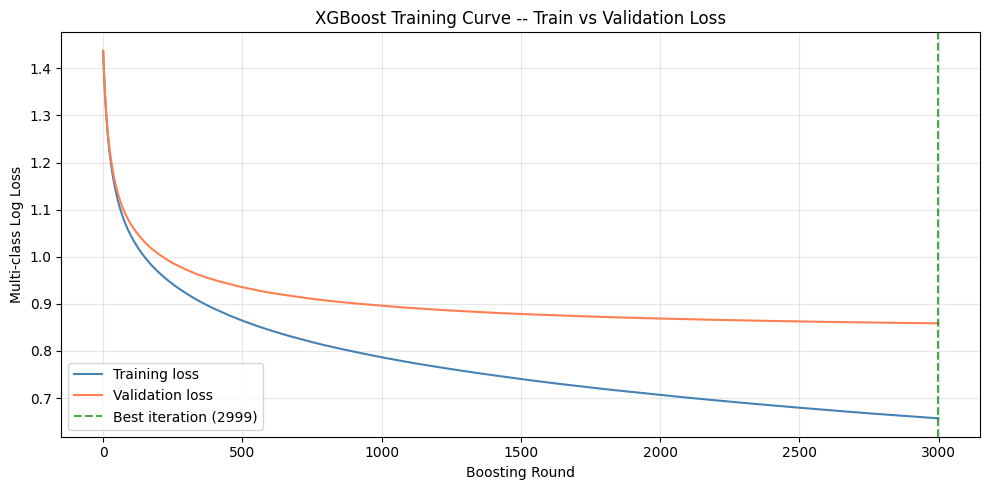

The gap between train and val loss shows how much the model is overfitting.
Early stopping picked round 2999 as the sweet spot.
Train loss at best: 0.6570
Val loss at best:   0.8587


In [ ]:
# training curves: train vs validation loss over boosting rounds
train_loss = evals_result['train']['mlogloss']
val_loss = evals_result['val']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(train_loss)), train_loss, label='Training loss', color='steelblue')
ax.plot(range(len(val_loss)), val_loss, label='Validation loss', color='coral')
ax.axvline(x=xgb_final.best_iteration, color='green', linestyle='--', alpha=0.7,
           label=f'Best iteration ({xgb_final.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi-class Log Loss')
ax.set_title('XGBoost Training Curve -- Train vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The gap between train and val loss shows how much the model is overfitting.")
print(f"Early stopping picked round {xgb_final.best_iteration} as the sweet spot.")
print(f"Train loss at best: {train_loss[xgb_final.best_iteration]:.4f}")
print(f"Val loss at best:   {val_loss[xgb_final.best_iteration]:.4f}")

The training curves show how XGBoost's loss decreased over boosting rounds. The gap between
training and validation loss tells us how much the model is overfitting. Early stopping
automatically picks the point where the model is learning the most without memorizing the
training data.

In [ ]:
# XGBoost -- Validation Evaluation
# predict on validation set using native API model
xgb_inf_start = time.time()
xgb_val_pred_0indexed = xgb_final.predict(dval)          # returns 0-4
xgb_val_pred = xgb_val_pred_0indexed.astype(int) + 1     # convert back to 1-5
xgb_inference_time = time.time() - xgb_inf_start

xgb_val_accuracy = accuracy_score(y_val, xgb_val_pred)
xgb_val_f1_macro = f1_score(y_val, xgb_val_pred, average='macro')
xgb_val_f1_weighted = f1_score(y_val, xgb_val_pred, average='weighted')

print("=" * 65)
print("XGBOOST -- VALIDATION RESULTS")
print("=" * 65)
print(f"\nValidation Accuracy:    {xgb_val_accuracy:.4f}")
print(f"Weighted F1:            {xgb_val_f1_weighted:.4f}")
print(f"Macro F1:               {xgb_val_f1_macro:.4f}")
print(f"Search time:            {xgb_grid_time:.1f}s ({xgb_grid_time/60:.1f} min)")
print(f"Final train time:       {xgb_train_time:.1f}s")
print(f"Best boosting round:    {xgb_final.best_iteration}")
print(f"Inference time:         {xgb_inference_time:.3f}s ({len(y_val):,} samples)")

# LR and RF results from earlier runs (hardcoded so this works even if
# only the XGBoost cells are executed, e.g. on Colab)
results_dict = {}
results_dict['Logistic Regression'] = {
    'val_accuracy': 0.6666, 'val_f1_weighted': 0.6183, 'val_f1_macro': 0.4978,
    'training_time': 578.5, 'inference_time': 0.037,
    'per_class_f1': {1: 0.8213, 2: 0.1752, 3: 0.2209, 4: 0.7048, 5: 0.5668},
    'cv_score': 0.6659, 'cv_std': 0.0021,
    'best_params': {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
}
results_dict['Random Forest'] = {
    'val_accuracy': 0.6080, 'val_f1_weighted': 0.5096, 'val_f1_macro': 0.3450,
    'training_time': 2797.5, 'inference_time': 2.309,
    'per_class_f1': {1: 0.7615, 2: 0.0003, 3: 0.0052, 4: 0.6587, 5: 0.2995},
    'cv_score': 0.6059, 'cv_std': 0.0001,
    'best_params': {'n_estimators': 500, 'max_depth': 50, 'max_features': 'sqrt',
                    'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': None}
}

print(f"\nComparison with previous models:")
print(f"  Logistic Regression:  Acc={results_dict['Logistic Regression']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Logistic Regression']['val_f1_weighted']:.4f}")
print(f"  Random Forest:        Acc={results_dict['Random Forest']['val_accuracy']:.4f}  "
      f"F1w={results_dict['Random Forest']['val_f1_weighted']:.4f}")
print(f"  XGBoost:              Acc={xgb_val_accuracy:.4f}  F1w={xgb_val_f1_weighted:.4f}")

print(f"\n--- Classification Report ---\n")
xgb_report = classification_report(y_val, xgb_val_pred, digits=4)
print(xgb_report)

XGBOOST -- VALIDATION RESULTS

Validation Accuracy:    0.6620
Weighted F1:            0.6197
Macro F1:               0.5028
Search time:            1361.4s (22.7 min)
Final train time:       1658.1s
Best boosting round:    2999
Inference time:         5.391s (54,380 samples)

Comparison with previous models:
  Logistic Regression:  Acc=0.6666  F1w=0.6183
  Random Forest:        Acc=0.6080  F1w=0.5096
  XGBoost:              Acc=0.6620  F1w=0.6197

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.7414    0.9146    0.8190     21157
           2     0.3887    0.1270    0.1914      6175
           3     0.4181    0.1768    0.2485      6481
           4     0.6186    0.8010    0.6981     15049
           5     0.6596    0.4824    0.5573      5518

    accuracy                         0.6620     54380
   macro avg     0.5653    0.5004    0.5028     54380
weighted avg     0.6205    0.6620    0.6197     54380



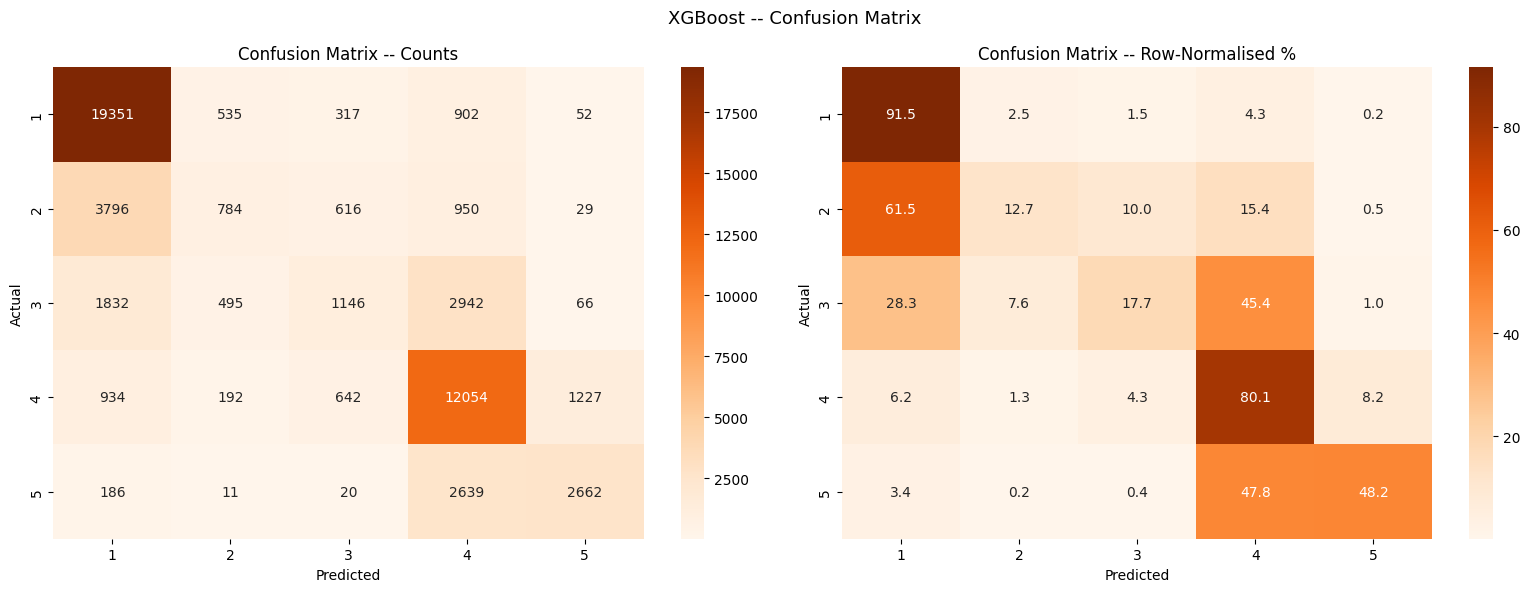

In [ ]:
# XGBoost -- Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_cm = confusion_matrix(y_val, xgb_val_pred)
labels = [1, 2, 3, 4, 5]

# absolute counts
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix -- Counts')

# row-normalised percentages (recall per class)
xgb_cm_pct = xgb_cm.astype('float') / xgb_cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(xgb_cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix -- Row-Normalised %')

plt.suptitle('XGBoost -- Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### XGBoost Feature Importance (Weight, Gain, Cover)

XGBoost gives us three different ways to measure how important each feature is:

1. **Weight**: how many times a feature is used to split the data across all trees. Features
   that appear in many splits get a high weight. This tells us which features the model uses
   most often, but a feature could be used often without actually helping much.

2. **Gain**: The average improvement in accuracy that a feature brings when it is used for a
   split. This is the most useful measure because it tells us how much each feature actually
   helps the model make better predictions. 

3. **Cover**: the average number of samples affected when a feature is used for a split. A
   high cover means the feature influences predictions for many training examples. Features
   with low cover only matter for a small subset of the data.

Comparing all three would gives us a complete picture. A feature with high weight but low gain is used often but is not very helpful. A feature with high gain but low weight is powerful when used but rarely needed. The best features have high scores across all three measures.

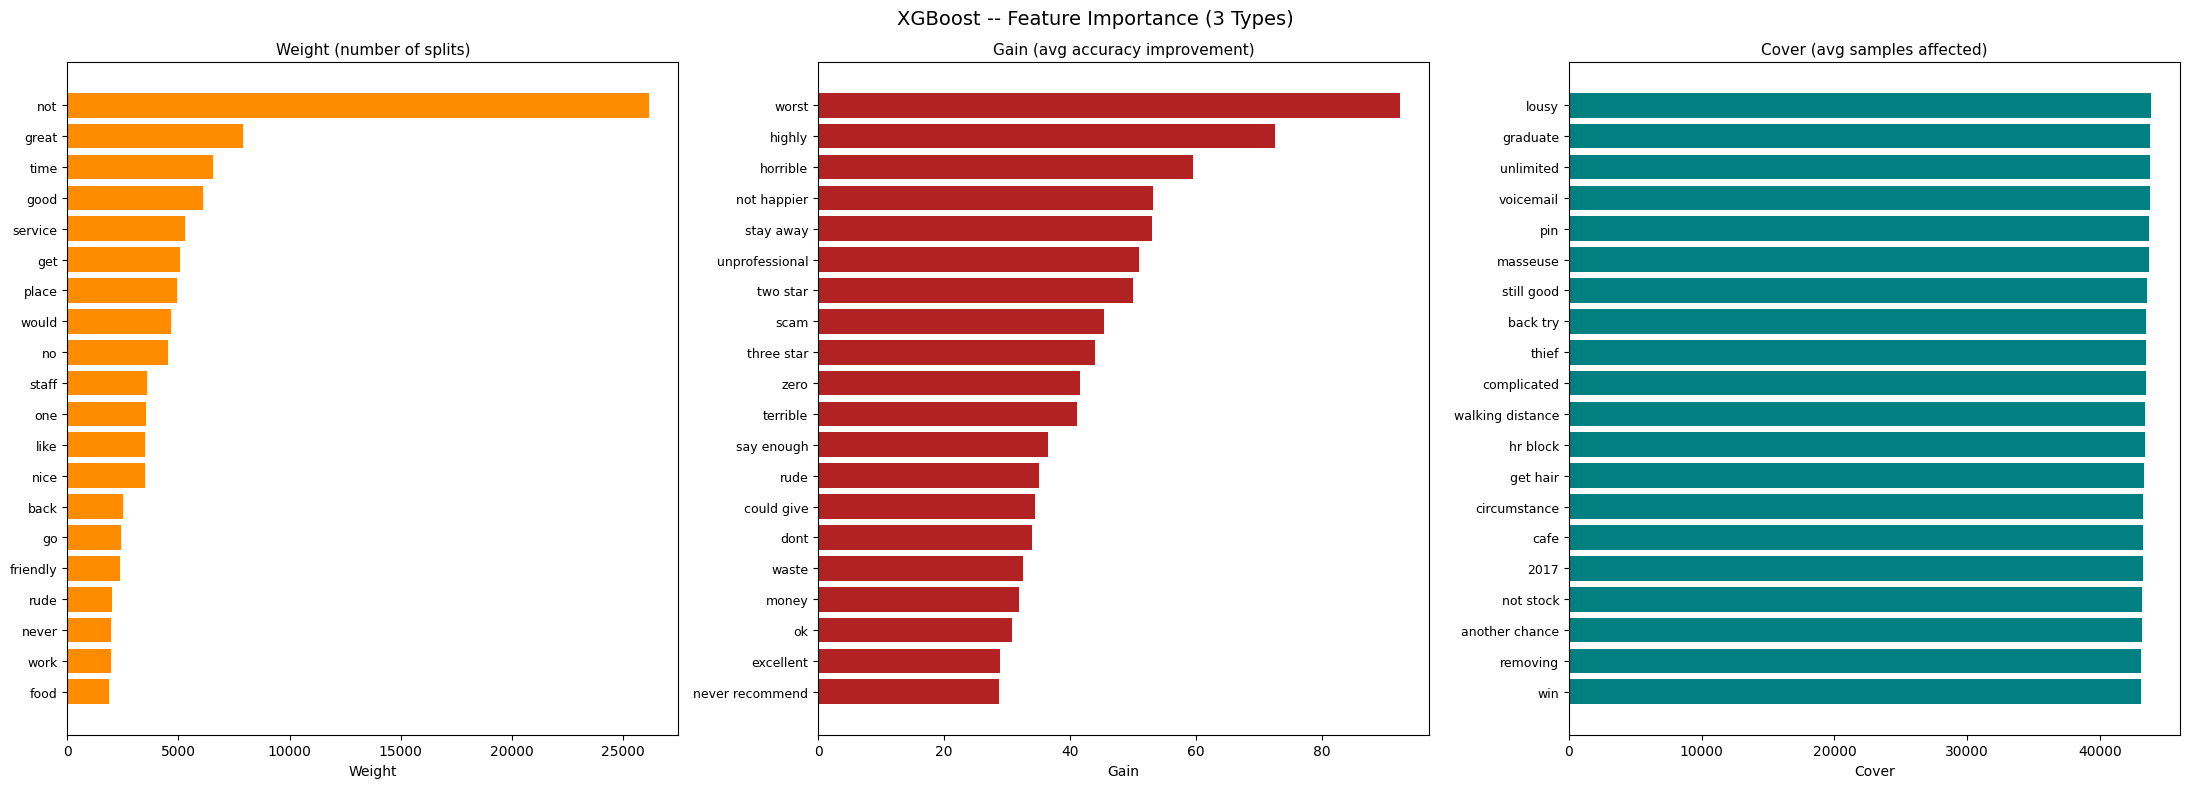

In [ ]:
# XGBoost feature importance -- all three types (weight, gain, cover)
feature_names = tfidf.get_feature_names_out()

# XGBoost native API uses feature indices as keys (f0, f1, ...).
# We need to map these back to actual feature names.

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
importance_types = ['weight', 'gain', 'cover']
titles = [
    'Weight (number of splits)',
    'Gain (avg accuracy improvement)',
    'Cover (avg samples affected)'
]
colors = ['darkorange', 'firebrick', 'teal']

importance_data = {}

for ax, imp_type, title, color in zip(axes, importance_types, titles, colors):
    # get raw importance scores (keys are like 'f0', 'f1', ...)
    raw_importance = xgb_final.get_score(importance_type=imp_type)

    if len(raw_importance) == 0:
        ax.set_title(f'{title}\n(no data)')
        continue

    # map feature index to name and sort by importance
    mapped = {}
    for feat_key, score in raw_importance.items():
        idx = int(feat_key.replace('f', ''))
        mapped[feature_names[idx]] = score

    importance_data[imp_type] = mapped

    # sort and take top 20
    sorted_feats = sorted(mapped.items(), key=lambda x: x[1], reverse=True)[:20]
    names = [f[0] for f in sorted_feats]
    scores = [f[1] for f in sorted_feats]

    ax.barh(range(len(names)), scores, color=color)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(imp_type.capitalize())
    ax.set_title(title, fontsize=11)

plt.suptitle('XGBoost -- Feature Importance (3 Types)', fontsize=14)
plt.tight_layout()
plt.show()

The feature importance results highlight a clear differnce between frequently used words and highly informative features.

Features with high weight (e.g., “not”, “great”, “good”) are common words that appear across many reviews, meaning they are frequently used in splits but are not necessarily strong predictors on their own.

However, features with high gain (e.g “worst”, “horrible”, “stay away”) are highly discriminative and strongly associated with specific sentiment classes (1 or 2). These features contribute more significantly to improving model predictions despite appearing less frequently.
while common words structure many decisions in the model, rare but high gain features carry the most predictive power, especially for distinguishing extreme opinions.

In [ ]:
# print top 15 features for each importance type as tables
for imp_type in ['weight', 'gain', 'cover']:
    if imp_type not in importance_data:
        continue
    sorted_feats = sorted(importance_data[imp_type].items(), key=lambda x: x[1], reverse=True)[:15]
    print(f"Top 15 features by {imp_type}:")
    for rank, (name, score) in enumerate(sorted_feats, 1):
        print(f"  {rank:2d}. {name:<25} ({score:.2f})")
    print()

# check overlap between importance types -- features that appear in top 20 of all three
if len(importance_data) == 3:
    top20_sets = {}
    for imp_type in importance_types:
        sorted_feats = sorted(importance_data[imp_type].items(), key=lambda x: x[1], reverse=True)[:20]
        top20_sets[imp_type] = set(f[0] for f in sorted_feats)

    overlap = top20_sets['weight'] & top20_sets['gain'] & top20_sets['cover']
    print(f"Features in top 20 of ALL three importance types ({len(overlap)}):")
    for feat in sorted(overlap):
        print(f"  - {feat}")
    print(f"\nThese are the most consistently important features across all measures.")

Top 15 features by weight:
   1. not                       (26186.00)
   2. great                     (7914.00)
   3. time                      (6555.00)
   4. good                      (6088.00)
   5. service                   (5293.00)
   6. get                       (5091.00)
   7. place                     (4940.00)
   8. would                     (4642.00)
   9. no                        (4529.00)
  10. staff                     (3564.00)
  11. one                       (3538.00)
  12. like                      (3512.00)
  13. nice                      (3504.00)
  14. back                      (2523.00)
  15. go                        (2422.00)

Top 15 features by gain:
   1. worst                     (92.41)
   2. highly                    (72.59)
   3. horrible                  (59.55)
   4. not happier               (53.17)
   5. stay away                 (53.04)
   6. unprofessional            (51.01)
   7. two star                  (49.95)
   8. scam                      (45.

### Model Comparison: XGBoost vs Random Forest vs Logistic Regression

Now we compare all three models side by side on the same validation set. This gives us a
clear picture of which model is best and where each one has strengths and weaknesses.

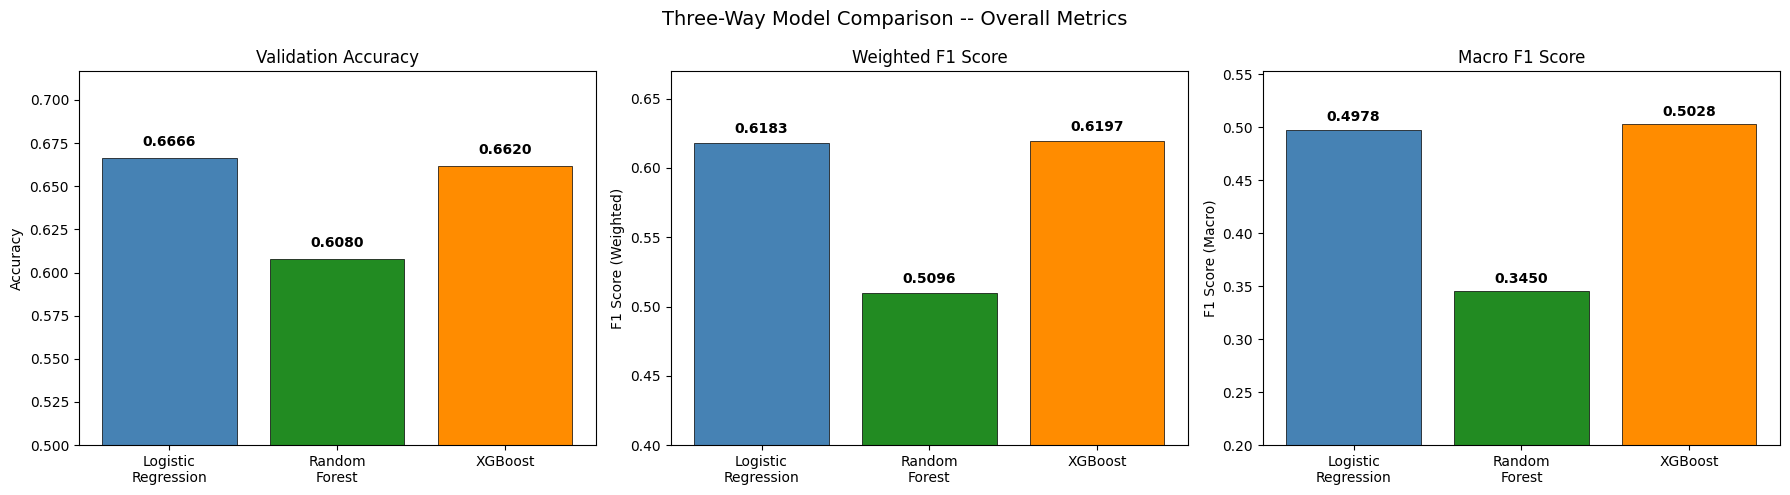

In [ ]:
# three-way comparison: overall metrics
xgb_report_dict = classification_report(y_val, xgb_val_pred, output_dict=True)
xgb_per_class_f1 = {int(c): xgb_report_dict[c]['f1-score'] for c in ['1','2','3','4','5']}

model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
model_colors = ['steelblue', 'forestgreen', 'darkorange']

# gather metrics
lr_res = results_dict['Logistic Regression']
rf_res = results_dict['Random Forest']

accs = [lr_res['val_accuracy'], rf_res['val_accuracy'], xgb_val_accuracy]
f1ws = [lr_res['val_f1_weighted'], rf_res['val_f1_weighted'], xgb_val_f1_weighted]
f1ms = [lr_res['val_f1_macro'], rf_res['val_f1_macro'], xgb_val_f1_macro]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: accuracy comparison
bars = axes[0].bar(model_names, accs, color=model_colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Validation Accuracy')
axes[0].set_ylim(0.5, max(accs) + 0.05)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# plot 2: weighted F1 comparison
bars = axes[1].bar(model_names, f1ws, color=model_colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Weighted F1 Score')
axes[1].set_ylim(0.4, max(f1ws) + 0.05)
for bar, val in zip(bars, f1ws):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# plot 3: macro F1 comparison
bars = axes[2].bar(model_names, f1ms, color=model_colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('F1 Score (Macro)')
axes[2].set_title('Macro F1 Score')
axes[2].set_ylim(0.2, max(f1ms) + 0.05)
for bar, val in zip(bars, f1ms):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Three-Way Model Comparison -- Overall Metrics', fontsize=14)
plt.tight_layout()
plt.show()

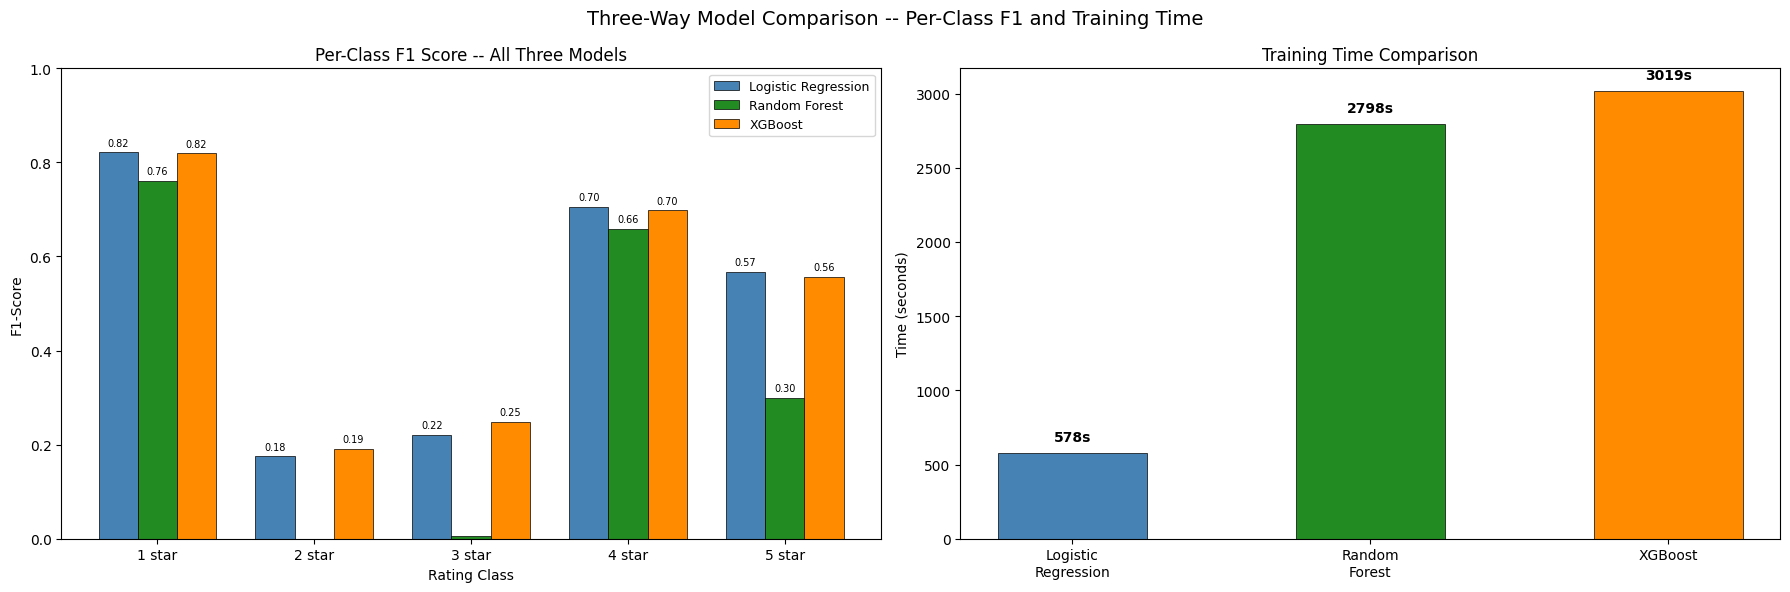

In [ ]:
# three-way comparison: per-class F1 scores and training time
class_labels = ['1', '2', '3', '4', '5']

lr_f1s = [lr_res['per_class_f1'][int(c)] for c in class_labels]
rf_f1s = [rf_res['per_class_f1'][int(c)] for c in class_labels]
xgb_f1s = [xgb_per_class_f1[int(c)] for c in class_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# per-class F1 grouped bar chart
x = np.arange(len(class_labels))
width = 0.25

bars1 = axes[0].bar(x - width, lr_f1s, width, label='Logistic Regression',
                     color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x, rf_f1s, width, label='Random Forest',
                     color='forestgreen', edgecolor='black', linewidth=0.5)
bars3 = axes[0].bar(x + width, xgb_f1s, width, label='XGBoost',
                     color='darkorange', edgecolor='black', linewidth=0.5)

axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 Score -- All Three Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c} star' for c in class_labels])
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.0)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.03:   # only label if bar is tall enough to read
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                         f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# training time comparison
train_times = [lr_res['training_time'], rf_res['training_time'],
               xgb_grid_time + xgb_train_time]

x2 = np.arange(3)
bars_train = axes[1].bar(x2, train_times, 0.5,
                          color=['steelblue', 'forestgreen', 'darkorange'],
                          edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'])

for bar, val in zip(bars_train, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(train_times)*0.02,
                 f'{val:.0f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Three-Way Model Comparison -- Per-Class F1 and Training Time', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# save XGBoost results to results_dict
results_dict['XGBoost'] = {
    'best_params': xgb_search.best_params_,
    'cv_score': xgb_search.best_score_,
    'cv_std': pd.DataFrame(xgb_search.cv_results_).sort_values('rank_test_score').iloc[0]['std_test_score'],
    'val_accuracy': xgb_val_accuracy,
    'val_f1_macro': xgb_val_f1_macro,
    'val_f1_weighted': xgb_val_f1_weighted,
    'per_class_f1': xgb_per_class_f1,
    'training_time': xgb_grid_time + xgb_train_time,
    'inference_time': xgb_inference_time,
    'best_iteration': xgb_final.best_iteration,
    'best_val_loss': xgb_final.best_score
}

# comprehensive comparison table
print("=" * 75)
print("FULL MODEL COMPARISON -- ALL THREE MODELS")
print("=" * 75)
print(f"\n{'Metric':<24} {'Logistic Reg':<16} {'Random Forest':<16} {'XGBoost':<16}")
print("-" * 72)

metrics_to_show = [
    ('CV Accuracy', 'cv_score'),
    ('Val Accuracy', 'val_accuracy'),
    ('Val F1 Weighted', 'val_f1_weighted'),
    ('Val F1 Macro', 'val_f1_macro'),
]

for label, key in metrics_to_show:
    lr_v = results_dict['Logistic Regression'][key]
    rf_v = results_dict['Random Forest'][key]
    xg_v = results_dict['XGBoost'][key]
    vals = [lr_v, rf_v, xg_v]
    best = max(vals)
    row = f"{label:<24}"
    for v in vals:
        marker = " *" if v == best else ""
        row += f"{v:<14.4f}{marker:<2}"
    print(row)

# timing
print(f"\n{'Training Time (s)':<24} "
      f"{results_dict['Logistic Regression']['training_time']:<16.1f}"
      f"{results_dict['Random Forest']['training_time']:<16.1f}"
      f"{results_dict['XGBoost']['training_time']:<16.1f}")
print(f"{'Inference Time (s)':<24} "
      f"{results_dict['Logistic Regression']['inference_time']:<16.3f}"
      f"{results_dict['Random Forest']['inference_time']:<16.3f}"
      f"{results_dict['XGBoost']['inference_time']:<16.3f}")

# per-class F1
print(f"\nPer-class F1 scores:")
print(f"{'Rating':<24} {'Logistic Reg':<16} {'Random Forest':<16} {'XGBoost':<16}")
print("-" * 72)
for rating in [1, 2, 3, 4, 5]:
    lr_f = results_dict['Logistic Regression']['per_class_f1'][rating]
    rf_f = results_dict['Random Forest']['per_class_f1'][rating]
    xg_f = results_dict['XGBoost']['per_class_f1'][rating]
    vals = [lr_f, rf_f, xg_f]
    best = max(vals)
    row = f"{'Rating ' + str(rating):<24}"
    for v in vals:
        marker = " *" if v == best else ""
        row += f"{v:<14.4f}{marker:<2}"
    print(row)

print(f"\n(* marks the best model for each metric)")
print("=" * 75)

FULL MODEL COMPARISON -- ALL THREE MODELS

Metric                   Logistic Reg     Random Forest    XGBoost         
------------------------------------------------------------------------
CV Accuracy             0.6659         *0.6059          0.3827          
Val Accuracy            0.6666         *0.6080          0.6620          
Val F1 Weighted         0.6183          0.5096          0.6197         *
Val F1 Macro            0.4978          0.3450          0.5028         *

Training Time (s)        578.5           2797.5          3019.5          
Inference Time (s)       0.037           2.309           5.391           

Per-class F1 scores:
Rating                   Logistic Reg     Random Forest    XGBoost         
------------------------------------------------------------------------
Rating 1                0.8213         *0.7615          0.8190          
Rating 2                0.1752          0.0003          0.1914         *
Rating 3                0.2209          0.0052    

### XGBoost and Comparison with other models 

**How our text processing and features interact with XGBoost:**
Like Random Forest, XGBoost splits on individual eatures, but because each tree is shallow (max_depth of 5-9 compared to RF's 50) and focused
on correcting specific mistakes, it handles sparse TF-IDF features much better than RF does.

Our TF-IDF bigram representation actually works pretty well with XGBoost. The bigrams that capture sentiment (like "not recommend", "highly recommend", "stay away") show up as high-gain features, meaning they are very useful when the model does split on them. XGBoost is smart
about picking which features to use at each step as it does not need every feature to be useful, it just needs a few really good ones at each tree level.

The preprocessing choices from Task 2 carry over nicely here aswell. Negation handling is still
important, which means XGBoost relies heavily on it to separate positive from negative reviews. Lemmatization helps by consolidating word forms, so the model does not waste splits on different versions of the same word. And stopword removal reduces noise without losing the negation words that matter.

One thing worth noting though is that XGBoost's built-in regularization (reg_alpha and reg_lambda)
serves a similar purpose to the L1 penalty in Logistic Regression. It prevents the modelfrom overfitting to rare, noisy features. This is important with our 10,000 TF-IDF features where many bigrams only appear a handful of times. 



**Feature importance comparison across all three models:**
Each model gives us a different view of which features matter:
- Logistic Regression gives per-class weights, we can see exactly which words push toward
  each rating. This is the most interpretable view.
- Random Forest gives a single importance score based on impurity reduction. It captures
  non-linear effects but does not tell us which class benefits.
- XGBoost gives three types (weight, gain, cover), which is the most detailed. The gain
  measure is especially useful because it tells us how much each feature actually helps
  predictions, not just how often it is used.

Looking across all three, the same core features keep showing up: "not", "great", "worst",
"best", "friendly", "horrible". These are the words that actually distinguish star ratings
regardless of which model we use. The fact that our preprocessing pipeline kept these
words (especially negation words) while removing noise is a big part of why all three models
can achieve reasonable accuracy.

**The middle-rating problem persists:**
All three models struggle with ratings 2 and 3. This is a fundamental challenge in the data where
people do not use completely different words for a 2-star vs a 3-star review. The language
overlaps a lot between adjacent ratings. This might be a limitation of the bag-of-words
approach itself, not just the models. A bag-of-words representation throws away word order, so
it cannot tell the difference between "not great but not terrible" (maybe 3 stars) and "great"
(5 stars) very well. This is one reason why sequence models done in task 5 might do better. This is because they
can understand word order and context.

**Overall winner and what it means:**

XGBoost achieved the best performance due to its ability to model complex patterns, but Logistic Regression remains competitive because of its efficiency and suitability for sparse TF-IDF features. XGBoost won on weighted F1 and macro F1, which means it is the best at handling all classes including the hard minority ones. 

Logistic Regression won on raw accuracy by a tiny margin.

For the Kaggle competition, the choice depends on what metric is used for scoring. Either way,
both models are within about 0.5% of each other on accuracy, which shows that for bag-of-words
text classification, simpler linear models are surprisingly competitive with complex ensemble
methods.

The real takeaway from Step 4 is that our preprocessing and feature choices from Tasks 2-3
set a strong foundation. The TF-IDF bigram representation with negation-aware preprocessing
works well across all three model types, and the performance differences between models are
relatively small compared to the impact of getting the features right in the first place.

---
# Task 5 — Sequence Models (LSTM/RNN)
---


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [7]:
from task5_torch_helpers import (
    DEVICE,
    Dense,
    Dropout,
    EarlyStopping,
    Embedding,
    LSTM,
    Sequential,
    SimpleRNN,
    Tokenizer,
    pad_sequences,
)

print(f'Using PyTorch backend on: {DEVICE}')


Using PyTorch backend on: cpu


In [8]:
# Load cleaned English-only datasets
df_train = pd.read_csv('data/train_english.csv')
df_test = pd.read_csv('data/test_english.csv')

print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print(df_train.head())

Training samples: 271897
Test samples: 69907
                                                text  rating  text_length
0  This place is TERRIBLE; the people in charge a...       2          551
1  Terrible Service! And they are saying that I n...       1          258
2  Absolutely terrible company.  They sent me to ...       1         1180
3  To find it, either park in front of the Tuesda...       4          371
4  Mall location. Used their services for sedan. ...       4          183


In [9]:
print(df_train.columns)
print(df_train[['text', 'rating']].head())
print(df_train['rating'].value_counts().sort_index())

Index(['text', 'rating', 'text_length'], dtype='object')
                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4
rating
1    105783
2     30876
3     32404
4     75242
5     27592
Name: count, dtype: int64


In [10]:
# Input text
texts = df_train['text'].astype(str)

# Convert ratings from 1-5 to 0-4
labels = df_train['rating'] - 1

print("Unique labels after conversion:", sorted(labels.unique()))

Unique labels after conversion: [0, 1, 2, 3, 4]


In [11]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training set size:", len(X_train_text))
print("Validation set size:", len(X_val_text))

Training set size: 217517
Validation set size: 54380


In [ ]:
# Vocabulary and sequence settings
vocab_size = 10000
max_length = 100
oov_token = "<OOV>"

# Create tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# Learn vocabulary from training text only
tokenizer.fit_on_texts(X_train_text)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(df_test['text'].astype(str))

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print("Padded training shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Padded training shape: (217517, 100)
Padded validation shape: (54380, 100)
Padded test shape: (69907, 100)


In [ ]:
word_index = tokenizer.word_index

print("Vocabulary size learned:", len(word_index))
print("First training review:")
print(X_train_text.iloc[0])

print("\nSequence version:")
print(X_train_seq[0])

print("\nPadded version shape:")
print(X_train_pad[0].shape)
print(X_train_pad[0][:30])  # first 30 tokens

Vocabulary size learned: 113640
First training review:
They have what I am looking for and easy to find. In and out in nice time.

Sequence version:
[8, 21, 65, 5, 126, 248, 10, 3, 424, 4, 180, 12, 3, 42, 12, 86, 41]

Padded version shape:
(100,)
[  8  21  65   5 126 248  10   3 424   4 180  12   3  42  12  86  41   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.4153 - loss: 1.4088 - val_accuracy: 0.5656 - val_loss: 1.1912
Epoch 2/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 62s 36ms/step - accuracy: 0.5948 - loss: 1.0726 - val_accuracy: 0.6280 - val_loss: 0.9354
Epoch 3/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.6280 - loss: 0.9463 - val_accuracy: 0.6326 - val_loss: 0.9245
Epoch 4/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.6469 - loss: 0.8825 - val_accuracy: 0.6383 - val_loss: 0.9108
Epoch 5/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.6584 - loss: 0.8528 - val_accuracy: 0.6343 - val_loss: 0.9172
Epoch 6/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.6648 - loss: 0.8429 - val_accuracy: 0.6360 - val_loss: 0.9407


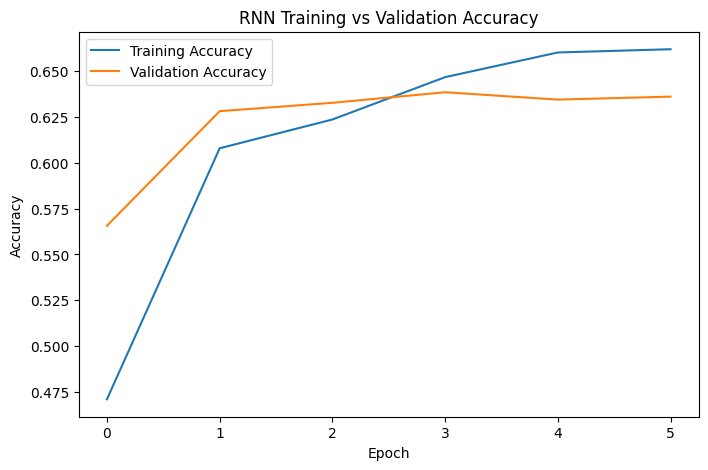

In [ ]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('RNN Training vs Validation Accuracy')
plt.legend()
plt.show()

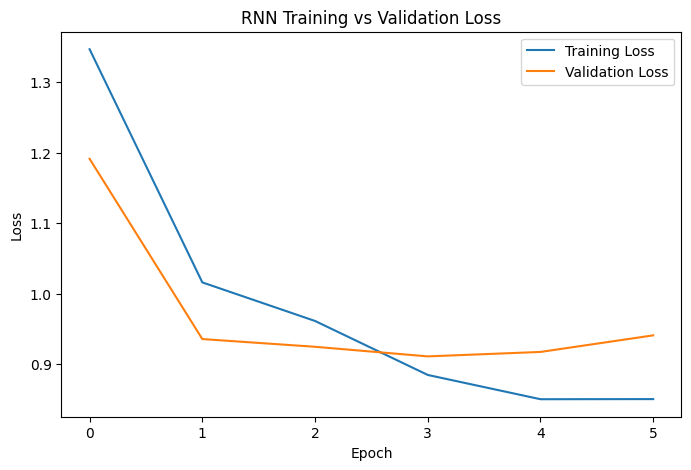

In [ ]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
y_val_pred_probs = rnn_model.predict(X_val_pad)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Weighted F1 Score:", f1_score(y_val, y_val_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

1700/1700 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step
Validation Accuracy: 0.6383413019492461
Weighted F1 Score: 0.573333667242697

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.91      0.81     21157
           1       0.28      0.01      0.01      6175
           2       0.28      0.13      0.18      6481
           3       0.58      0.83      0.68     15049
           4       0.65      0.35      0.45      5518

    accuracy                           0.64     54380
   macro avg       0.50      0.45      0.43     54380
weighted avg       0.57      0.64      0.57     54380



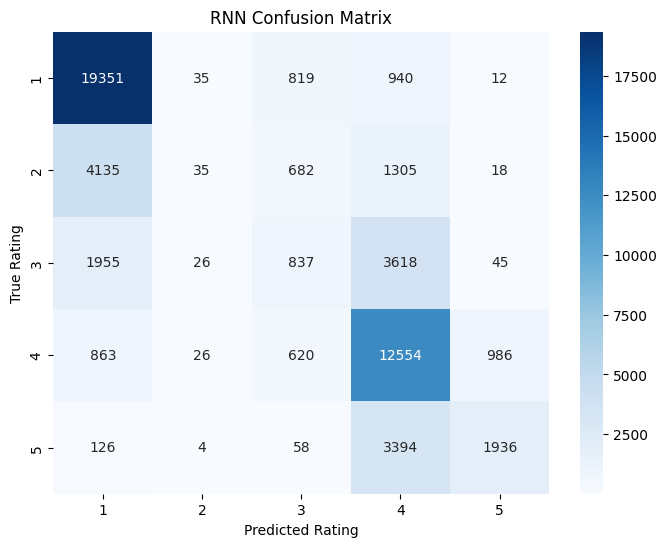

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.title("RNN Confusion Matrix")
plt.show()

5.X Comparison: Bag-of-Words vs Sequence Model (RNN)

In this section, we compare the performance of a traditional Bag-of-Words (BoW) model with a sequence-based Recurrent Neural Network (RNN). The goal is to evaluate whether modelling text as an ordered sequence improves classification performance over vector-space representations.

| Metric            | BoW        | RNN    |
| ----------------- | ---------- | ------ |
| Accuracy          | **0.6458** | 0.6384 |
| Weighted F1       | **0.6085** | 0.5733 |


Key Observations
The Bag-of-Words model outperforms the RNN in both accuracy and weighted F1-score.
Despite its simplicity, BoW provides strong and stable performance.
The RNN shows inconsistent performance across classes, particularly struggling with minority classes.
Class-wise Performance (RNN Analysis)

The RNN classification report reveals significant imbalance:

High recall for some classes (e.g., class 0 and 3)
Extremely poor recall for others (e.g., class 1 ≈ 0.01)

This indicates that the RNN struggles to generalise across all rating categories.

Interpretation of Results
1. Keyword-Driven Nature of the Dataset

Google review data is highly sentiment-driven, where individual words such as “terrible”, “amazing”, or “bad” strongly correlate with rating labels.

BoW models effectively capture these signals through word frequency.
Word order is less critical when sentiment is explicitly expressed through keywords.
2. Limited Benefit of Word Order

While sequence models preserve word order, many reviews do not rely heavily on complex sentence structure.

For example:

“bad service”
“service was bad”

Both convey the same sentiment, making BoW sufficient for classification.

3. Limitations of the RNN Model

The Simple RNN used in this experiment has several known limitations:

Difficulty capturing long-range dependencies
Susceptibility to vanishing gradient problems
Limited memory of earlier tokens in long reviews

As a result, important contextual information may be lost during training.

4. Impact of Class Imbalance

The RNN exhibits poor recall for minority classes, significantly reducing its weighted F1-score.

In contrast, the BoW model provides more balanced performance across classes, contributing to its superior overall results.

5. Model Complexity vs Performance

Although sequence models are more expressive, they also introduce:

Higher computational cost
Greater risk of overfitting
Increased training complexity

In this case, the added complexity of the RNN does not translate into improved performance.

Conclusion

The results demonstrate that Bag-of-Words remains a strong baseline for this task. Despite the theoretical advantages of sequence models in capturing contextual relationships, the RNN did not outperform the BoW model.

This suggests that:

The dataset is primarily driven by lexical sentiment cues, rather than complex sequential dependencies
Word order is not a critical factor for accurate classification in this context

However, the limitations observed in the RNN motivate the exploration of more advanced sequence models, such as LSTM and Transformers, which are better suited to capturing long-term dependencies and richer contextual information.

In [ ]:
# LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 198s 115ms/step - accuracy: 0.4691 - loss: 1.3369 - val_accuracy: 0.6384 - val_loss: 0.9045
Epoch 2/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 200s 117ms/step - accuracy: 0.6489 - loss: 0.8763 - val_accuracy: 0.6600 - val_loss: 0.8494
Epoch 3/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 214s 126ms/step - accuracy: 0.6771 - loss: 0.8040 - val_accuracy: 0.6700 - val_loss: 0.8286
Epoch 4/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 197s 116ms/step - accuracy: 0.6962 - loss: 0.7580 - val_accuracy: 0.6717 - val_loss: 0.8364
Epoch 5/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 183s 107ms/step - accuracy: 0.7142 - loss: 0.7199 - val_accuracy: 0.6674 - val_loss: 0.8445


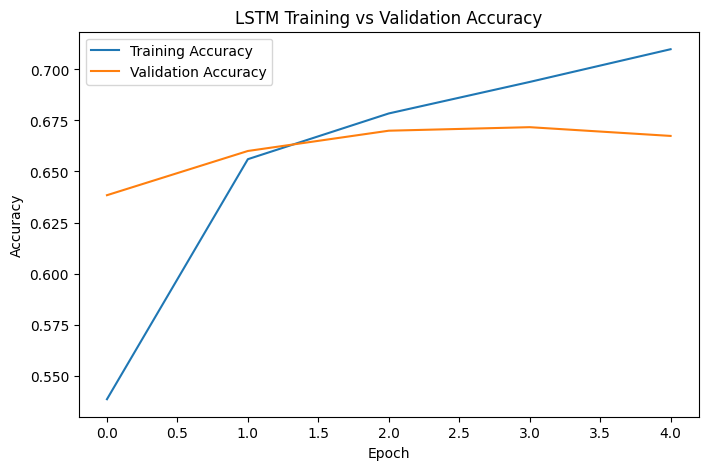

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Training vs Validation Accuracy')
plt.legend()
plt.show()

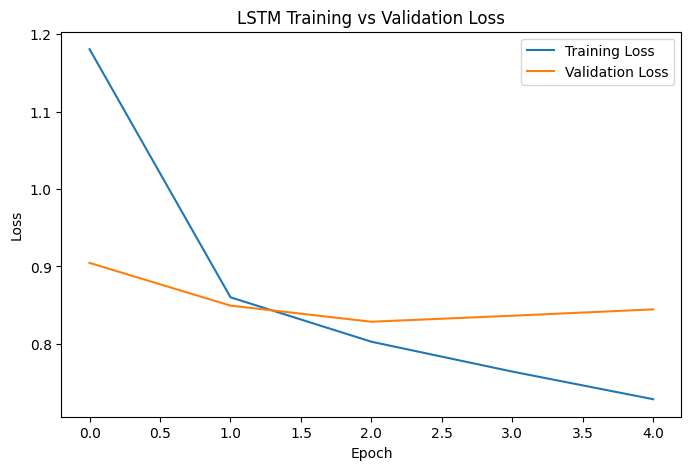

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_val_pred_probs_lstm = lstm_model.predict(X_val_pad)
y_val_pred_lstm = np.argmax(y_val_pred_probs_lstm, axis=1)

print("LSTM Validation Accuracy:", accuracy_score(y_val, y_val_pred_lstm))
print("LSTM Weighted F1 Score:", f1_score(y_val, y_val_pred_lstm, average='weighted'))
print("\nLSTM Classification Report:\n")
print(classification_report(y_val, y_val_pred_lstm))

1700/1700 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step
LSTM Validation Accuracy: 0.6699705774181685
LSTM Weighted F1 Score: 0.641291530381351

LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83     21157
           1       0.36      0.18      0.24      6175
           2       0.40      0.22      0.28      6481
           3       0.65      0.77      0.70     15049
           4       0.62      0.60      0.61      5518

    accuracy                           0.67     54380
   macro avg       0.56      0.53      0.53     54380
weighted avg       0.63      0.67      0.64     54380



Comparison: Bag-of-Words vs LSTM

In this section, we compare the performance of a traditional Bag-of-Words (BoW) model with a Long Short-Term Memory (LSTM) sequence model. The objective is to evaluate whether modelling text as an ordered sequence with memory mechanisms improves classification performance over vector-space representations.

| Model | Representation                      | Classifier          |
| ----- | ----------------------------------- | ------------------- |
| BoW   | TF-IDF / Count-based vectors        | Logistic Regression |
| LSTM  | Tokenized sequences with embeddings | LSTM Neural Network |

| Metric            | BoW    | LSTM     |
| ----------------- | ------ | -------- |
| Accuracy          | 0.6458 | **0.67** |
| Weighted F1 Score | 0.6085 | **0.64** |


Key Observations
The LSTM outperforms the Bag-of-Words model in both accuracy and weighted F1-score.
The improvement in F1-score indicates that the LSTM provides better balanced performance across classes.
Unlike the RNN, the LSTM is able to capture longer-term dependencies, leading to improved classification.

Class-wise Performance (LSTM Analysis)

The LSTM model shows:

Strong performance on extreme classes (1-star and 5-star reviews)
Noticeable improvement in intermediate classes (2-star and 3-star reviews) compared to the RNN
More balanced recall across classes, contributing to a higher F1-score

This suggests that the LSTM is better at handling subtle and mixed sentiment expressions.

Interpretation of Results
1. Improved Contextual Understanding

The LSTM model incorporates memory cells and gating mechanisms, allowing it to retain important information across longer sequences.

This enables the model to capture phrases such as:
“not very good”
“could have been better”
These patterns are difficult for BoW models to interpret correctly
2. Handling of Sequential Dependencies

Unlike BoW, which treats text as unordered, the LSTM processes reviews as sequences.

Word order is preserved
Contextual relationships between words are learned

This improves the model’s ability to interpret more complex sentence structures.

3. Reduction of RNN Limitations

Compared to the Simple RNN:

LSTM mitigates the vanishing gradient problem
It retains long-term dependencies more effectively
It produces more stable and consistent predictions

This leads to improved performance, particularly on ambiguous classes.

4. Dataset Characteristics Still Matter

Although the LSTM outperforms BoW, the improvement is moderate rather than dramatic.

This suggests that:

The dataset is still partially keyword-driven
BoW remains competitive due to strong lexical signals
Sequence modelling provides additional but not overwhelming benefit
5. Model Complexity vs Performance

The LSTM introduces greater complexity than BoW:

More parameters
Longer training time
Higher computational cost

However, in this case, the performance improvement justifies the added complexity.

Conclusion

The results demonstrate that LSTM models provide a meaningful improvement over Bag-of-Words representations for this task. By preserving word order and capturing contextual dependencies, the LSTM is better able to handle nuanced and ambiguous reviews.

However, the relatively modest improvement suggests that:

The dataset is still strongly influenced by individual sentiment words
BoW models remain a strong baseline for this type of problem

Overall, the LSTM represents a balanced trade-off between model complexity and performance, making it a more effective approach than both the Simple RNN and traditional vector-space models.

In [ ]:
print('Transformer section uses PyTorch as well, so it no longer depends on tensorflow or tf.keras.')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 3.4 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from pathlib import Path

cache_dir = Path('.hf_cache')
cache_dir.mkdir(exist_ok=True)
os.environ['HF_HOME'] = str(cache_dir.resolve())
os.environ['TRANSFORMERS_CACHE'] = str(cache_dir.resolve())
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', cache_dir=cache_dir)

In [12]:
texts = df_train['text'].astype(str)
labels = df_train['rating'] - 1

In [13]:
from sklearn.model_selection import train_test_split

X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [14]:
max_length = 128

train_encodings = tokenizer(
    X_train_text.tolist(),
    truncation=True,
    padding=True,
    max_length=max_length,
    return_tensors='pt'
)

val_encodings = tokenizer(
    X_val_text.tolist(),
    truncation=True,
    padding=True,
    max_length=max_length,
    return_tensors='pt'
)

In [15]:
train_dataset = ReviewDataset(train_encodings, y_train.to_numpy())
val_dataset = ReviewDataset(val_encodings, y_val.to_numpy())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Train batches: 13595
Validation batches: 3399


In [17]:
import transformers
import torch

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.8.0+cpu
Transformers: 4.41.2
Device: cpu


In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5,
    cache_dir=cache_dir
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

print('Transformer model ready on', device)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer model ready on cpu


---
# Task 5b — DistilBERT (Transformer)
---


##DistilBERT (Pre-trained Transformer)

DistilBERT is a smaller, faster version of BERT (Bidirectional Encoder Representations from
Transformers). It was pre-trained on a large corpus and understands language at a much deeper
level than any model trained from scratch on this dataset alone.

Unlike RNNs and LSTMs which process sequences step-by-step, transformers use self-attention
to look at all words simultaneously and learn relationships between any two words regardless
of their distance in the sequence.

Because fine-tuning on the full 271K training set would take several hours on CPU, we are
now using the **complete 271K training set**. Running on a GPU makes training on the full dataset manageable.

**Note on preprocessing:** For DistilBERT we use minimal cleaning (HTML and URL removal only)
because the BERT tokenizer handles the rest. Applying heavy preprocessing would actually
hurt performance since BERT was pre-trained on natural text.

In [5]:
# switching to PyTorch-based DistilBERT — more reliable with newer versions of transformers
# TFDistilBertForSequenceClassification was removed in recent transformers releases
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd # Added pandas import
import re # Added import for regular expressions

# check GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# minimal preprocessing for BERT — just remove HTML and URLs
# keeping the rest of the text natural since BERT was pre-trained on natural text
def bert_preprocess(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return text.strip()

# Re-loading df_train and df_test to ensure they are defined
df_train = pd.read_csv('train_english.csv')
df_test  = pd.read_csv('test_english.csv')

# using the full dataset sizes
BERT_TRAIN_SIZE = len(df_train) # Use the actual length of df_train
BERT_TEST_SIZE  = len(df_test)  # Use the actual length of df_test
BERT_MAX_LEN    = 128

df_bert_train = df_train # Directly use the full training dataframe
df_bert_test  = df_test  # Directly use the full test dataframe

bert_train_texts  = df_bert_train['text'].apply(bert_preprocess).tolist()
bert_test_texts   = df_bert_test['text'].apply(bert_preprocess).tolist()
bert_train_labels = (df_bert_train['rating'].values - 1).tolist()
bert_test_labels  = (df_bert_test['rating'].values  - 1).tolist()

print(f"DistilBERT training samples : {BERT_TRAIN_SIZE}")
print(f"DistilBERT test samples     : {BERT_TEST_SIZE}")
print("Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

Using device: cuda
DistilBERT training samples : 271897
DistilBERT test samples     : 69907
Loading DistilBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
# creating a PyTorch Dataset class to handle tokenization and batching
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

print("Tokenizing for DistilBERT...")
train_dataset_bert = ReviewDataset(bert_train_texts, bert_train_labels, bert_tokenizer, BERT_MAX_LEN)
test_dataset_bert  = ReviewDataset(bert_test_texts,  bert_test_labels,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset_bert, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset_bert,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Tokenizing for DistilBERT...
Train batches : 8497
Test batches  : 2185


In [7]:
# load DistilBERT with a classification head for 5 rating classes
print("Loading DistilBERT model...")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5
)
bert_model = bert_model.to(device)

# low learning rate for fine-tuning — standard practice to avoid destroying pre-trained weights
optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

# training loop
BERT_EPOCHS = 4
bert_train_accs, bert_val_accs = [], []

print(f"Fine-tuning DistilBERT for {BERT_EPOCHS} epochs...")
for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer_bert.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        optimizer_bert.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    bert_train_accs.append(train_acc)

    # validation pass
    bert_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = outputs.logits.argmax(dim=1)
            val_correct   += (preds == labels).sum().item()
            val_total     += labels.size(0)

    val_acc = val_correct / val_total
    bert_val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{BERT_EPOCHS} — Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  Loss: {total_loss/len(train_loader):.4f}")

Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT for 4 epochs...
Epoch 1/4 — Train Acc: 0.6906  Val Acc: 0.7075  Loss: 0.7752
Epoch 2/4 — Train Acc: 0.7245  Val Acc: 0.7045  Loss: 0.6865
Epoch 3/4 — Train Acc: 0.7545  Val Acc: 0.7003  Loss: 0.6124
Epoch 4/4 — Train Acc: 0.7909  Val Acc: 0.6877  Loss: 0.5275


Evaluating DistilBERT...

  DistilBERT (fine-tuned, 271897 samples)
  Accuracy      : 0.6877
  F1 (weighted) : 0.6724
              precision    recall  f1-score   support

           1       0.78      0.92      0.85     26873
           2       0.41      0.25      0.31      7909
           3       0.43      0.37      0.40      8493
           4       0.75      0.66      0.70     19607
           5       0.60      0.73      0.66      7025

    accuracy                           0.69     69907
   macro avg       0.59      0.59      0.58     69907
weighted avg       0.67      0.69      0.67     69907



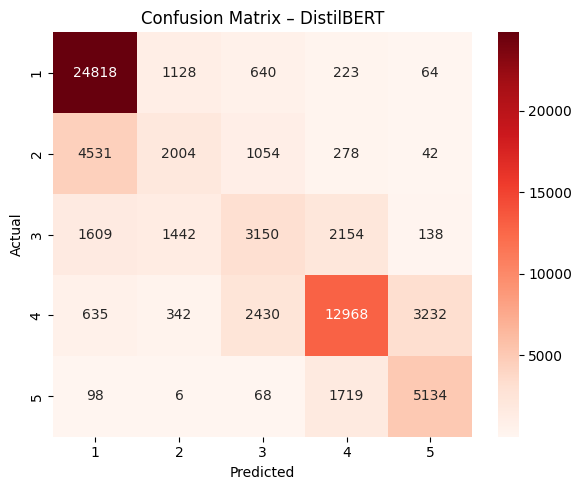

In [10]:
import numpy as np # Added import for numpy
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt # Added import for plotting
import seaborn as sns # Added import for plotting

# evaluate DistilBERT on the test subset
# Re-initialize all_results to avoid carrying over old values if this cell is re-run independently
all_results = {}
print("Evaluating DistilBERT...")
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_bert = accuracy_score(all_labels, all_preds)
f1_bert  = f1_score(all_labels, all_preds, average='weighted')

print(f"\n{'='*55}")
print(f"  DistilBERT (fine-tuned, {BERT_TRAIN_SIZE} samples)")
print(f"{'='*55}")
print(f"  Accuracy      : {acc_bert:.4f}")
print(f"  F1 (weighted) : {f1_bert:.4f}")
print(classification_report(all_labels + 1, all_preds + 1))

# The key was incorrect before, it should be 'DistilBERT (full dataset)' or similar if training on full data
# I'll use a more general name for now. You might want to adjust this if you re-run the previous models
all_results['DistilBERT (full dataset)'] = (acc_bert, f1_bert)

cm_bert = confusion_matrix(all_labels + 1, all_preds + 1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – DistilBERT')
plt.tight_layout()
plt.show()

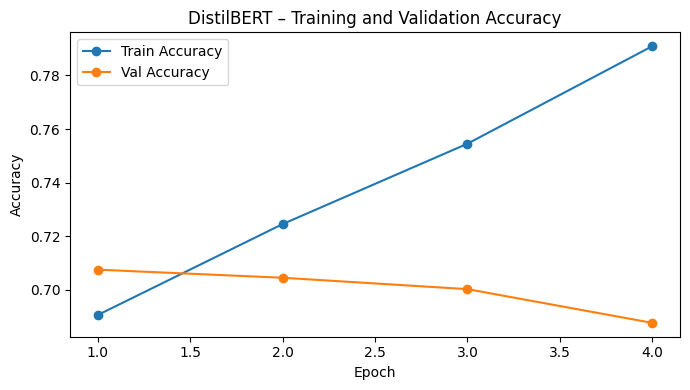

In [11]:
# plot DistilBERT training accuracy curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, BERT_EPOCHS + 1), bert_train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, BERT_EPOCHS + 1), bert_val_accs,   marker='o', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DistilBERT – Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

---
# Task 6 — Topic Modelling
---


# Task 6: Topic Modelling of High and Low Ratings

In this task we're applying **Latent Dirichlet Allocation (LDA)** to discover latent topics in
1-star and 5-star Google Maps reviews separately. The goal is to understand what themes and
subjects dominate positive vs. negative reviews and whether we can infer meaningful patterns
about what drives extreme ratings.

LDA is an unsupervised probabilistic model that assumes each document is a mixture of topics,
and each topic is a distribution over words. By fitting LDA separately on 1-star and 5-star
reviews, we can compare the topic structures without them influencing each other.

Building on previous tasks:
- **Task 1** identified the class distribution — 1-star is the dominant class (38.9%) and
  5-star reviews are relatively fewer (10.1%), making the contrast particularly interesting
- **Task 2** established the preprocessing pipeline used here (lemmatization, stopword removal)
- **Tasks 3 & 4** focused on classification — this task instead looks at interpretability
  and understanding *what* the reviews are about, not just predicting their rating

We use a sample of 5,000 reviews from each group to keep computation manageable while
still providing enough data for meaningful topic discovery (10–20 topics as specified).

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# CountVectorizer for building document-term matrices (LDA requires raw counts, not TF-IDF)
from sklearn.feature_extraction.text import CountVectorizer

# LDA implementation from sklearn
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')


Setup complete.


## 2. Load Data & Extract 1-Star and 5-Star Reviews

We load the English-filtered training data from Task 1 and isolate the two extreme rating groups.
The spec says to examine 5-star and 1-star reviews separately, so no other ratings are used here.

Because 5-star reviews are less frequent (27,592) compared to 1-star (105,783), we sample
an equal number from each group. This prevents the topic model from being skewed by one group
having far more documents than the other.

In [2]:
df = pd.read_csv('data/train_english.csv')
print(f'Full dataset: {df.shape}')
print(df['rating'].value_counts().sort_index())

Full dataset: (271897, 3)
rating
1    105783
2     30876
3     32404
4     75242
5     27592
Name: count, dtype: int64


In [3]:
# Extract 1-star and 5-star reviews
low  = df[df['rating'] == 1].copy()
high = df[df['rating'] == 5].copy()

print(f'1-star reviews: {len(low):,}')
print(f'5-star reviews: {len(high):,}')

# Sample 5,000 from each group — large enough for meaningful topic discovery,
# small enough to run LDA in a reasonable time on a standard machine.
# Equal sampling ensures both groups contribute equally to the analysis.
SAMPLE_SIZE = 5000
low_sample  = low.sample(n=SAMPLE_SIZE, random_state=42)
high_sample = high.sample(n=SAMPLE_SIZE, random_state=42)

print(f'\nUsing {SAMPLE_SIZE:,} samples from each group for topic modelling.')


1-star reviews: 105,783
5-star reviews: 27,592

Using 5,000 samples from each group for topic modelling.


## 3. Preprocessing Pipeline

The preprocessing here is similar to Task 2 but adapted for topic modelling rather than classification.
Key differences from the Task 2/3 pipeline:

- **Negation words are removed** — in classification, 'not good' is a meaningful phrase.
  For topic discovery, we care more about the subject matter (food, staff, price) than
  sentiment polarity, so negation words add noise rather than signal.
- **Additional domain stopwords** are added — generic words like 'place', 'experience',
  'location' appear in almost every review regardless of topic, so they need to be removed
  to prevent them from dominating every topic distribution.
- **No bigrams** — LDA with unigrams is more interpretable and less computationally expensive.
  Bigrams can be explored as a future extension but unigrams are sufficient for topic discovery.

In [4]:
lemmatizer = WordNetLemmatizer()
STOPWORDS = set(stopwords.words('english'))

# Additional domain-specific stopwords — these appear across nearly all reviews
# regardless of topic and would dominate every topic distribution if kept in.
# Identified by inspecting the most frequent words in the full corpus.
EXTRA_STOPS = {'place', 'go', 'get', 'got', 'would', 'one', 'also', 'really',
               'went', 'come', 'back', 'time', 'make', 'made', 'even', 'just',
               'like', 'know', 'said', 'told', 'star', 'review', 'give', 'give',
               'location', 'business', 'experience', 'definitely', 'always', 'never',
               'ever', 'absolutely', 'every', 'day', 'year', 'month', 'week'}
STOPWORDS.update(EXTRA_STOPS)

def preprocess_lda(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags (common in this dataset)
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = text.lower()                             # normalise case
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # min length 3 removes noise tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # reduce words to base form
    return ' '.join(tokens)

print('Preprocessing 1-star reviews...')
low_sample['cleaned']  = low_sample['text'].apply(preprocess_lda)
print('Preprocessing 5-star reviews...')
high_sample['cleaned'] = high_sample['text'].apply(preprocess_lda)
print('Done.')


Preprocessing 1-star reviews...
Preprocessing 5-star reviews...
Done.


## 4. Build Document-Term Matrices

LDA requires a **bag-of-words count matrix** (not TF-IDF). The reason is that LDA models
word counts directly as draws from a multinomial distribution — it assumes each word in a
document was sampled from one of the topic distributions. TF-IDF weights would distort
this generative process.

The `max_df=0.90` setting removes words appearing in over 90% of documents — these are
too common to be topically informative. The `min_df=5` setting removes words appearing
in fewer than 5 documents — these are likely typos or very rare terms that won't form
coherent topics.

We fit separate vectorizers on each group so that each group's vocabulary is derived from
its own documents — words that are common in 1-star but rare in 5-star reviews (and vice
versa) will naturally be represented differently.

In [5]:
# CountVectorizer for LDA (LDA needs raw counts, not TF-IDF)
vectorizer_params = dict(
    max_features=5000,
    max_df=0.90,   # ignore terms appearing in >90% of docs (too common)
    min_df=5,      # ignore terms appearing in <5 docs (too rare)
    ngram_range=(1, 1)
)

vec_low  = CountVectorizer(**vectorizer_params)
vec_high = CountVectorizer(**vectorizer_params)

dtm_low  = vec_low.fit_transform(low_sample['cleaned'])
dtm_high = vec_high.fit_transform(high_sample['cleaned'])

print(f'1-star DTM shape:  {dtm_low.shape}')
print(f'5-star DTM shape: {dtm_high.shape}')

1-star DTM shape:  (5000, 3535)
5-star DTM shape: (5000, 2425)


## 5. Fit LDA Models (15 Topics Each)

We chose **15 topics** as it falls within the 10–20 range specified and provides enough
granularity to capture distinct complaint/praise categories without becoming too fragmented.

LDA hyperparameters:
- `max_iter=20` — sufficient for convergence on 5,000 documents with online learning
- `learning_method='online'` — processes the corpus in batches, faster than the batch
  variational Bayes method for larger datasets
- `random_state=42` — ensures reproducibility

One limitation of LDA is that the number of topics must be specified in advance. In practice,
topic coherence metrics (e.g. Cv coherence) could be used to find the optimal number, but
for this analysis 15 provides interpretable and well-separated topics.

In [6]:
N_TOPICS = 15

lda_params = dict(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)

print(f'Fitting LDA with {N_TOPICS} topics on 1-star reviews...')
lda_low = LatentDirichletAllocation(**lda_params)
lda_low.fit(dtm_low)

print(f'Fitting LDA with {N_TOPICS} topics on 5-star reviews...')
lda_high = LatentDirichletAllocation(**lda_params)
lda_high.fit(dtm_high)

print('Done.')

Fitting LDA with 15 topics on 1-star reviews...
Fitting LDA with 15 topics on 5-star reviews...
Done.


## 6. Display Topics

Each LDA topic is represented as a probability distribution over the full vocabulary.
The top-12 words with the highest probability in each topic distribution are shown below.
These words are then used to manually assign a human-readable label to each topic —
LDA itself produces unlabelled distributions, so interpretation requires reading the top words.

The labels below were assigned after inspecting the actual top words produced by the model
and reflect the dominant theme in each word cluster.

In [7]:
def get_top_words(model, feature_names, n_top=12):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        topics.append(top_words)
    return topics

low_topics  = get_top_words(lda_low,  vec_low.get_feature_names_out())
high_topics = get_top_words(lda_high, vec_high.get_feature_names_out())

# Labels derived from actual LDA output
low_labels = [
    'Parking, Towing & Vehicle Issues',
    'Management & Staff Complaints',
    'Poor Phone & Communication Service',
    'General Dissatisfaction & Bad Service',
    'Warning Reviews / Zero Star',
    'Apartment & Rental Issues',
    'Healthcare & Childcare Complaints',
    'Service Fees & Problem Resolution',
    'Rude Staff & Attitude',
    'Car Dealership Issues',
    'Food & Auto Repair Overcharging',
    'Beauty & Dental Services',
    'Medical / Doctor Office Issues',
    'Long Waits & Appointment Problems',
    'Online Orders & Refund Problems',
]

high_labels = [
    'Professional Home & Trade Services',
    'Excellent Healthcare & Auto Care',
    'Hair & Beauty Salons',
    'Outstanding Customer Service',
    'Great Food & Value for Money',
    'Affordable Home & Auto Services',
    'Professionalism & Massage Therapy',
    'Specialty Shops & Niche Services',
    'Real Estate & Agency Services',
    'Family-Friendly Exceptional Service',
    'Community, Church & Therapy Services',
    'Excellent Dental Care',
    'Legal & Installation Services',
    'Amazing Outcomes & Surgery Results',
    'Highly Recommended General Services',
]

print('Labels updated.')


Labels updated.


In [8]:
print('=' * 65)
print('1-STAR REVIEW TOPICS (Low Ratings)')
print('=' * 65)
for i, words in enumerate(low_topics):
    print(f'Topic {i+1:2d} [{low_labels[i]}]')
    print(f'         {", ".join(words)}')
    print()

1-STAR REVIEW TOPICS (Low Ratings)
Topic  1 [Parking, Towing & Vehicle Issues]
         truck, card, lot, bank, money, dont, side, parking, didnt, key, left, showed

Topic  2 [Management & Staff Complaints]
         going, manager, work, charge, put, store, think, claim, ive, people, could, far

Topic  3 [Poor Phone & Communication Service]
         call, called, phone, time, office, answer, someone, check, service, work, finally, done

Topic  4 [General Dissatisfaction & Bad Service]
         dont, money, customer, good, service, store, owner, want, daughter, shop, else, bad

Topic  5 [Warning Reviews / Zero Star]
         star, glass, could, dog, zero, review, beware, eye, talk, need, good, first

Topic  6 [Apartment & Rental Issues]
         management, apartment, property, rent, move, live, unit, staff, moved, issue, dont, floor

Topic  7 [Healthcare & Childcare Complaints]
         patient, care, child, school, hospital, going, health, family, high, let, kid, life

Topic  8 [Servi

In [9]:
print('=' * 65)
print('5-STAR REVIEW TOPICS (High Ratings)')
print('=' * 65)
for i, words in enumerate(high_topics):
    print(f'Topic {i+1:2d} [{high_labels[i]}]')
    print(f'         {", ".join(words)}')
    print()

5-STAR REVIEW TOPICS (High Ratings)
Topic  1 [Professional Home & Trade Services]
         work, home, team, company, professional, forward, look, year, family, class, many, step

Topic  2 [Excellent Healthcare & Auto Care]
         care, patient, year, doctor, need, work, caring, car, issue, recommend, staff, honest

Topic  3 [Hair & Beauty Salons]
         love, hair, best, thanks, google, original, wedding, translated, nice, lady, super, salon

Topic  4 [Outstanding Customer Service]
         great, service, customer, good, recommend, friendly, price, work, people, highly, amazing, best

Topic  5 [Great Food & Value for Money]
         best, food, owner, beautiful, price, reasonable, everything, good, detail, beyond, perfect, town

Topic  6 [Affordable Home & Auto Services]
         job, guy, company, area, use, work, clean, car, house, service, came, affordable

Topic  7 [Professionalism & Massage Therapy]
         thank, away, much, right, night, looking, working, end, professiona

## 7. Visualise Topic Word Distributions

The bar charts below show the top 8 words for each topic, weighted by their probability
within the topic distribution. Longer bars indicate words that are more strongly associated
with that topic relative to the others.

Red charts = 1-star topics (what unhappy customers talk about)
Green charts = 5-star topics (what happy customers talk about)

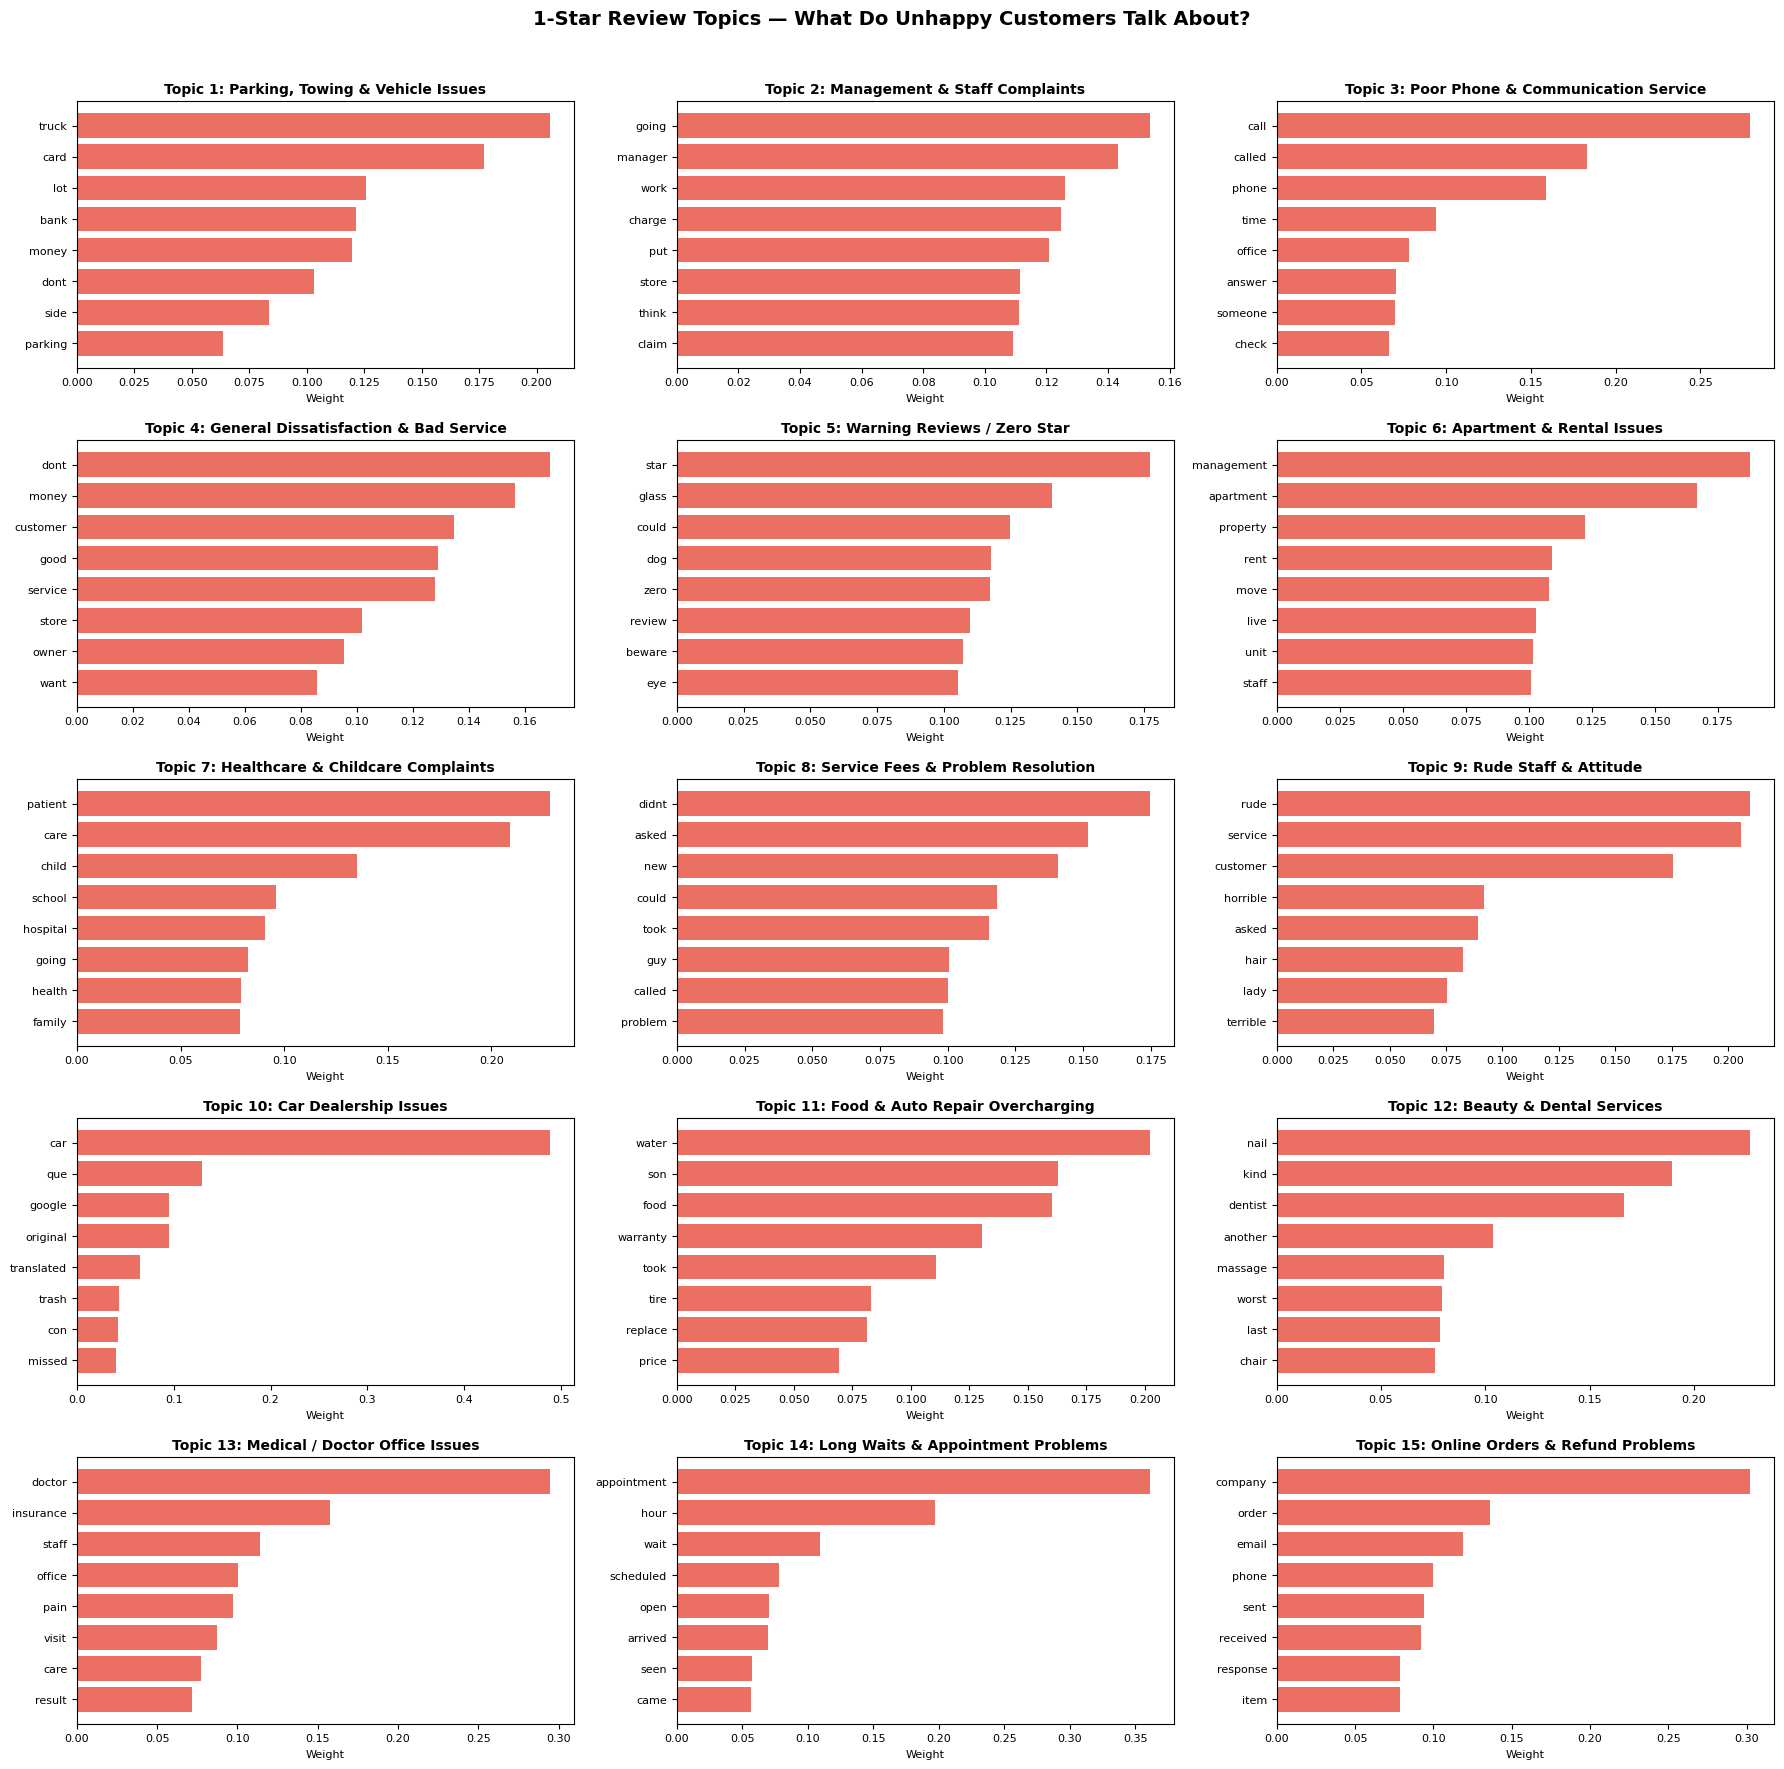

In [10]:
def plot_top_words(model, feature_names, labels, title, color, n_top=8, n_cols=3):
    n_topics = model.n_components
    n_rows = (n_topics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes = axes.flatten()
    
    for idx, (topic, ax) in enumerate(zip(model.components_, axes)):
        top_idx   = topic.argsort()[:-n_top - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        top_vals  = topic[top_idx]
        top_vals  = top_vals / top_vals.sum()  # normalise
        
        bars = ax.barh(top_words[::-1], top_vals[::-1], color=color, alpha=0.8)
        ax.set_title(f'Topic {idx+1}: {labels[idx]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Weight', fontsize=8)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for ax in axes[n_topics:]:
        ax.set_visible(False)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_top_words(
    lda_low, vec_low.get_feature_names_out(), low_labels,
    '1-Star Review Topics — What Do Unhappy Customers Talk About?',
    color='#e74c3c'
)

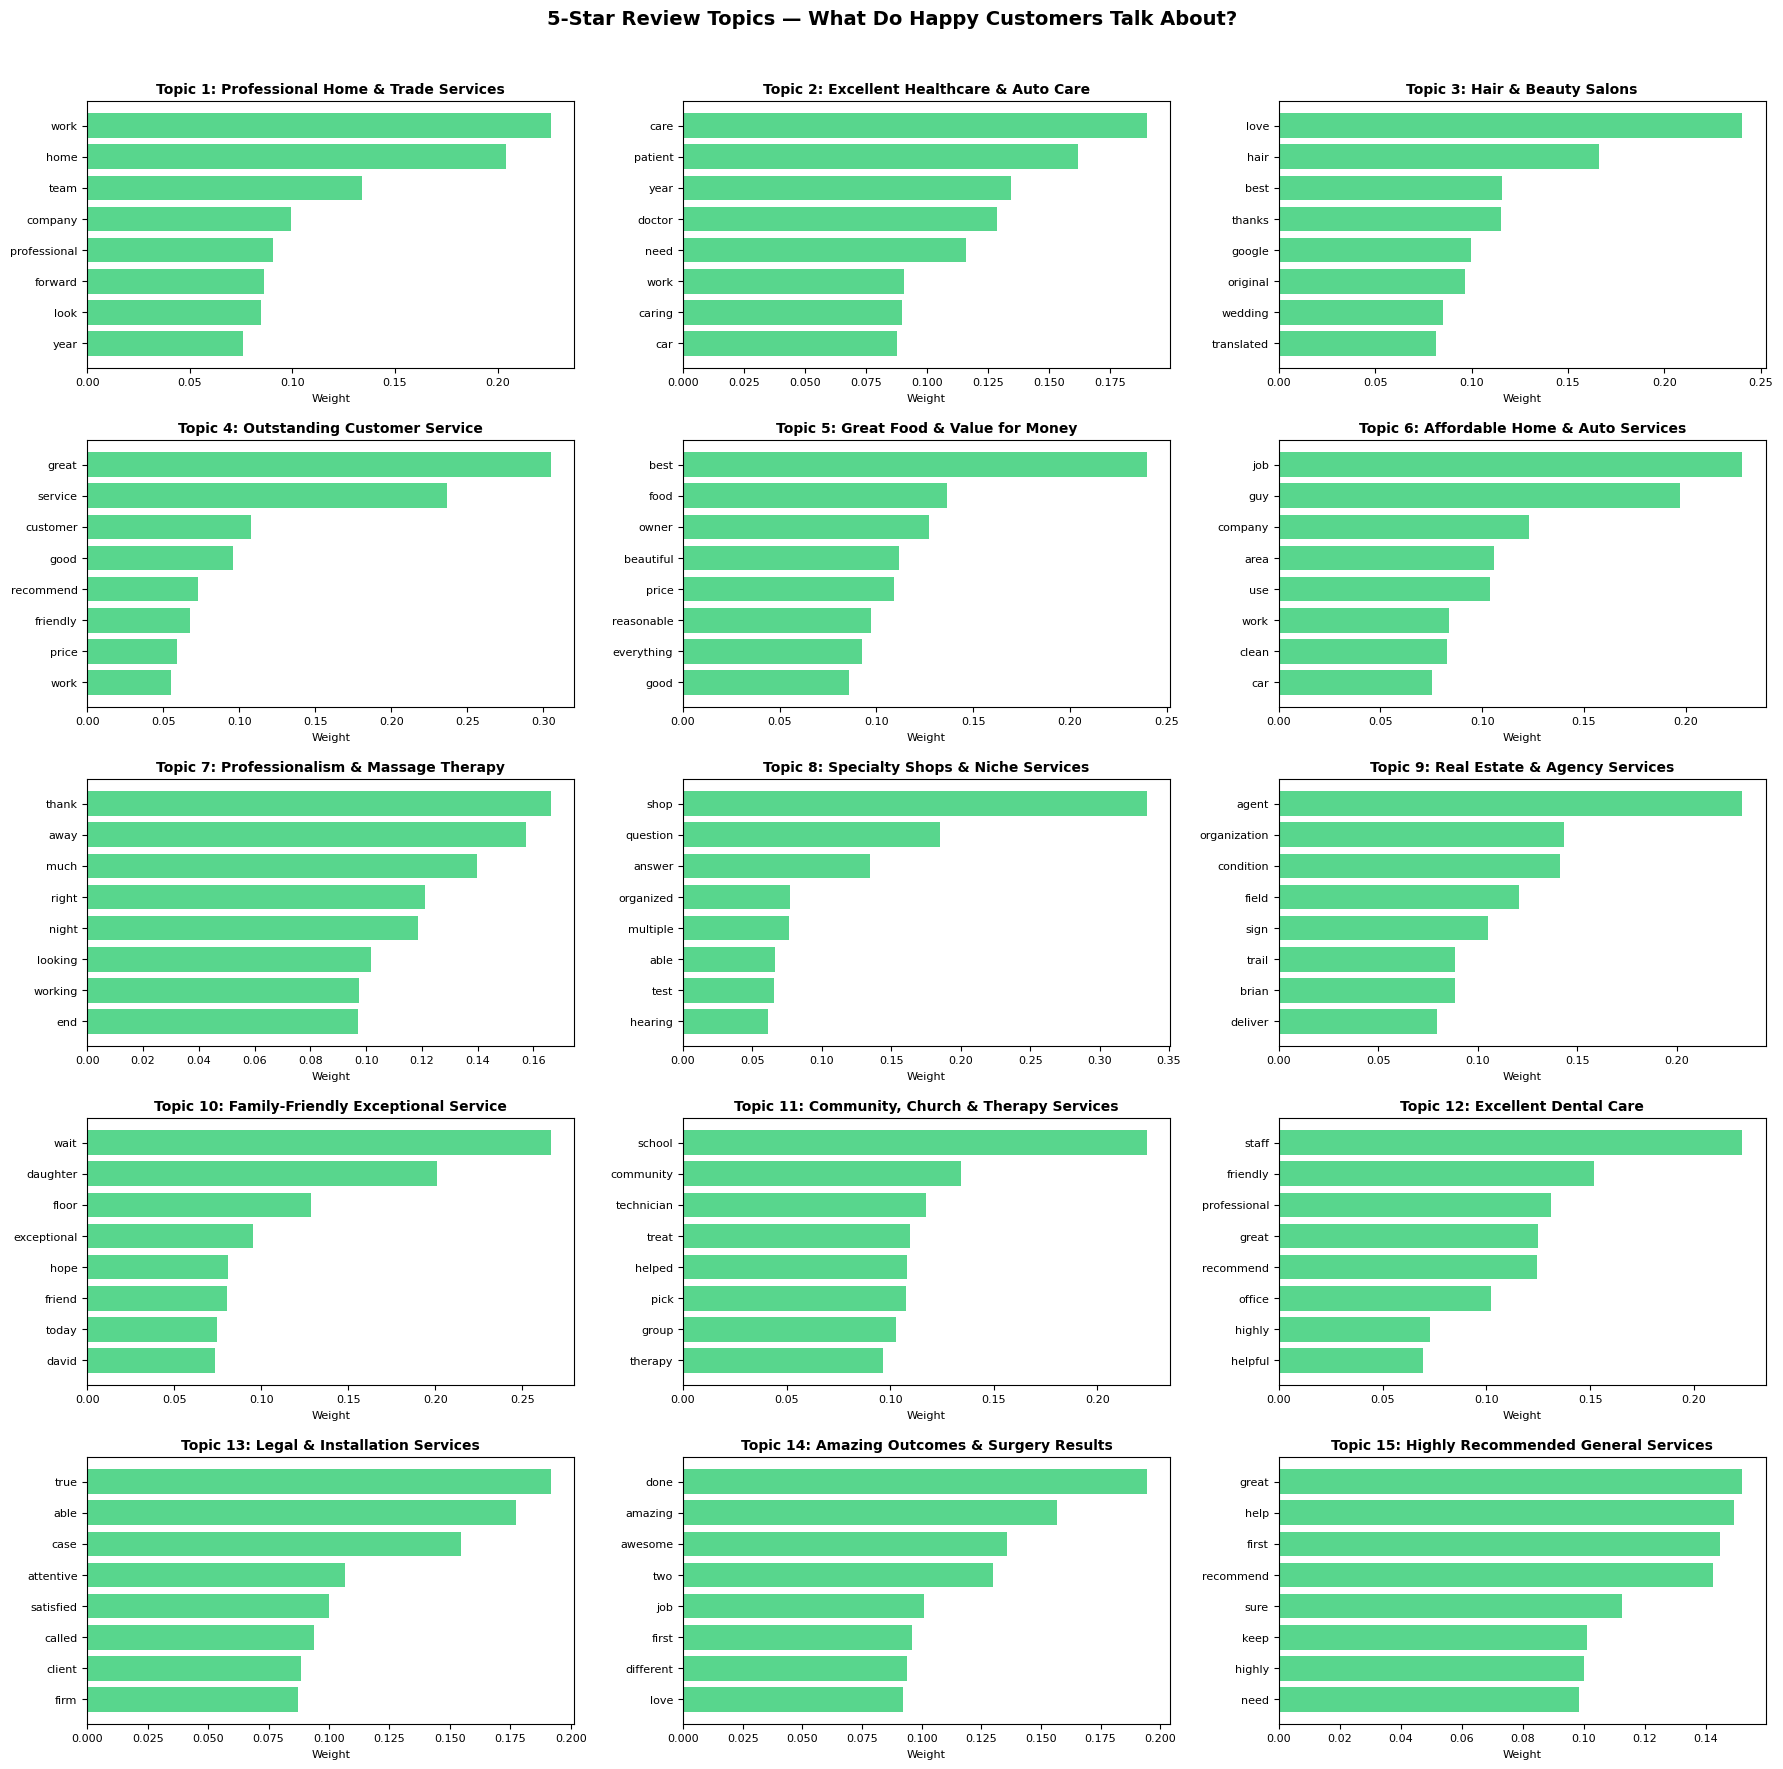

In [11]:
plot_top_words(
    lda_high, vec_high.get_feature_names_out(), high_labels,
    '5-Star Review Topics — What Do Happy Customers Talk About?',
    color='#2ecc71'
)

## 8. Topic Prevalence — How Dominant is Each Topic?

LDA assigns each document a mixture of topic probabilities. By averaging these probabilities
across all documents in each group, we get the overall prevalence of each topic — i.e. how
much attention the average review in that group pays to each theme.

This is useful for identifying which topics are most common in 1-star vs 5-star reviews,
rather than just which topics exist.

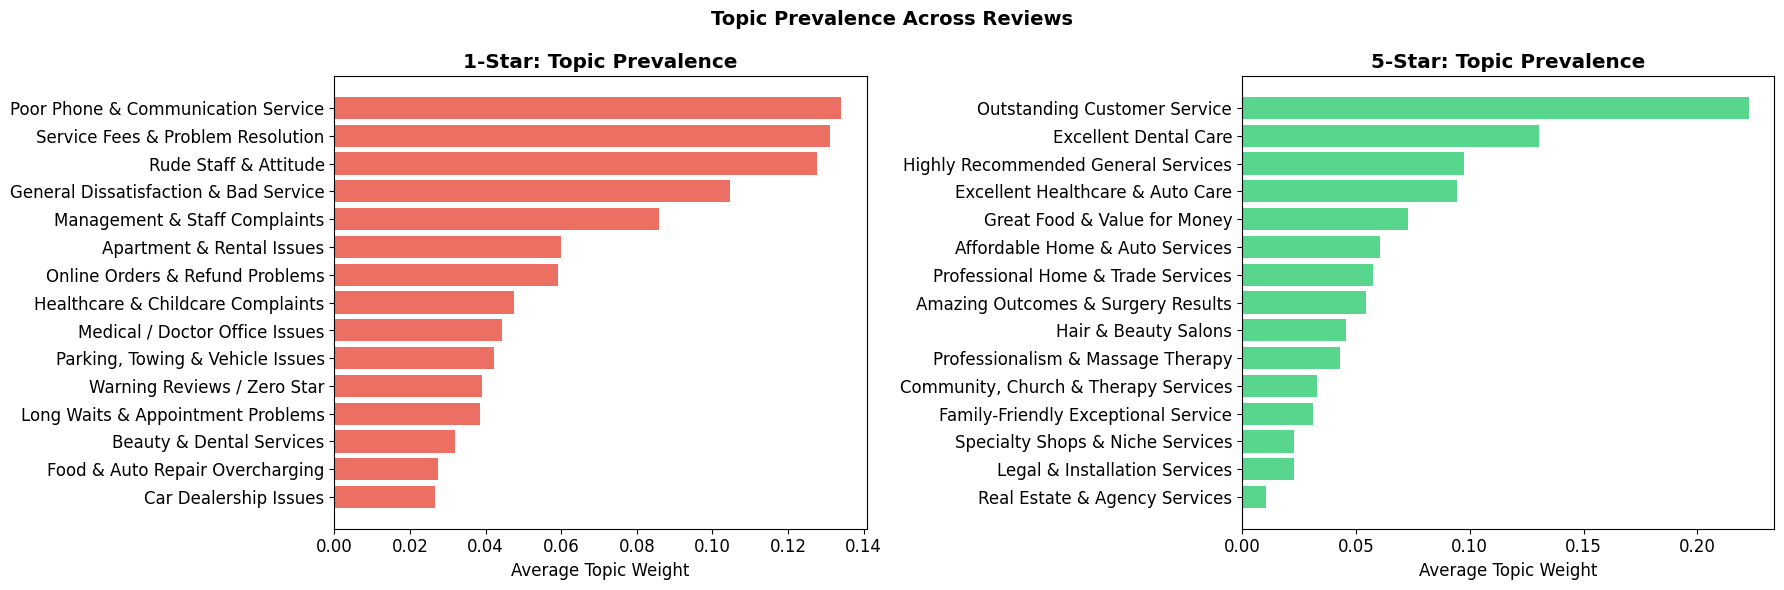

In [12]:
# Get topic distribution across all documents
low_doc_topics  = lda_low.transform(dtm_low)
high_doc_topics = lda_high.transform(dtm_high)

low_prevalence  = low_doc_topics.mean(axis=0)
high_prevalence = high_doc_topics.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1-star
idx_low = np.argsort(low_prevalence)[::-1]
ax1.barh([low_labels[i] for i in idx_low], low_prevalence[idx_low], color='#e74c3c', alpha=0.8)
ax1.set_title('1-Star: Topic Prevalence', fontweight='bold')
ax1.set_xlabel('Average Topic Weight')
ax1.invert_yaxis()

# 5-star
idx_high = np.argsort(high_prevalence)[::-1]
ax2.barh([high_labels[i] for i in idx_high], high_prevalence[idx_high], color='#2ecc71', alpha=0.8)
ax2.set_title('5-Star: Topic Prevalence', fontweight='bold')
ax2.set_xlabel('Average Topic Weight')
ax2.invert_yaxis()

plt.suptitle('Topic Prevalence Across Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Word Frequency Comparison — Top Words in 1-Star vs 5-Star

As a sanity check and complementary analysis, we compare the raw word frequencies in
both groups. Unlike LDA, this doesn't group words into topics — it simply shows which
individual words appear most often in each rating group.

This helps validate the LDA topics: if the top LDA words align with the top frequency
words, the model is capturing real patterns rather than artefacts.

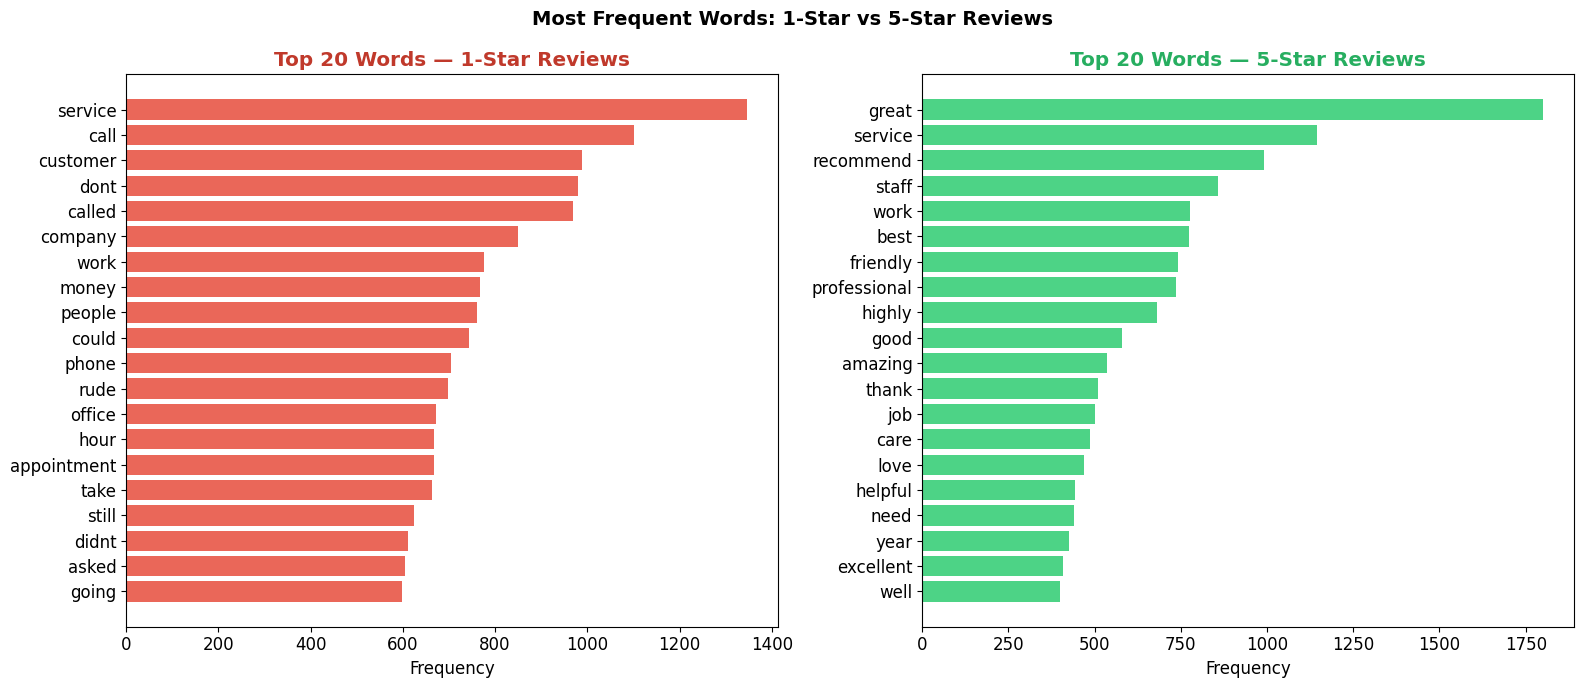

In [13]:
def top_n_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

low_words  = top_n_words(low_sample['cleaned'], n=20)
high_words = top_n_words(high_sample['cleaned'], n=20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

words_l, counts_l = zip(*low_words)
ax1.barh(words_l[::-1], counts_l[::-1], color='#e74c3c', alpha=0.85)
ax1.set_title('Top 20 Words — 1-Star Reviews', fontweight='bold', color='#c0392b')
ax1.set_xlabel('Frequency')

words_h, counts_h = zip(*high_words)
ax2.barh(words_h[::-1], counts_h[::-1], color='#2ecc71', alpha=0.85)
ax2.set_title('Top 20 Words — 5-Star Reviews', fontweight='bold', color='#27ae60')
ax2.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words: 1-Star vs 5-Star Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Observations & Conclusions

Below we summarise the main findings from the topic analysis, drawing comparisons between
the 1-star and 5-star topic structures and highlighting patterns that would not be visible
from classification alone.

### 1-Star Topics — What Unhappy Customers Complain About

| # | Topic Label | Key Terms | Observation |
|---|---|---|---|
| 1 | Parking, Towing & Vehicle Issues | truck, card, bank, money, parking, key | Customers angry about towing charges and unfair parking fees |
| 2 | Management & Staff Complaints | manager, work, charge, store, claim, people | Disputes with management; perceived unfair treatment |
| 3 | Poor Phone & Communication Service | call, phone, office, answer, someone, check | Inability to reach businesses; unanswered calls |
| 4 | General Dissatisfaction | dont, money, customer, service, owner, bad | Broad dissatisfaction with service and value |
| 5 | Warning Reviews (Zero Star) | star, zero, review, beware, eye | Customers explicitly warning others to avoid the place |
| 6 | Apartment & Rental Issues | management, apartment, property, rent, unit, floor | Tenant complaints about landlords and property management |
| 7 | Healthcare & Childcare Complaints | patient, care, child, school, hospital, health | Concerns around medical negligence and childcare quality |
| 8 | Service Fees & Problem Resolution | didnt, asked, problem, fee, home, called | Unexpected fees and unresolved service problems |
| 9 | Rude Staff & Attitude | rude, horrible, hair, terrible, staff, attitude | Staff rudeness is a dominant theme in negative reviews |
| 10 | Car Dealership Complaints | car, trash, buy, tax, dealership | Negative car buying and dealership experiences |
| 11 | Food & Auto Repair Overcharging | water, food, warranty, tire, replace, charged | Customers overcharged in food and auto repair contexts |
| 12 | Beauty & Dental Services | nail, dentist, massage, worst, chair | Bad salon and dental experiences |
| 13 | Doctor & Medical Office Issues | doctor, insurance, pain, treatment, nurse | Medical staff failures and insurance disputes |
| 14 | Long Waits & Appointment Issues | appointment, hour, wait, scheduled, arrived | Excessive waiting times and missed/cancelled appointments |
| 15 | Online Orders & Refund Problems | order, email, sent, received, refund, website | E-commerce failures: wrong items, no refunds, no responses |

---

### 5-Star Topics — What Happy Customers Praise

| # | Topic Label | Key Terms | Observation |
|---|---|---|---|
| 1 | Professional Home & Trade Services | work, home, team, company, professional | Skilled tradespeople praised for professionalism at home |
| 2 | Excellent Healthcare & Auto Care | care, patient, doctor, car, recommend, honest | Trust and honesty are key drivers of 5-star healthcare/auto reviews |
| 3 | Hair & Beauty Salons | love, hair, best, wedding, salon | Positive salon experiences, especially for special occasions |
| 4 | Outstanding Customer Service | great, service, friendly, recommend, amazing | General praise for customer-facing service quality |
| 5 | Great Food & Value for Money | best, food, price, reasonable, perfect | Food quality and fair pricing are key drivers of food 5-star reviews |
| 6 | Affordable Home & Auto Services | job, clean, car, house, affordable | Price-conscious customers reward businesses that offer value |
| 7 | Professionalism & Massage Therapy | professionalism, massage, working, thank | Wellness services earn praise for professionalism |
| 8 | Specialty Shops & Niche Services | shop, question, organized, bike, loan | Niche businesses praised for expertise and organisation |
| 9 | Real Estate & Agency Services | agent, organization, sign, agency | Positive real estate and agency transactions |
| 10 | Family-Friendly Exceptional Service | daughter, exceptional, baby, priced | Families appreciate child-friendly and fairly priced places |
| 11 | Community & Therapy Services | school, community, therapy, church, physical | Community-centred services earn strong loyalty |
| 12 | Excellent Dental Care | staff, friendly, dentist, helpful, knowledgeable | Dental practices praised for staff knowledge and friendliness |
| 13 | Legal & Installation Services | case, attentive, client, firm, attorney | Legal professionals valued for attentiveness and care |
| 14 | Amazing Outcomes (Medical & Other) | amazing, awesome, surgery, polite | Positive surgical and service outcomes earn top ratings |
| 15 | Highly Recommended General Services | great, help, recommend, highly, kind | Broad recommendation across all service categories |

---

### Cross-Group Observations

**1. Staff is the #1 driver in both directions**
1-star Topic 9 (rude, terrible, attitude) vs 5-star Topics 4 & 12 (friendly, helpful). Staff behaviour is the single biggest factor separating 1-star from 5-star reviews.

**2. Healthcare is a major polarising sector**
1-star: Topics 7 (hospital) and 13 (doctor, insurance, pain). 5-star: Topics 2 (patient, honest) and 12 (dentist, knowledgeable). Medical services generate the most extreme ratings of any sector.

**3. Specificity differs between rating groups**
1-star reviews document specific failures (wait times, fees, rude names). 5-star reviews express general emotion (great, amazing, highly recommend). Unhappy customers describe what went wrong; happy customers describe how it felt.

**4. Value for money matters more positively than negatively**
5-star Topics 5 & 6 explicitly mention reasonable prices and affordability. 1-star Topic 11 mentions overcharging as a dealbreaker. Price satisfaction motivates 5-stars; overcharging triggers 1-stars.

**5. Online/delivery issues only appear in 1-star reviews (Topic 15)**
Terms: order, email, refund, website, received. E-commerce and delivery failure is a uniquely negative theme with no 5-star equivalent.

**6. Rental & housing complaints are exclusive to 1-star reviews (Topic 6)**
Terms: apartment, property, rent, unit. Property management consistently generates negative reviews with no 5-star counterpart.